In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
#Health Insurance Dataset
df = pd.read_csv(r"C:\Users\Given\Downloads\Health Insurance Cleaned.csv", sep=";")

# Exploritory Data Analysis

In [3]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 82 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Personal_Code                                   16000 non-null  float64
 1   Days_Visited_Two_Hospitals                      16000 non-null  int64  
 2   Months_Visited                                  16000 non-null  int64  
 3   Max_Monthly_Visit_Days                          16000 non-null  int64  
 4   Avg_Monthly_Visit_Days                          16000 non-null  float64
 5   Max_Monthly_Hospitals_Visited                   16000 non-null  int64  
 6   Avg_Monthly_Hospitals_Visited                   16000 non-null  float64
 7   Total_Visits                                    16000 non-null  int64  
 8   Max_Monthly_Visits                              16000 non-null  int64  
 9   Avg_Monthly_Visits      

<span style="font-size:22px;">The Dataset has 82 variables, of which 81 are the predictors with n = 16 000</span>

In [4]:
display(df.head())

,Personal_Code,Days_Visited_Two_Hospitals,Months_Visited,Max_Monthly_Visit_Days,Avg_Monthly_Visit_Days,Max_Monthly_Hospitals_Visited,Avg_Monthly_Hospitals_Visited,Total_Visits,Max_Monthly_Visits,Avg_Monthly_Visits,...,Drug_Cost_Percentage,Personal_Payment_Drug_Percentage,Examination_Cost_Percentage,Personal_Payment_Examination_Percentage,Treatment_Cost_Percentage,Personal_Payment_Treatment_Percentage,Civil_Affairs_Assistance,Urban_Rural_Preferential_Support,Registered,Result
0,352120000000000.00,0,6,7,5.67,3,2.17,34,7,5.67,...,0.94,0.00,0.05,0.00,0.01,0.00,0,0,1,0
1,352120000000000.00,0,6,4,2.50,2,1.33,15,4,2.50,...,0.96,0.00,0.03,0.00,0.01,0.00,0,0,1,0
2,352120000000000.00,8,6,8,6.17,3,2.17,45,9,7.50,...,0.78,0.00,0.00,0.00,0.20,0.00,0,0,0,0
3,352120000000000.00,0,6,6,3.67,2,1.83,23,6,3.83,...,0.46,0.00,0.00,0.00,0.54,0.00,0,0,0,0
4,352120000000000.00,0,6,5,4.33,1,1.00,26,5,4.33,...,0.98,0.00,0.00,0.00,0.02,0.00,0,0,0,0


## 1. Checking for Multicolinearinty

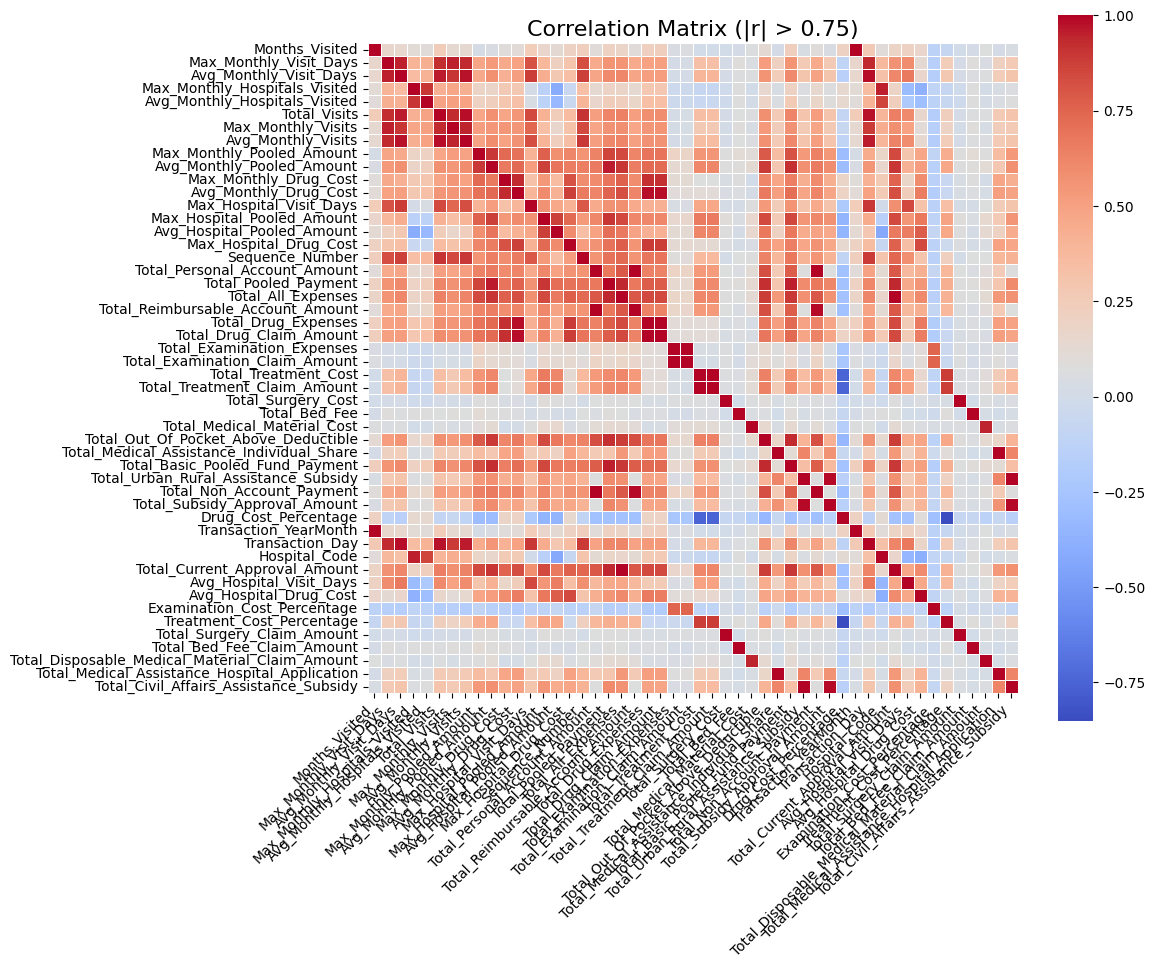

In [5]:
correlation_matrix = df.corr()
threshold = 0.75

upper_tri = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={0: "Correlation", "level_0": "Feature1", "level_1": "Feature2"})
)

high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"].abs() > threshold]
high_corr_vars = pd.unique(high_corr_pairs[["Feature1", "Feature2"]].values.ravel("K"))
subset_corr_matrix = correlation_matrix.loc[high_corr_vars, high_corr_vars]

plt.figure(figsize=(12, 10))
sns.heatmap(
    subset_corr_matrix,
    annot=False,
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True,
    square=True
)
plt.title("Correlation Matrix (|r| > 0.75)", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("correlation_matrix_focused_blocks.png", dpi=150)

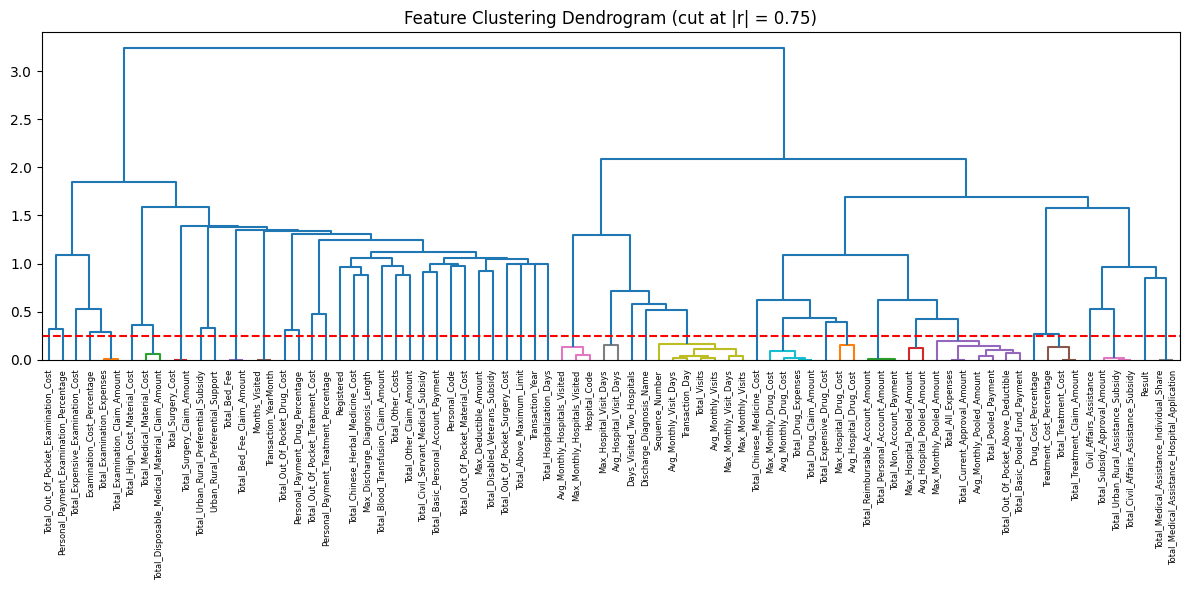

In [6]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

corr = df.corr().fillna(0)
distance_matrix = 1 - abs(corr)
condensed_dist = squareform(distance_matrix, checks=False)

plt.figure(figsize=(12, 6))
dend = sch.linkage(condensed_dist, method='ward')
sch.dendrogram(
    dend,
    labels=corr.columns,
    leaf_rotation=90,
    color_threshold=0.25   # corresponds to |r| = 0.75
)
plt.axhline(y=0.25, color='red', linestyle='--')  # cut line
plt.title("Feature Clustering Dendrogram (cut at |r| = 0.75)")
plt.tight_layout()
plt.show()

### 1.1. Checking for correlation with a threshold of |r|>0.75

In [7]:
corr_matrix = df.corr().abs()
high_corr_vars = [(i, j, corr_matrix.loc[i, j]) 
                  for i in corr_matrix.columns 
                  for j in corr_matrix.columns 
                  if i != j and corr_matrix.loc[i, j] > 0.75]

print("\nHighly Correlated Variables (Threshold > 0.75):")
for var1, var2, corr in sorted(high_corr_vars, key=lambda x: -x[2]):
    print(f"{var1} - {var2}: {corr:.2f}")


Highly Correlated Variables (Threshold > 0.75):
Months_Visited - Transaction_YearMonth: 1.00
Transaction_YearMonth - Months_Visited: 1.00
Total_Medical_Assistance_Individual_Share - Total_Medical_Assistance_Hospital_Application: 1.00
Total_Medical_Assistance_Hospital_Application - Total_Medical_Assistance_Individual_Share: 1.00
Total_Treatment_Cost - Total_Treatment_Claim_Amount: 1.00
Total_Treatment_Claim_Amount - Total_Treatment_Cost: 1.00
Total_Drug_Expenses - Total_Drug_Claim_Amount: 1.00
Total_Drug_Claim_Amount - Total_Drug_Expenses: 1.00
Total_Bed_Fee - Total_Bed_Fee_Claim_Amount: 1.00
Total_Bed_Fee_Claim_Amount - Total_Bed_Fee: 1.00
Total_Surgery_Cost - Total_Surgery_Claim_Amount: 1.00
Total_Surgery_Claim_Amount - Total_Surgery_Cost: 1.00
Total_Urban_Rural_Assistance_Subsidy - Total_Civil_Affairs_Assistance_Subsidy: 1.00
Total_Civil_Affairs_Assistance_Subsidy - Total_Urban_Rural_Assistance_Subsidy: 1.00
Total_All_Expenses - Total_Current_Approval_Amount: 1.00
Total_Current_Appr

## 2. Removing one variable from each highly correlated pair

In [8]:
removed_features = set()
for var1, var2, corr in sorted(high_corr_vars, key=lambda x: -x[2]):
    if var1 not in removed_features and var2 not in removed_features:
        print(f"{var1} - {var2}: {corr:.2f} (Removing {var2})")
        removed_features.add(var2)
df.drop(columns=removed_features, inplace=True)

Months_Visited - Transaction_YearMonth: 1.00 (Removing Transaction_YearMonth)
Total_Medical_Assistance_Individual_Share - Total_Medical_Assistance_Hospital_Application: 1.00 (Removing Total_Medical_Assistance_Hospital_Application)
Total_Treatment_Cost - Total_Treatment_Claim_Amount: 1.00 (Removing Total_Treatment_Claim_Amount)
Total_Drug_Expenses - Total_Drug_Claim_Amount: 1.00 (Removing Total_Drug_Claim_Amount)
Total_Bed_Fee - Total_Bed_Fee_Claim_Amount: 1.00 (Removing Total_Bed_Fee_Claim_Amount)
Total_Surgery_Cost - Total_Surgery_Claim_Amount: 1.00 (Removing Total_Surgery_Claim_Amount)
Total_Urban_Rural_Assistance_Subsidy - Total_Civil_Affairs_Assistance_Subsidy: 1.00 (Removing Total_Civil_Affairs_Assistance_Subsidy)
Total_All_Expenses - Total_Current_Approval_Amount: 1.00 (Removing Total_Current_Approval_Amount)
Total_Personal_Account_Amount - Total_Non_Account_Payment: 1.00 (Removing Total_Non_Account_Payment)
Total_Examination_Expenses - Total_Examination_Claim_Amount: 0.99 (Remov

In [9]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 46 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Personal_Code                              16000 non-null  float64
 1   Days_Visited_Two_Hospitals                 16000 non-null  int64  
 2   Months_Visited                             16000 non-null  int64  
 3   Max_Monthly_Visit_Days                     16000 non-null  int64  
 4   Max_Monthly_Hospitals_Visited              16000 non-null  int64  
 5   Max_Monthly_Pooled_Amount                  16000 non-null  float64
 6   Max_Monthly_Drug_Cost                      16000 non-null  float64
 7   Transaction_Year                           16000 non-null  int64  
 8   Total_Hospitalization_Days                 16000 non-null  int64  
 9   Total_Personal_Account_Amount              16000 non-null  float64
 10  Total_O

<span style="font-size:18px;">After removing variables with high multicolinearity, we now have 46 variables, of which 45 are the predictors</span>

## 3. Checking the Dataset for missing values

In [10]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Personal_Code                                 0
Days_Visited_Two_Hospitals                    0
Months_Visited                                0
Max_Monthly_Visit_Days                        0
Max_Monthly_Hospitals_Visited                 0
Max_Monthly_Pooled_Amount                     0
Max_Monthly_Drug_Cost                         0
Transaction_Year                              0
Total_Hospitalization_Days                    0
Total_Personal_Account_Amount                 0
Total_Out_Of_Pocket_Drug_Cost                 0
Total_Expensive_Drug_Cost                     0
Total_Chinese_Medicine_Cost                   0
Total_Chinese_Herbal_Medicine_Cost            0
Total_Examination_Expenses                    0
Total_Out_Of_Pocket_Examination_Cost          0
Total_Expensive_Examination_Cost              0
Total_Treatment_Cost                          0
Total_Out_Of_Pocket_Treatment_Cost            0
Total_Surgery_Cost                            0
Total_Out_Of_Pocket_Sur

<span style="font-size:20px;">The variable Personal_Payment_Drug_Percentage has 24 missing values</span>

## 4. Dealing with missing Values

In [11]:
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

print("\nMissing Values After Handling:")
print(df.isnull().sum())


Missing Values After Handling:
Personal_Code                                0
Days_Visited_Two_Hospitals                   0
Months_Visited                               0
Max_Monthly_Visit_Days                       0
Max_Monthly_Hospitals_Visited                0
Max_Monthly_Pooled_Amount                    0
Max_Monthly_Drug_Cost                        0
Transaction_Year                             0
Total_Hospitalization_Days                   0
Total_Personal_Account_Amount                0
Total_Out_Of_Pocket_Drug_Cost                0
Total_Expensive_Drug_Cost                    0
Total_Chinese_Medicine_Cost                  0
Total_Chinese_Herbal_Medicine_Cost           0
Total_Examination_Expenses                   0
Total_Out_Of_Pocket_Examination_Cost         0
Total_Expensive_Examination_Cost             0
Total_Treatment_Cost                         0
Total_Out_Of_Pocket_Treatment_Cost           0
Total_Surgery_Cost                           0
Total_Out_Of_Pocket_Surgery_

<span style="font-size:20px;">The variable Personal_Payment_Drug_Percentage now has 0 missing values</span>

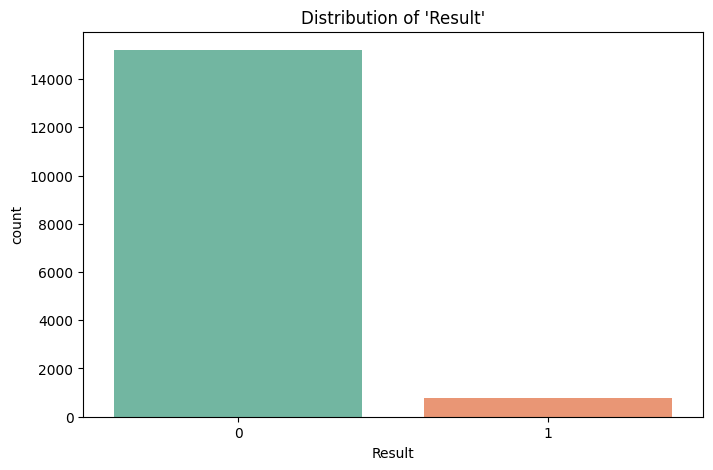

In [12]:
## 5. Cheking the imbalance of the response variable 'Result'

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Result', hue='Result', palette='Set2', legend=False)

plt.title("Distribution of 'Result'")
plt.show()

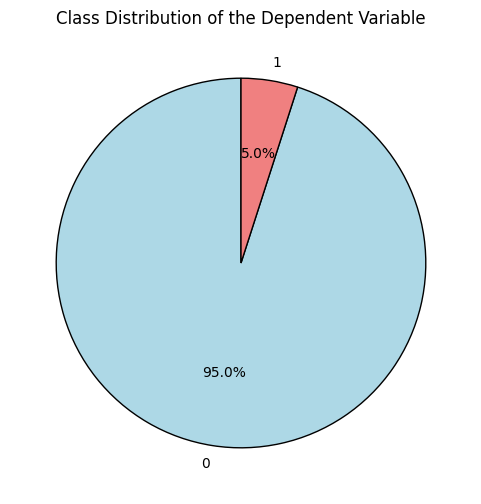


Class Counts:
Result
0    15207
1      793
Name: count, dtype: int64


In [13]:
plt.figure(figsize=(6, 6))
df['Result'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightblue', 'lightcoral'], startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title("Class Distribution of the Dependent Variable")
plt.ylabel("")
plt.show()

print("\nClass Counts:")
print(df['Result'].value_counts())

<span style="font-size:20px;">The target variable 'Result' is highly imbalanced</span>

## 6. Checking for outliers using Boxplots

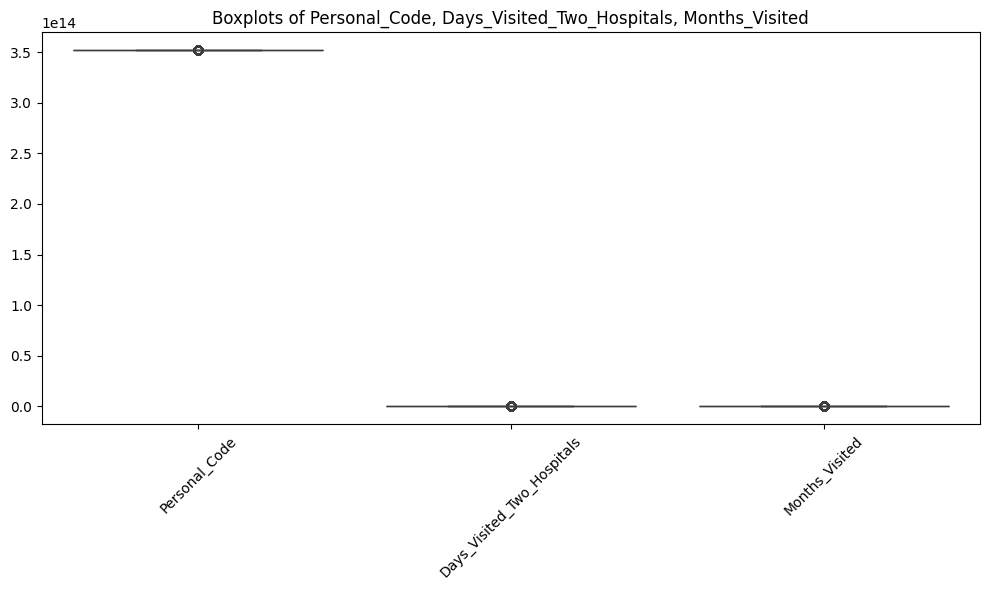

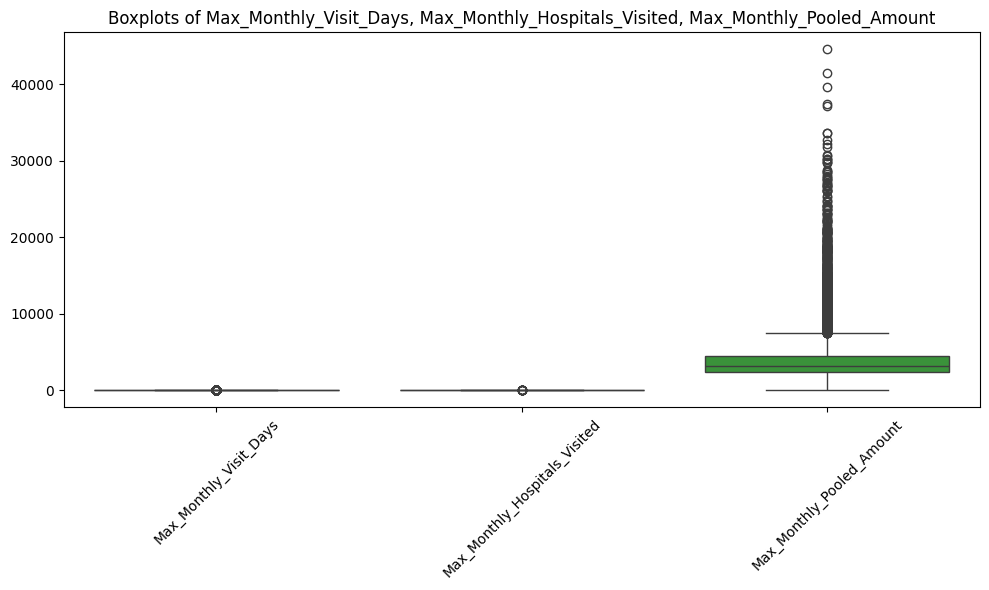

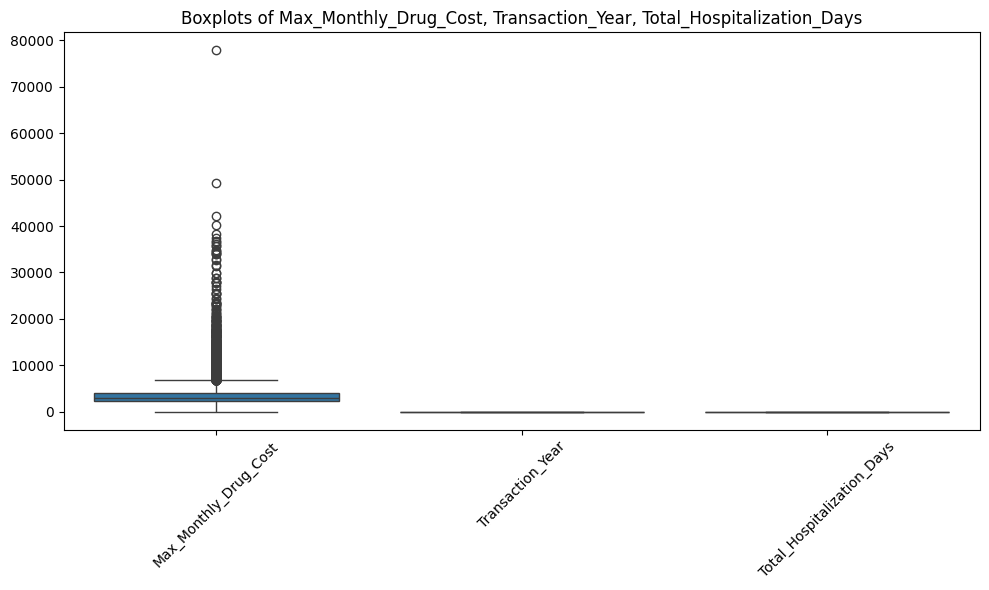

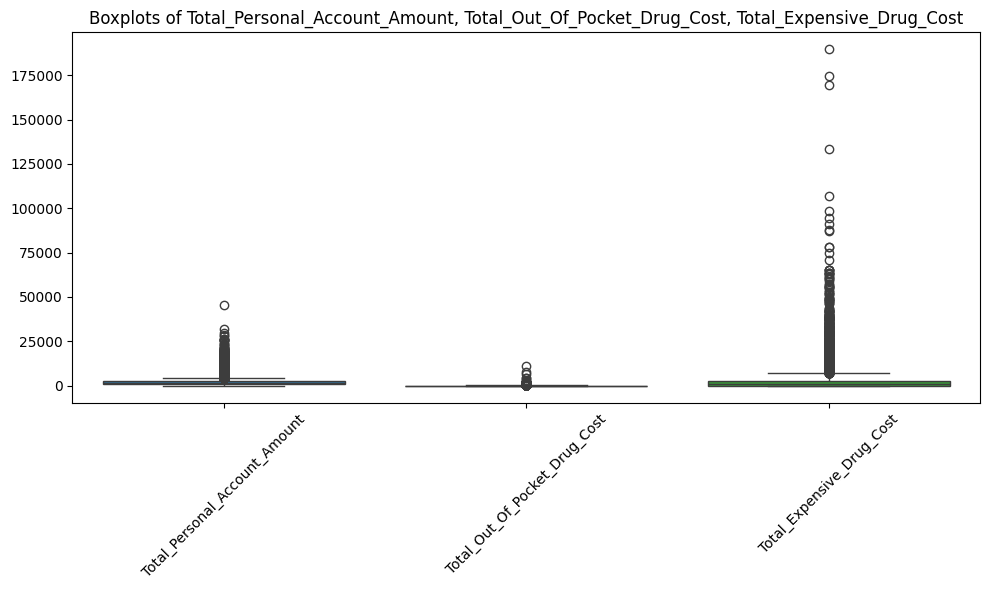

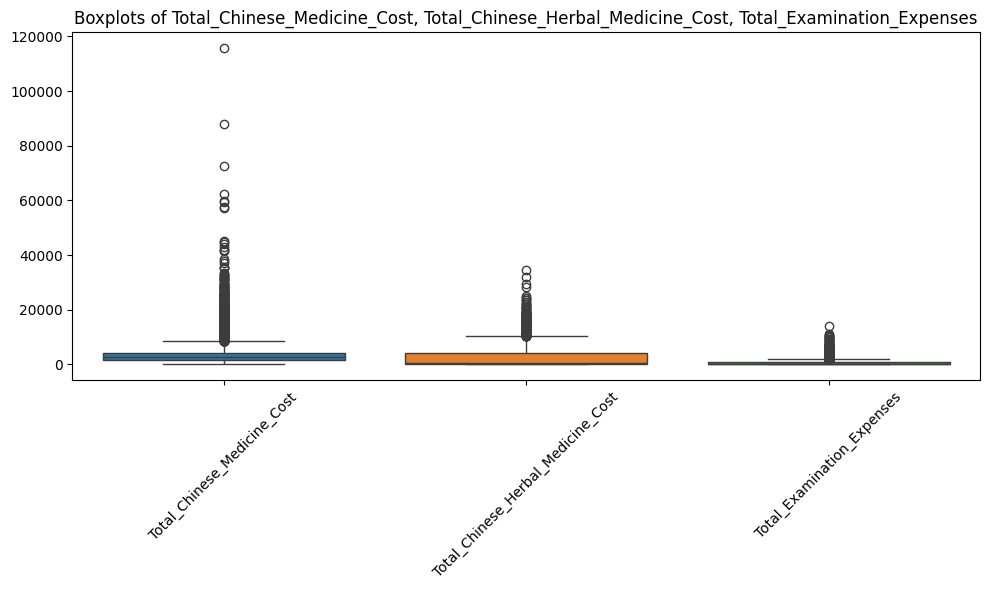

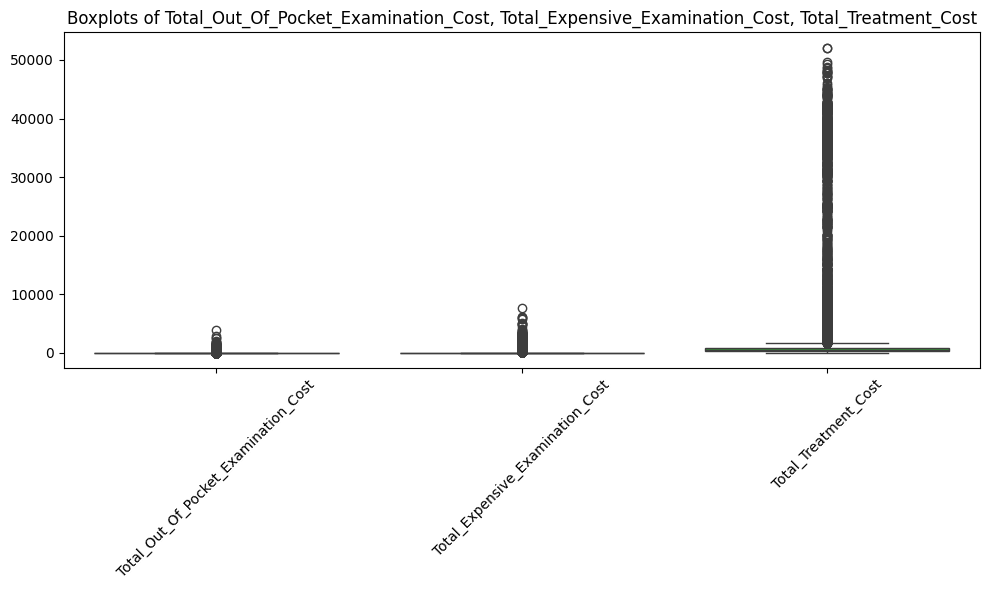

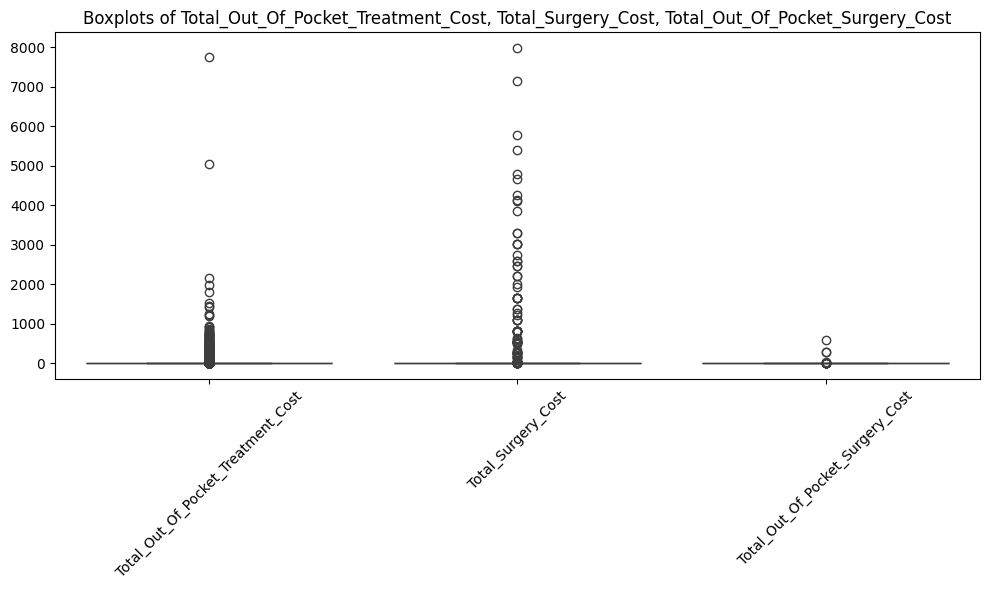

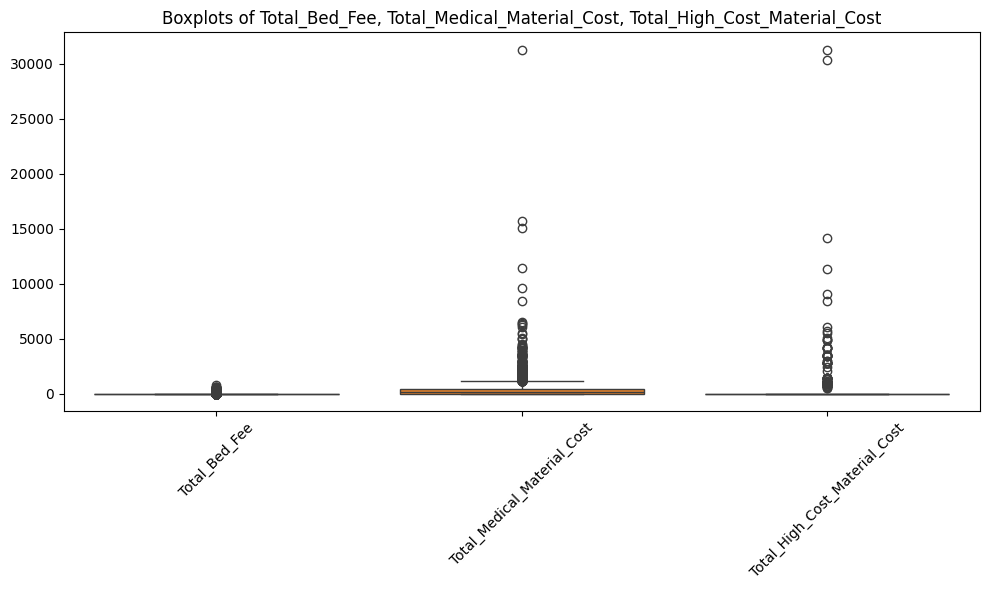

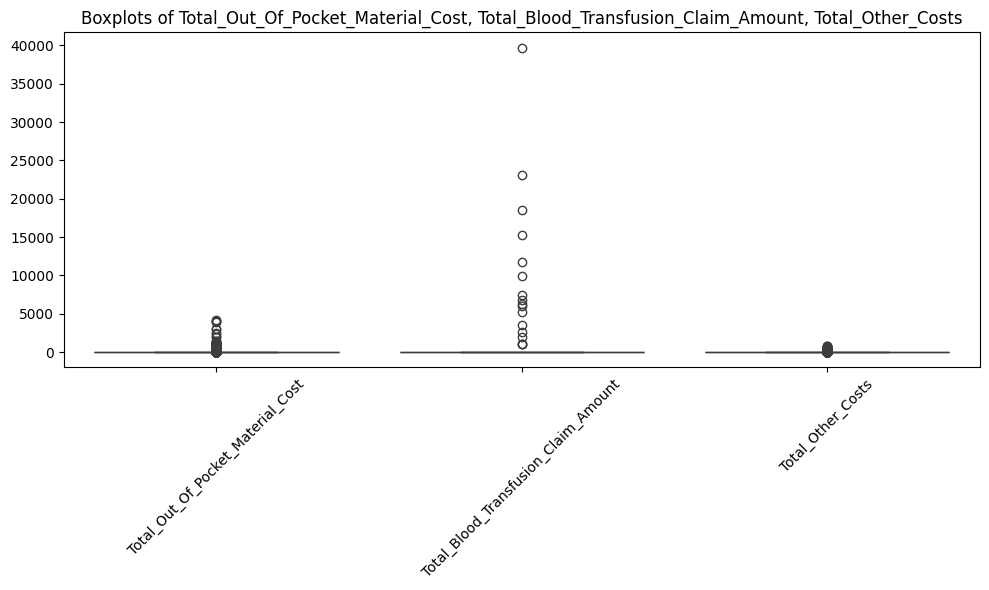

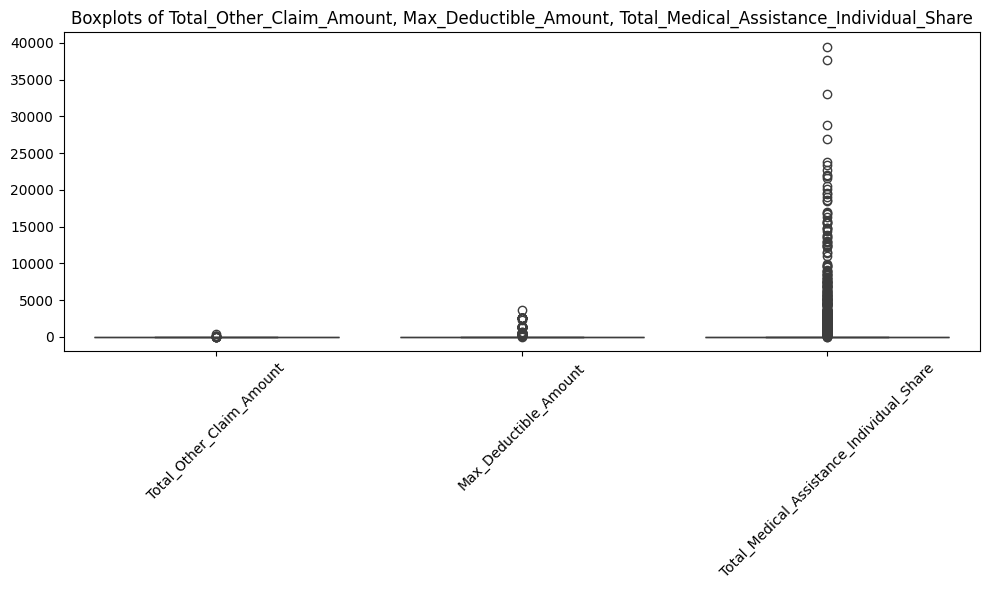

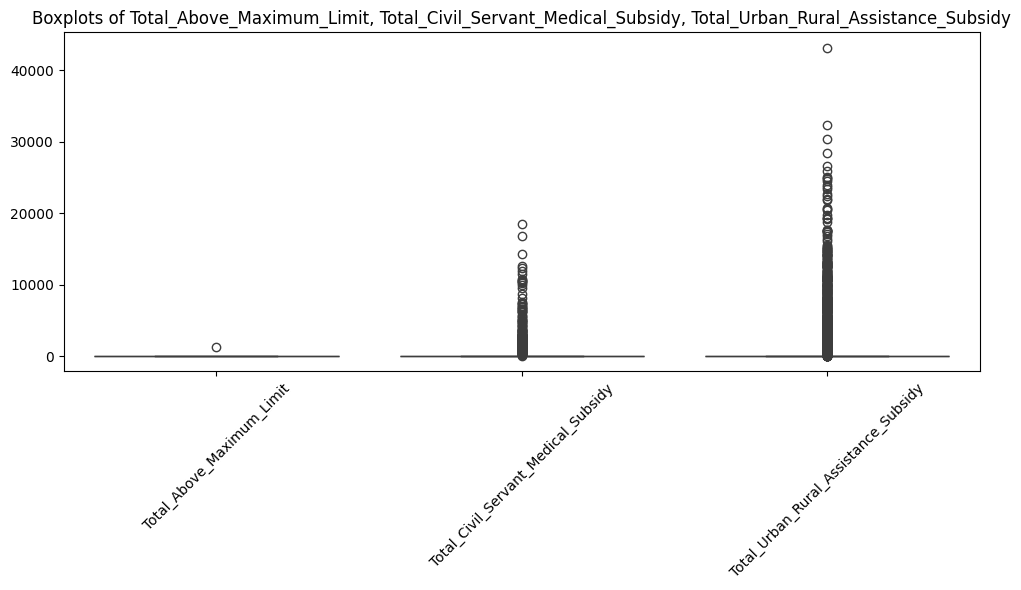

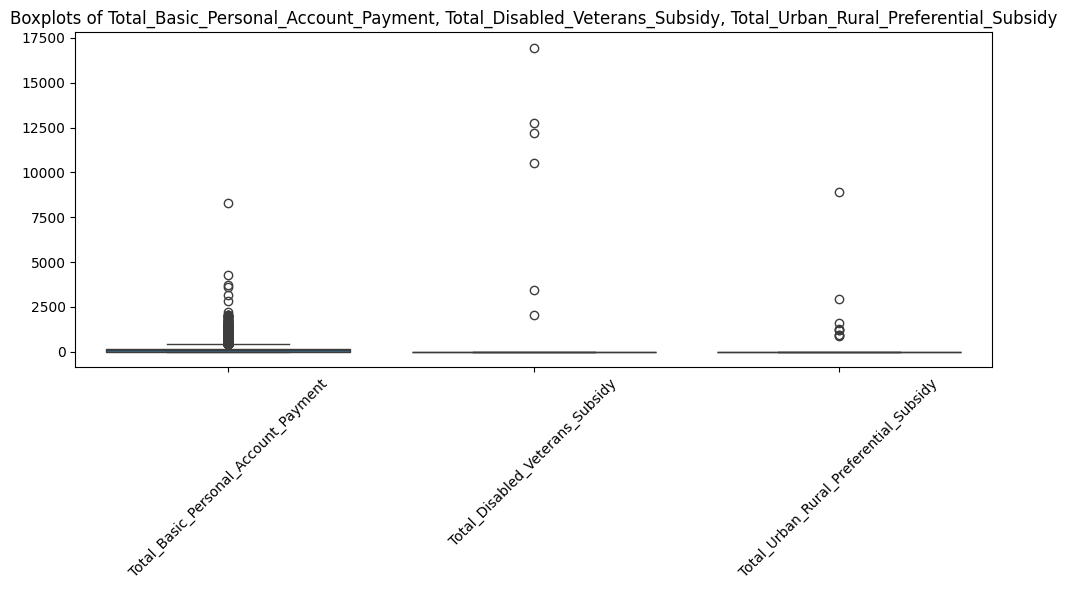

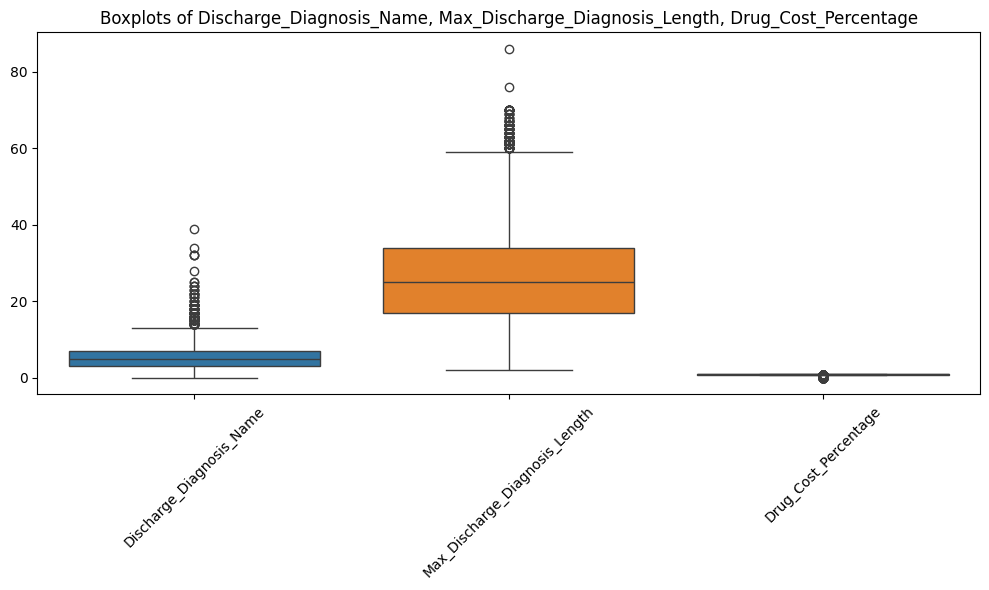

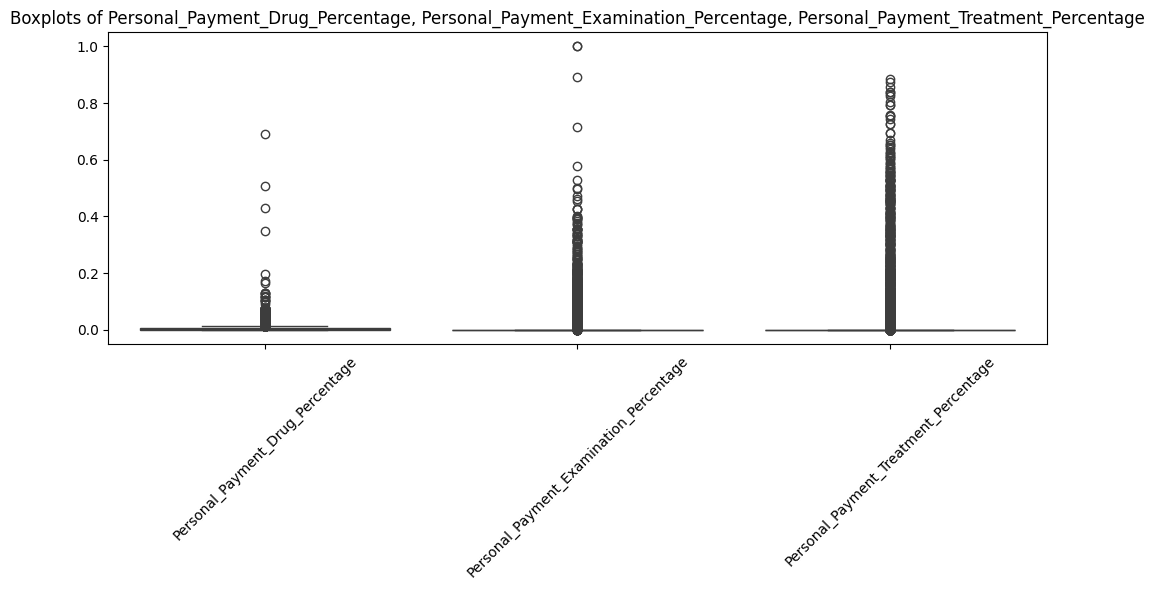

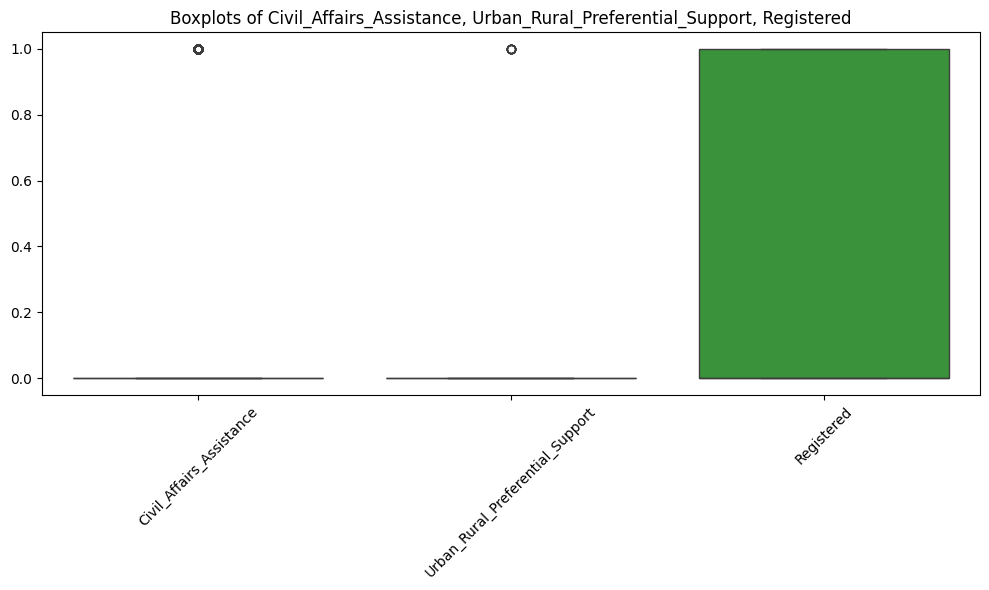

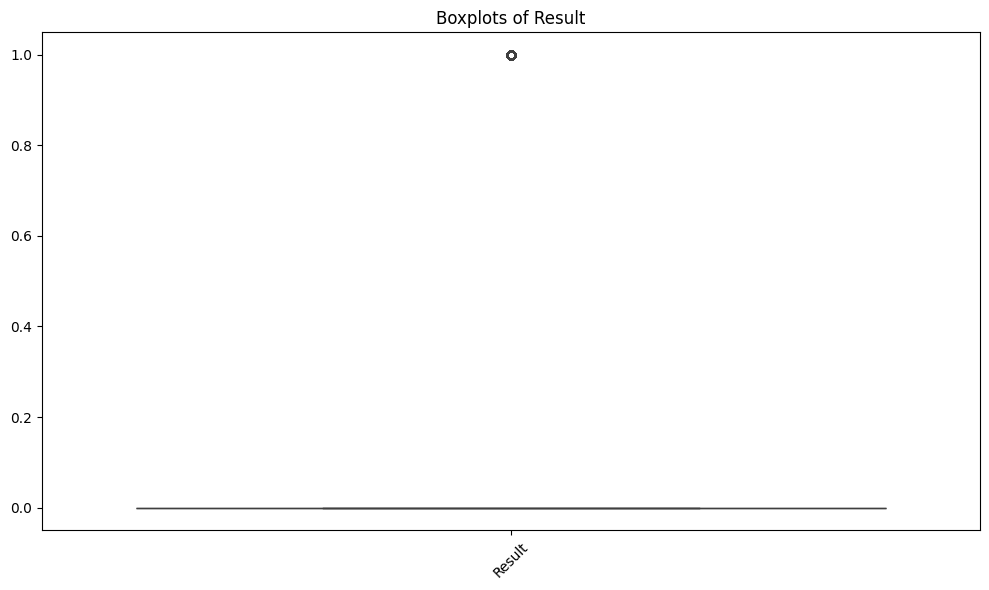

In [14]:
num_cols = df.select_dtypes(include=np.number).columns
vars_per_plot = 3

# Plot boxplots in groups
for i in range(0, len(num_cols), vars_per_plot):
    cols_to_plot = num_cols[i:i + vars_per_plot]
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df[cols_to_plot])
    plt.title(f'Boxplots of {", ".join(cols_to_plot)}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<span style="font-size:18px;">The is a presence of outliers in most of the variables</span>

# Model Picking - Lazy Predict

## 1. Lazy Predict

In [15]:
X, y = df.drop(columns=['Result']), df['Result']

In [16]:
feature_names = X.columns

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test = StandardScaler().fit_transform(X_train), StandardScaler().fit_transform(X_test)

In [18]:
models, _ = LazyClassifier(verbose=0, ignore_warnings=True).fit(X_train, X_test, y_train, y_test)
print(models)

  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
 97%|███████████████████████████████████████████████████████████████████████████████▍  | 31/32 [02:14<00:02,  2.12s/it]

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005176 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5688
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795


100%|██████████████████████████████████████████████████████████████████████████████████| 32/32 [02:16<00:00,  4.25s/it]


                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
NearestCentroid                    0.90               0.73     0.73      0.92   
DecisionTreeClassifier             0.94               0.73     0.73      0.94   
LinearDiscriminantAnalysis         0.96               0.71     0.71      0.95   
BaggingClassifier                  0.96               0.70     0.70      0.96   
Perceptron                         0.91               0.69     0.69      0.92   
XGBClassifier                      0.96               0.68     0.68      0.96   
LGBMClassifier                     0.96               0.68     0.68      0.96   
BernoulliNB                        0.57               0.67     0.67      0.69   
RandomForestClassifier             0.97               0.67     0.67      0.96   
SGDClassifier                      0.95               0.66     0.66      0.95   
ExtraTreeClassifier         

## Models To be based on an ROC-AUC threshold of 0.65
1. **NearestCentroid**
2. **DecisionTreeClassifier**
3. **LinearDiscriminantAnalysis**
4. **BaggingClassifier** 
5. **Perceptron**
6. **XGBClassifier**
7. **LGBMClassifier**
8. **BernoulliNB** 
9. **RandomForestClassifier**
10. **SGDClassifier**
11. **ExtraTreeClassifier**
12. **ExtraTreesClassifier**
13. **KNeighbours Classifier**

# Modelling

In [19]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    auc,
    roc_curve,
    roc_auc_score,
    matthews_corrcoef
)
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import BaggingClassifier, ExtraTreesClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import Perceptron, SGDClassifier, LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import NearestCentroid, KNeighborsClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from collections import Counter

## Recursive Feature Elimination (RFE)

In [20]:
# Applying RFE
estimator = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

selector = RFECV(estimator=estimator, step=1, cv=cv, scoring='accuracy', n_jobs=-1)
selector.fit(X_train, y_train)

print("Optimal number of features selected:", selector.n_features_)

Optimal number of features selected: 20


In [21]:
selected_features = np.array(feature_names)[selector.support_]
print("Selected features:")
print(selected_features.tolist())

Selected features:
['Days_Visited_Two_Hospitals', 'Months_Visited', 'Max_Monthly_Visit_Days', 'Max_Monthly_Pooled_Amount', 'Max_Monthly_Drug_Cost', 'Total_Personal_Account_Amount', 'Total_Out_Of_Pocket_Drug_Cost', 'Total_Expensive_Drug_Cost', 'Total_Chinese_Medicine_Cost', 'Total_Chinese_Herbal_Medicine_Cost', 'Total_Examination_Expenses', 'Total_Treatment_Cost', 'Total_Medical_Material_Cost', 'Total_Medical_Assistance_Individual_Share', 'Total_Urban_Rural_Assistance_Subsidy', 'Total_Basic_Personal_Account_Payment', 'Discharge_Diagnosis_Name', 'Max_Discharge_Diagnosis_Length', 'Drug_Cost_Percentage', 'Personal_Payment_Drug_Percentage']


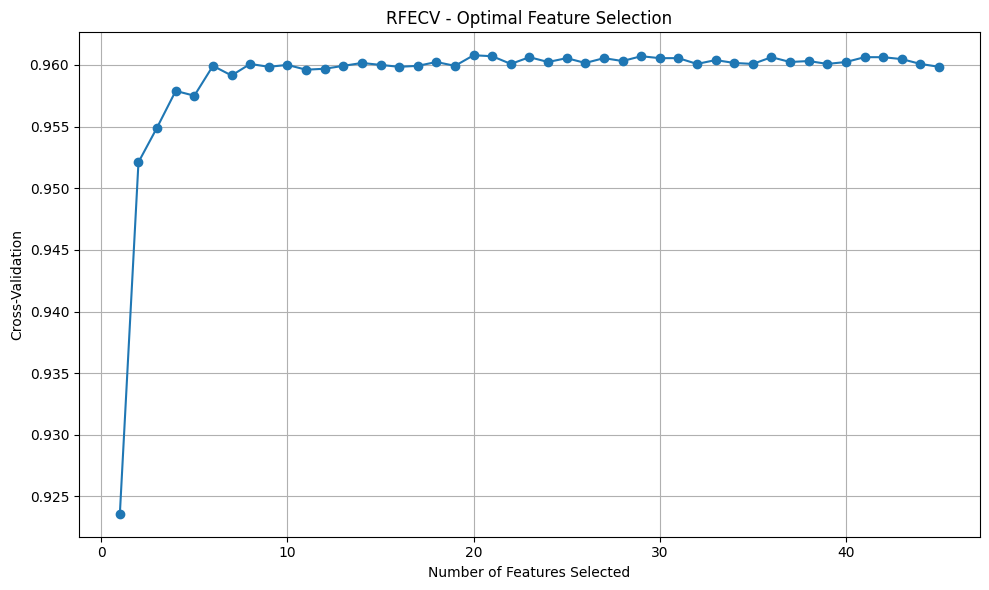

In [22]:
# Plot performance vs number of features
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(selector.cv_results_['mean_test_score']) + 1), selector.cv_results_['mean_test_score'], marker='o')
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validation")
plt.title("RFECV - Optimal Feature Selection")
plt.grid(True)
plt.tight_layout()
plt.show()


Feature importances:
Max_Monthly_Pooled_Amount                   0.13
Max_Monthly_Drug_Cost                       0.10
Total_Personal_Account_Amount               0.08
Max_Monthly_Visit_Days                      0.07
Total_Treatment_Cost                        0.06
Drug_Cost_Percentage                        0.06
Total_Chinese_Medicine_Cost                 0.05
Total_Out_Of_Pocket_Drug_Cost               0.05
Total_Examination_Expenses                  0.04
Personal_Payment_Drug_Percentage            0.04
Total_Medical_Material_Cost                 0.04
Max_Discharge_Diagnosis_Length              0.04
Total_Expensive_Drug_Cost                   0.04
Discharge_Diagnosis_Name                    0.04
Total_Basic_Personal_Account_Payment        0.03
Total_Chinese_Herbal_Medicine_Cost          0.03
Total_Medical_Assistance_Individual_Share   0.03
Days_Visited_Two_Hospitals                  0.03
Total_Urban_Rural_Assistance_Subsidy        0.03
Months_Visited                              0.0

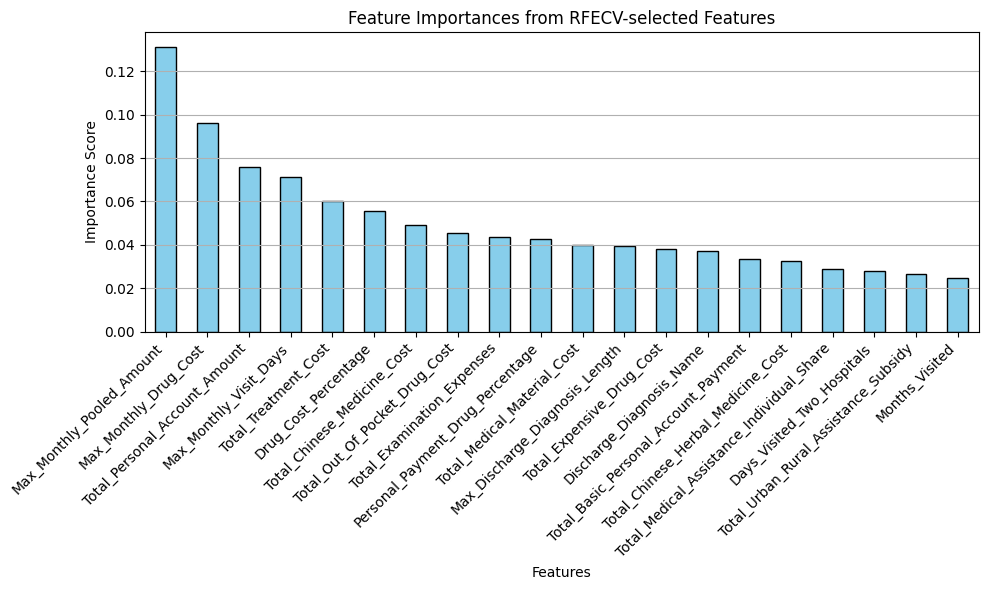

In [23]:
feature_importances = selector.estimator_.feature_importances_
important_features = pd.Series(feature_importances, index=selected_features)
important_features = important_features.sort_values(ascending=False)

print("\nFeature importances:")
print(important_features)


# Plot feature importances
plt.figure(figsize=(10, 6))
important_features.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Feature Importances from RFECV-selected Features")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

In [24]:
# Transform train and test sets based on selected features
X_train_rfe = selector.transform(X_train)
X_test_rfe = selector.transform(X_test)
y_train_rfe = y_train
y_test_rfe = y_test

# SMOTE

In [25]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_rfe_smote, y_train_rfe_smote = smote.fit_resample(X_train_rfe, y_train_rfe)

In [26]:
# Show class distribution after SMOTE
counter = Counter(y_train_rfe_smote)
print("Class distribution after SMOTE:", counter)

Class distribution after SMOTE: Counter({0: 12159, 1: 12159})


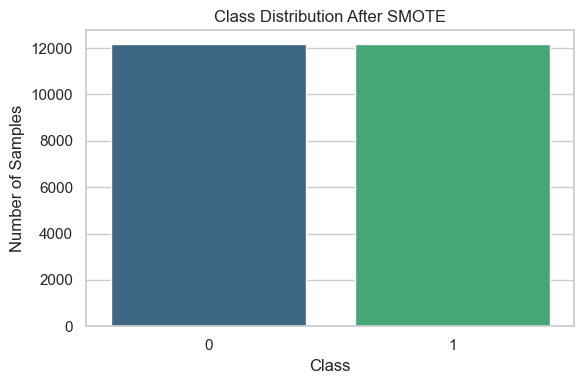

In [27]:
# Plot class distribution
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.barplot(x=list(counter.keys()), y=list(counter.values()), palette="viridis")

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 1. Nearest Centroid

In [28]:
# Initialize and train Model
nc = NearestCentroid()
nc.fit(X_train_rfe_smote, y_train_rfe_smote)

NearestCentroid()

In [29]:
# Make predictions
y_pred_NC = nc.predict(X_test_rfe)

In [30]:
# Evaluating the NC model
accuracy_NC = accuracy_score(y_test_rfe, y_pred_NC)
conf_matrix_NC = confusion_matrix(y_test_rfe, y_pred_NC)
class_report_NC = classification_report(y_test_rfe, y_pred_NC)

TP_NC = conf_matrix_NC[1, 1]
FN_NC = conf_matrix_NC[1, 0]
FP_NC = conf_matrix_NC[0, 1]
TN_NC = conf_matrix_NC[0, 0]

TPR_NC = TP_NC / (TP_NC + FN_NC) if (TP_NC + FN_NC) > 0 else 0
FPR_NC = FP_NC / (FP_NC + TN_NC) if (FP_NC + TN_NC) > 0 else 0
balanced_accuracy_NC = (TPR_NC + (TN_NC / (TN_NC + FP_NC))) / 2 if (TN_NC + FP_NC) > 0 else 0

print("Evaluation Metrics for NC:")
print(f'Accuracy: {accuracy_NC:.4f}')
print(f'True Positive Rate (TPR): {TPR_NC:.4f}')
print(f'False Positive Rate (FPR): {FPR_NC:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_NC:.4f}')
print('\nClassification Report:')
print(class_report_NC)

Evaluation Metrics for NC:
Accuracy: 0.8994
True Positive Rate (TPR): 0.5592
False Positive Rate (FPR): 0.0837
Balanced Accuracy: 0.7378

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95      3048
           1       0.25      0.56      0.35       152

    accuracy                           0.90      3200
   macro avg       0.61      0.74      0.65      3200
weighted avg       0.94      0.90      0.92      3200



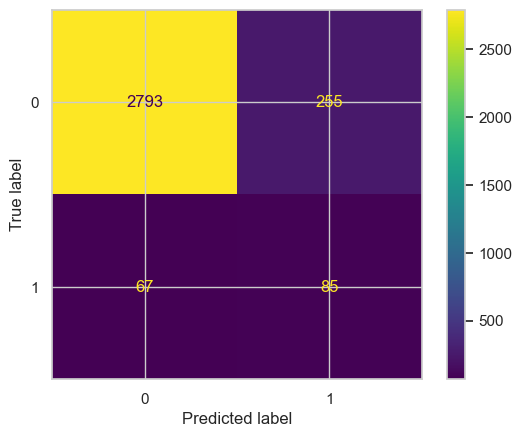

In [31]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_NC, display_labels=nc.classes_)
disp.plot()
plt.show()

AUC-PR: 0.4150740131578947
ROC-AUC: 0.7550
Matthews Correlation Coefficient (MCC): 0.3282


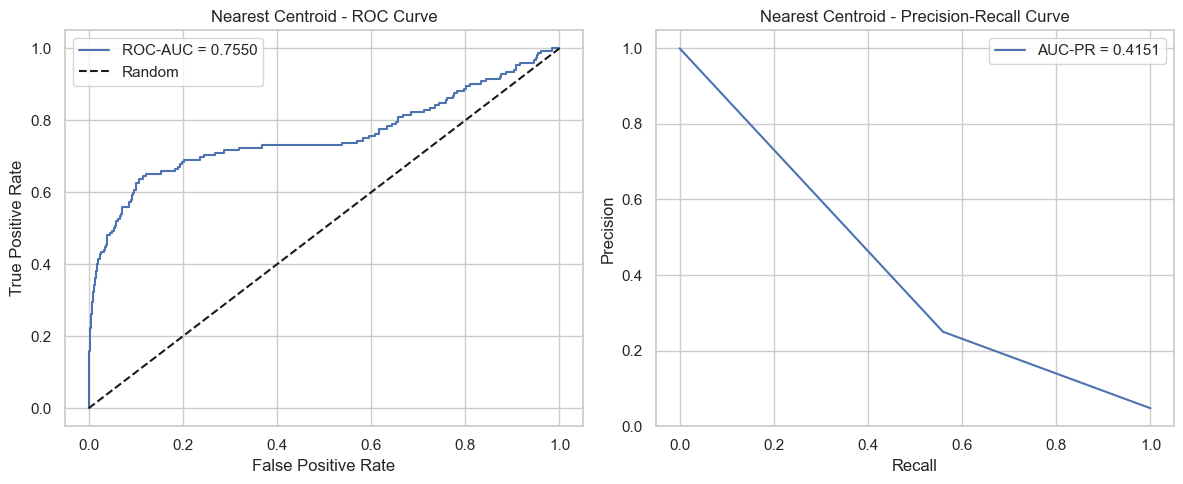

In [32]:
# AUC-OC, AUC-PR and MCC
precision_NC, recall_NC, _ = precision_recall_curve(y_test_rfe, y_pred_NC)
auc_pr_NC = auc(recall_NC, precision_NC)
print("AUC-PR:", auc_pr_NC)

try:
    decision_scores_NC = nc.decision_function(X_test_rfe)
    fpr_roc_NC, tpr_roc_NC, _ = roc_curve(y_test_rfe, decision_scores_NC)
    roc_auc_NC = auc(fpr_roc_NC, tpr_roc_NC)
    print(f"ROC-AUC: {roc_auc_NC:.4f}")
except:
    print("ROC-AUC: Not available (using predicted labels)")

mcc_NC = matthews_corrcoef(y_test_rfe, y_pred_NC)
print(f"Matthews Correlation Coefficient (MCC): {mcc_NC:.4f}")

# ROC and Precision-recall Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_NC, tpr_roc_NC, label=f'ROC-AUC = {roc_auc_NC:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Nearest Centroid - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_NC, precision_NC, label=f'AUC-PR = {auc_pr_NC:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Nearest Centroid - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 2. Decision Tree Classifier

In [33]:
# Initialize and train Model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_rfe_smote, y_train_rfe_smote)

DecisionTreeClassifier(random_state=42)

In [34]:
# Make predictions
y_pred_DT = dt.predict(X_test_rfe)

In [35]:
# Evaluating the DT model
accuracy_DT = accuracy_score(y_test_rfe, y_pred_DT)
conf_matrix_DT = confusion_matrix(y_test_rfe, y_pred_DT)
class_report_DT = classification_report(y_test_rfe, y_pred_DT)

TP_DT = conf_matrix_DT[1, 1]
FN_DT = conf_matrix_DT[1, 0]
FP_DT = conf_matrix_DT[0, 1]
TN_DT = conf_matrix_DT[0, 0]

TPR_DT = TP_DT / (TP_DT + FN_DT) if (TP_DT + FN_DT) > 0 else 0
FPR_DT = FP_DT / (FP_DT + TN_DT) if (FP_DT + TN_DT) > 0 else 0
balanced_accuracy_DT = (TPR_DT + (TN_DT / (TN_DT + FP_DT))) / 2 if (TN_DT + FP_DT) > 0 else 0

print("Evaluation Metrics for DT:")
print(f'Accuracy: {accuracy_DT:.4f}')
print(f'True Positive Rate (TPR): {TPR_DT:.4f}')
print(f'False Positive Rate (FPR): {FPR_DT:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_DT:.4f}')
print('\nClassification Report:')
print(class_report_DT)

Evaluation Metrics for DT:
Accuracy: 0.7063
True Positive Rate (TPR): 0.5921
False Positive Rate (FPR): 0.2881
Balanced Accuracy: 0.6520

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.71      0.82      3048
           1       0.09      0.59      0.16       152

    accuracy                           0.71      3200
   macro avg       0.53      0.65      0.49      3200
weighted avg       0.93      0.71      0.79      3200



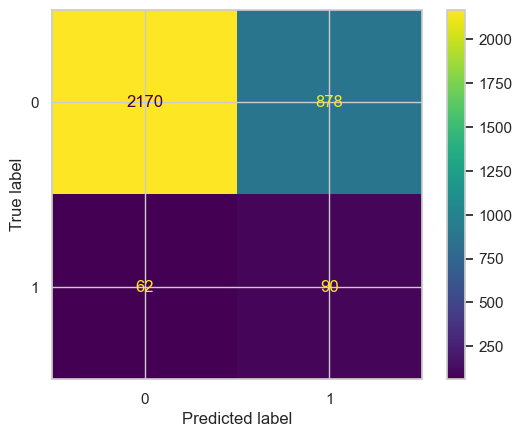

In [36]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_DT, display_labels=dt.classes_)
disp.plot()
plt.show()

AUC-PR: 0.35222773488473247
ROC-AUC: 0.6520
Matthews Correlation Coefficient (MCC): 0.1408


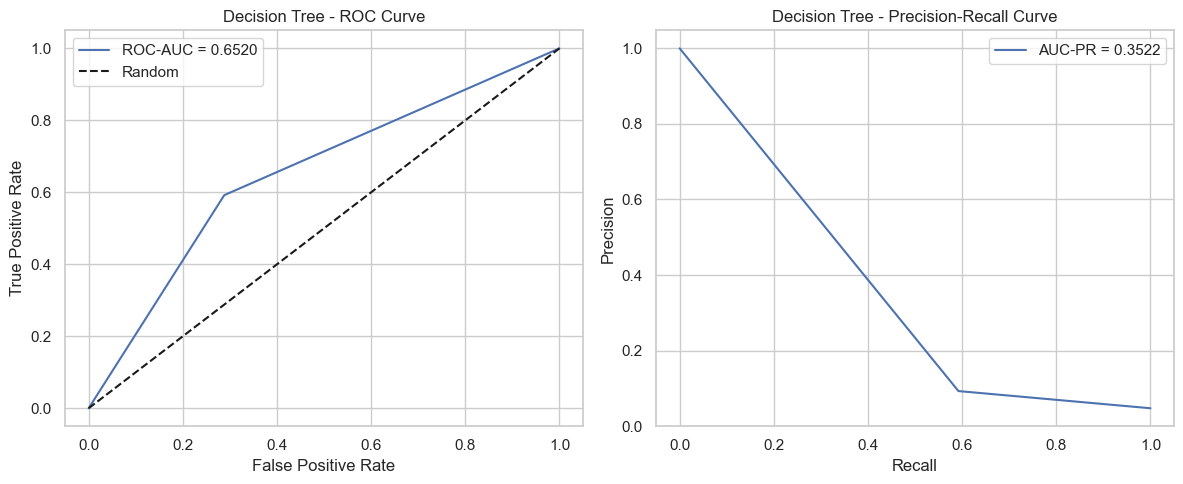

In [37]:
# ROC-AUC, AUC-PR and MCC
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_DT)
auc_pr_DT = auc(recall, precision)

y_pred_proba_DT = dt.predict_proba(X_test_rfe)[:, 1]
fpr_roc, tpr_roc, _ = roc_curve(y_test_rfe, y_pred_proba_DT)
roc_auc_DT = auc(fpr_roc, tpr_roc)

mcc_DT = matthews_corrcoef(y_test_rfe, y_pred_DT)

print("AUC-PR:", auc_pr_DT)
print(f"ROC-AUC: {roc_auc_DT:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_DT:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc, tpr_roc, label=f'ROC-AUC = {roc_auc_DT:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Decision Tree - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_DT:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Decision Tree - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 3. Linear Discriminant Analysis

In [38]:
# Initialize and train Model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_rfe_smote, y_train_rfe_smote)

LinearDiscriminantAnalysis()

In [39]:
# Make predictions
y_pred_LDA = lda.predict(X_test_rfe)

In [40]:
# Evaluating the LDA model
accuracy_LDA = accuracy_score(y_test_rfe, y_pred_LDA)
conf_matrix_LDA = confusion_matrix(y_test_rfe, y_pred_LDA)
class_report_LDA = classification_report(y_test_rfe, y_pred_LDA)

TP_LDA = conf_matrix_LDA[1, 1]
FN_LDA = conf_matrix_LDA[1, 0]
FP_LDA = conf_matrix_LDA[0, 1]
TN_LDA = conf_matrix_LDA[0, 0]

TPR_LDA = TP_LDA / (TP_LDA + FN_LDA) if (TP_LDA + FN_LDA) > 0 else 0
FPR_LDA = FP_LDA / (FP_LDA + TN_LDA) if (FP_LDA + TN_LDA) > 0 else 0
balanced_accuracy_LDA = (TPR_LDA + (TN_LDA / (TN_LDA + FP_LDA))) / 2 if (TN_LDA + FP_LDA) > 0 else 0

print("Evaluation Metrics for LDA:")
print(f'Accuracy: {accuracy_LDA:.4f}')
print(f'True Positive Rate (TPR): {TPR_LDA:.4f}')
print(f'False Positive Rate (FPR): {FPR_LDA:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_LDA:.4f}')
print('\nClassification Report:')
print(class_report_LDA)

Evaluation Metrics for LDA:
Accuracy: 0.8731
True Positive Rate (TPR): 0.6184
False Positive Rate (FPR): 0.1142
Balanced Accuracy: 0.7521

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      3048
           1       0.21      0.62      0.32       152

    accuracy                           0.87      3200
   macro avg       0.60      0.75      0.62      3200
weighted avg       0.94      0.87      0.90      3200



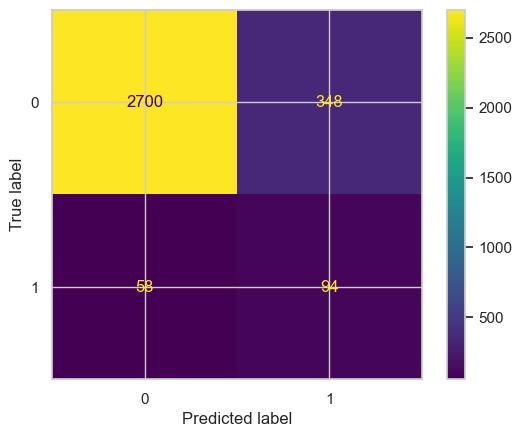

In [41]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_LDA, display_labels=lda.classes_)
disp.plot()
plt.show()

AUC-PR: 0.42460786794474875
ROC-AUC: 0.8195
Matthews Correlation Coefficient (MCC): 0.3109


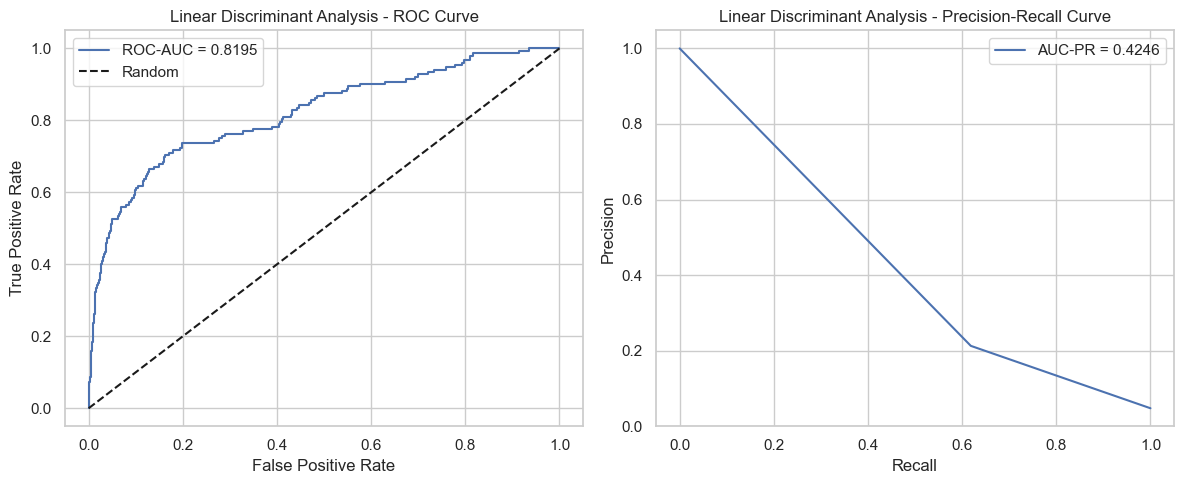

In [42]:
# ROC-AUC, AUC-PR and MCC
precision_LDA, recall_LDA, _ = precision_recall_curve(y_test_rfe, y_pred_LDA)
auc_pr_LDA = auc(recall_LDA, precision_LDA)

y_pred_proba_LDA = lda.predict_proba(X_test_rfe)[:, 1]
fpr_roc_LDA, tpr_roc_LDA, _ = roc_curve(y_test_rfe, y_pred_proba_LDA)
roc_auc_LDA = auc(fpr_roc_LDA, tpr_roc_LDA)

mcc_LDA = matthews_corrcoef(y_test_rfe, y_pred_LDA)

print("AUC-PR:", auc_pr_LDA)
print(f"ROC-AUC: {roc_auc_LDA:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_LDA:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_LDA, tpr_roc_LDA, label=f'ROC-AUC = {roc_auc_LDA:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Linear Discriminant Analysis - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_LDA, precision_LDA, label=f'AUC-PR = {auc_pr_LDA:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Linear Discriminant Analysis - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 4. Bagging Classifier

In [43]:
# Initialize and train Model
bagging = BaggingClassifier(random_state=42)
bagging.fit(X_train_rfe_smote, y_train_rfe_smote)

BaggingClassifier(random_state=42)

In [44]:
# Make predictions
y_pred_BAG = bagging.predict(X_test_rfe)

In [45]:
# Evaluating the BAG model
accuracy_BAG = accuracy_score(y_test_rfe, y_pred_BAG)
conf_matrix_BAG = confusion_matrix(y_test_rfe, y_pred_BAG)
class_report_BAG = classification_report(y_test_rfe, y_pred_BAG)

TP_BAG = conf_matrix_BAG[1, 1]
FN_BAG = conf_matrix_BAG[1, 0]
FP_BAG = conf_matrix_BAG[0, 1]
TN_BAG = conf_matrix_BAG[0, 0]

TPR_BAG = TP_BAG / (TP_BAG + FN_BAG) if (TP_BAG + FN_BAG) > 0 else 0
FPR_BAG = FP_BAG / (FP_BAG + TN_BAG) if (FP_BAG + TN_BAG) > 0 else 0
balanced_accuracy_BAG = (TPR_BAG + (TN_BAG / (TN_BAG + FP_BAG))) / 2 if (TN_BAG + FP_BAG) > 0 else 0

print("Evaluation Metrics for BAG:")
print(f'Accuracy: {accuracy_BAG:.4f}')
print(f'True Positive Rate (TPR): {TPR_BAG:.4f}')
print(f'False Positive Rate (FPR): {FPR_BAG:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_BAG:.4f}')
print('\nClassification Report:')
print(class_report_BAG)

Evaluation Metrics for BAG:
Accuracy: 0.7438
True Positive Rate (TPR): 0.5395
False Positive Rate (FPR): 0.2461
Balanced Accuracy: 0.6467

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.75      0.85      3048
           1       0.10      0.54      0.17       152

    accuracy                           0.74      3200
   macro avg       0.53      0.65      0.51      3200
weighted avg       0.93      0.74      0.82      3200



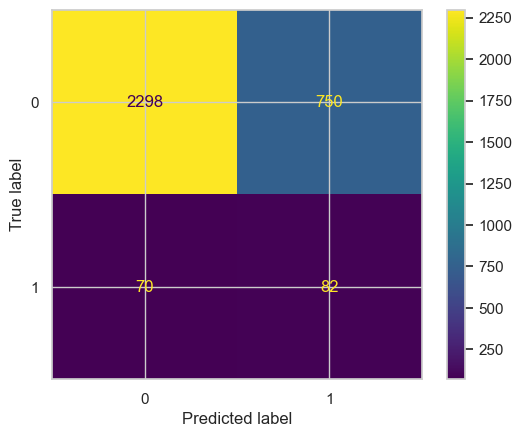

In [46]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_BAG, display_labels=bagging.classes_)
disp.plot()
plt.show()

AUC-PR: 0.3299531882591093
ROC-AUC: 0.7209
Matthews Correlation Coefficient (MCC): 0.1423


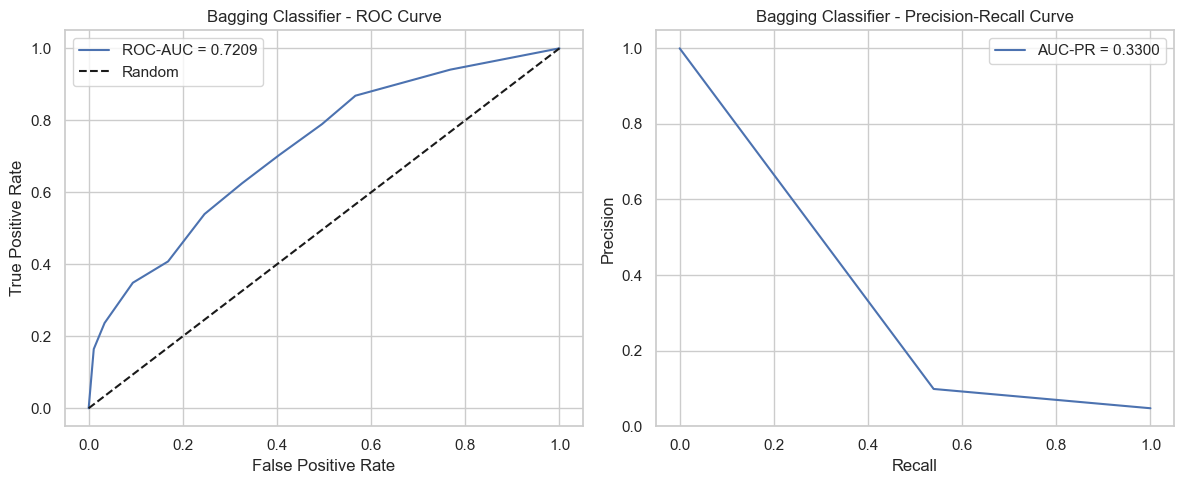

In [47]:
# ROC-AUC, AUC-PR and MCC
precision_BAG, recall_BAG, _ = precision_recall_curve(y_test_rfe, y_pred_BAG)
auc_pr_BAG = auc(recall_BAG, precision_BAG)

y_pred_proba_BAG = bagging.predict_proba(X_test_rfe)[:, 1]
fpr_roc_BAG, tpr_roc_BAG, _ = roc_curve(y_test_rfe, y_pred_proba_BAG)
roc_auc_BAG = auc(fpr_roc_BAG, tpr_roc_BAG)

mcc_BAG = matthews_corrcoef(y_test_rfe, y_pred_BAG)

print("AUC-PR:", auc_pr_BAG)
print(f"ROC-AUC: {roc_auc_BAG:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_BAG:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_BAG, tpr_roc_BAG, label=f'ROC-AUC = {roc_auc_BAG:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Bagging Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_BAG, precision_BAG, label=f'AUC-PR = {auc_pr_BAG:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Bagging Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 5. Perceptron

In [48]:
# Initialize and train Model
perceptron = Perceptron(random_state=42)
perceptron.fit(X_train_rfe_smote, y_train_rfe_smote)

Perceptron(random_state=42)

In [49]:
# Make predictions
y_pred_PRC = perceptron.predict(X_test_rfe)

In [50]:
# Evaluating the PRC model
accuracy_PRC = accuracy_score(y_test_rfe, y_pred_PRC)
conf_matrix_PRC = confusion_matrix(y_test_rfe, y_pred_PRC)
class_report_PRC = classification_report(y_test_rfe, y_pred_PRC)

TP_PRC = conf_matrix_PRC[1, 1]
FN_PRC = conf_matrix_PRC[1, 0]
FP_PRC = conf_matrix_PRC[0, 1]
TN_PRC = conf_matrix_PRC[0, 0]

TPR_PRC = TP_PRC / (TP_PRC + FN_PRC) if (TP_PRC + FN_PRC) > 0 else 0
FPR_PRC = FP_PRC / (FP_PRC + TN_PRC) if (FP_PRC + TN_PRC) > 0 else 0
balanced_accuracy_PRC = (TPR_PRC + (TN_PRC / (TN_PRC + FP_PRC))) / 2 if (TN_PRC + FP_PRC) > 0 else 0

print("Evaluation Metrics for PRC:")
print(f'Accuracy: {accuracy_PRC:.4f}')
print(f'True Positive Rate (TPR): {TPR_PRC:.4f}')
print(f'False Positive Rate (FPR): {FPR_PRC:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_PRC:.4f}')
print('\nClassification Report:')
print(class_report_PRC)

Evaluation Metrics for PRC:
Accuracy: 0.4978
True Positive Rate (TPR): 0.7368
False Positive Rate (FPR): 0.5141
Balanced Accuracy: 0.6114

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.49      0.65      3048
           1       0.07      0.74      0.12       152

    accuracy                           0.50      3200
   macro avg       0.52      0.61      0.39      3200
weighted avg       0.93      0.50      0.62      3200



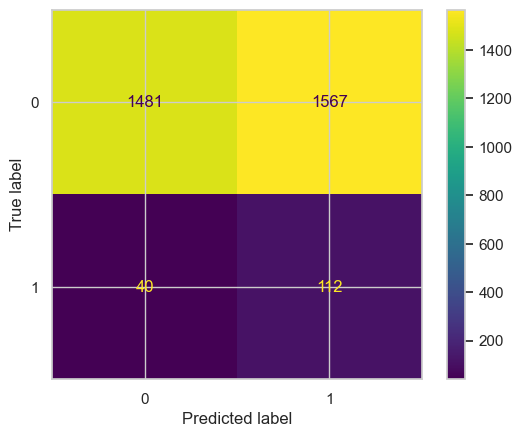

In [51]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_PRC, display_labels=perceptron.classes_)
disp.plot()
plt.show()

AUC-PR: 0.4080242390520673
ROC-AUC: 0.7141
Matthews Correlation Coefficient (MCC): 0.0949


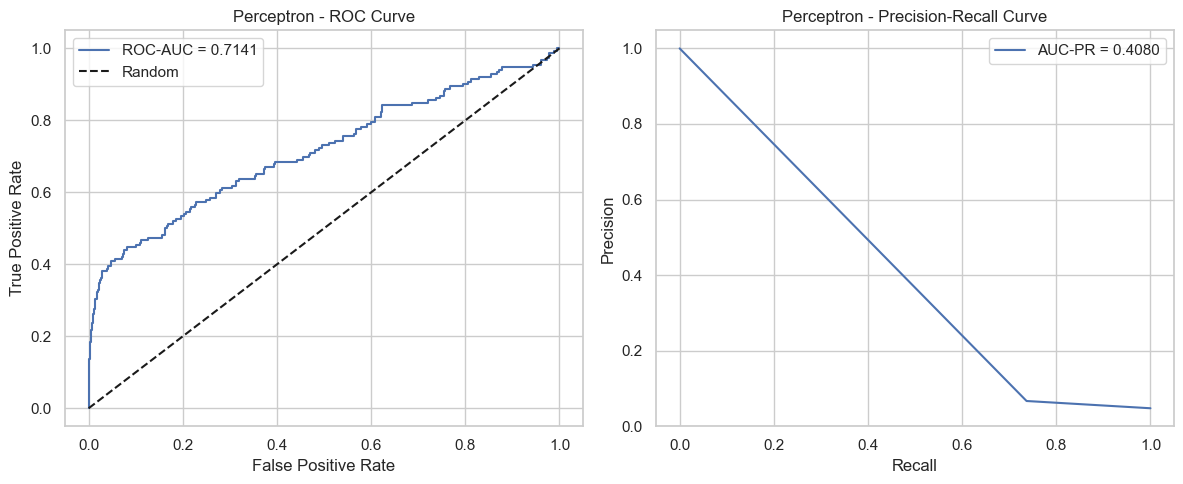

In [52]:
# ROC-AUC, AUC-PR and MCC
precision_PRC, recall_PRC, _ = precision_recall_curve(y_test_rfe, y_pred_PRC)
auc_pr_PRC = auc(recall_PRC, precision_PRC)
print("AUC-PR:", auc_pr_PRC)

try:
    decision_scores_PRC = perceptron.decision_function(X_test_rfe)
    fpr_roc_PRC, tpr_roc_PRC, _ = roc_curve(y_test_rfe, decision_scores_PRC)
    roc_auc_PRC = auc(fpr_roc_PRC, tpr_roc_PRC)
    print(f"ROC-AUC: {roc_auc_PRC:.4f}")
except:
    print("ROC-AUC: Not available (using predicted labels)")

mcc_PRC = matthews_corrcoef(y_test_rfe, y_pred_PRC)
print(f"Matthews Correlation Coefficient (MCC): {mcc_PRC:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_PRC, tpr_roc_PRC, label=f'ROC-AUC = {roc_auc_PRC:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Perceptron - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_PRC, precision_PRC, label=f'AUC-PR = {auc_pr_PRC:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Perceptron - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 6. XGB Classfier

In [53]:
# Initialize and train Model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_rfe_smote, y_train_rfe_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [54]:
# Make predictions
y_pred_XGB = xgb.predict(X_test_rfe)

In [55]:
# Evaluating the XGB model
accuracy_XGB = accuracy_score(y_test_rfe, y_pred_XGB)
conf_matrix_XGB = confusion_matrix(y_test_rfe, y_pred_XGB)
class_report_XGB = classification_report(y_test_rfe, y_pred_XGB)

TP_XGB = conf_matrix_XGB[1, 1]
FN_XGB = conf_matrix_XGB[1, 0]
FP_XGB = conf_matrix_XGB[0, 1]
TN_XGB = conf_matrix_XGB[0, 0]

TPR_XGB = TP_XGB / (TP_XGB + FN_XGB) if (TP_XGB + FN_XGB) > 0 else 0
FPR_XGB = FP_XGB / (FP_XGB + TN_XGB) if (FP_XGB + TN_XGB) > 0 else 0
balanced_accuracy_XGB = (TPR_XGB + (TN_XGB / (TN_XGB + FP_XGB))) / 2 if (TN_XGB + FP_XGB) > 0 else 0

print("Evaluation Metrics for XGB:")
print(f'Accuracy: {accuracy_XGB:.4f}')
print(f'True Positive Rate (TPR): {TPR_XGB:.4f}')
print(f'False Positive Rate (FPR): {FPR_XGB:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_XGB:.4f}')
print('\nClassification Report:')
print(class_report_XGB)

Evaluation Metrics for XGB:
Accuracy: 0.1478
True Positive Rate (TPR): 0.9408
False Positive Rate (FPR): 0.8917
Balanced Accuracy: 0.5245

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.11      0.19      3048
           1       0.05      0.94      0.09       152

    accuracy                           0.15      3200
   macro avg       0.51      0.52      0.14      3200
weighted avg       0.93      0.15      0.19      3200



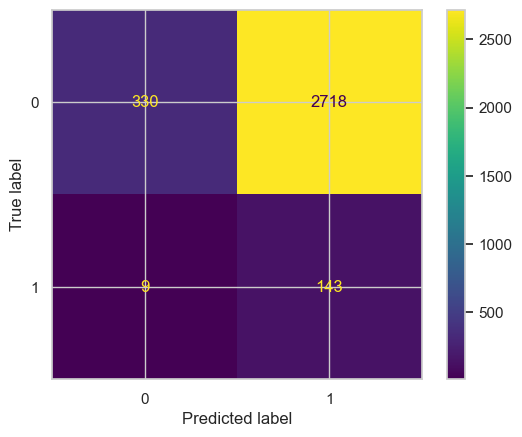

In [56]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_XGB, display_labels=xgb.classes_)
disp.plot()
plt.show()

AUC-PR XGB: 0.4967922486386799
ROC-AUC XGB: 0.6833
Matthews Correlation Coefficient (MCC) XGB: 0.0339


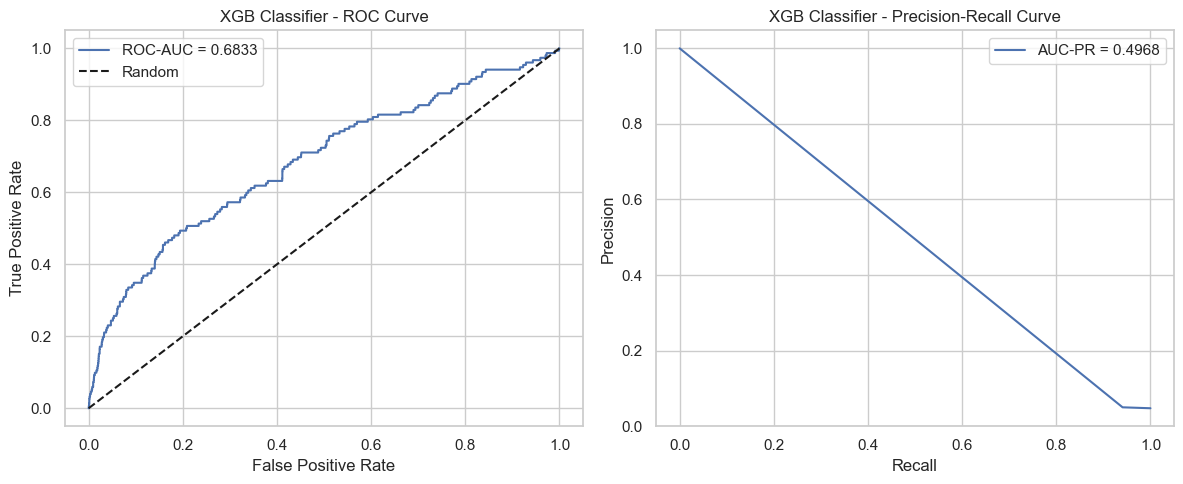

In [57]:
# ROC-AUC, AUC-PR and MCC for XGB
precision_XGB, recall_XGB, _ = precision_recall_curve(y_test_rfe, y_pred_XGB)
auc_pr_XGB = auc(recall_XGB, precision_XGB)

y_pred_proba_XGB = xgb.predict_proba(X_test_rfe)[:, 1]
fpr_roc_XGB, tpr_roc_XGB, _ = roc_curve(y_test_rfe, y_pred_proba_XGB)
roc_auc_XGB = auc(fpr_roc_XGB, tpr_roc_XGB)

mcc_XGB = matthews_corrcoef(y_test_rfe, y_pred_XGB)

print("AUC-PR XGB:", auc_pr_XGB)
print(f"ROC-AUC XGB: {roc_auc_XGB:.4f}")
print(f"Matthews Correlation Coefficient (MCC) XGB: {mcc_XGB:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_XGB, tpr_roc_XGB, label=f'ROC-AUC = {roc_auc_XGB:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('XGB Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_XGB, precision_XGB, label=f'AUC-PR = {auc_pr_XGB:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('XGB Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 7. LGBM Classifier

In [58]:
# Initialize and train Model
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train_rfe_smote, y_train_rfe_smote)

[LightGBM] [Info] Number of positive: 12159, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005816 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4926
[LightGBM] [Info] Number of data points in the train set: 24318, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(random_state=42)

In [59]:
# Make predictions
y_pred_LGBM = lgbm.predict(X_test_rfe)

In [60]:
# Evaluating the LGBM model
accuracy_LGBM = accuracy_score(y_test_rfe, y_pred_LGBM)
conf_matrix_LGBM = confusion_matrix(y_test_rfe, y_pred_LGBM)
class_report_LGBM = classification_report(y_test_rfe, y_pred_LGBM)

TP_LGBM = conf_matrix_LGBM[1, 1]
FN_LGBM = conf_matrix_LGBM[1, 0]
FP_LGBM = conf_matrix_LGBM[0, 1]
TN_LGBM = conf_matrix_LGBM[0, 0]

TPR_LGBM = TP_LGBM / (TP_LGBM + FN_LGBM) if (TP_LGBM + FN_LGBM) > 0 else 0
FPR_LGBM = FP_LGBM / (FP_LGBM + TN_LGBM) if (FP_LGBM + TN_LGBM) > 0 else 0
balanced_accuracy_LGBM = (TPR_LGBM + (TN_LGBM / (TN_LGBM + FP_LGBM))) / 2 if (TN_LGBM + FP_LGBM) > 0 else 0

print("Evaluation Metrics for LGBM:")
print(f'Accuracy: {accuracy_LGBM:.4f}')
print(f'True Positive Rate (TPR): {TPR_LGBM:.4f}')
print(f'False Positive Rate (FPR): {FPR_LGBM:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_LGBM:.4f}')
print('\nClassification Report:')
print(class_report_LGBM)

Evaluation Metrics for LGBM:
Accuracy: 0.1347
True Positive Rate (TPR): 0.9803
False Positive Rate (FPR): 0.9075
Balanced Accuracy: 0.5364

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.09      0.17      3048
           1       0.05      0.98      0.10       152

    accuracy                           0.13      3200
   macro avg       0.52      0.54      0.13      3200
weighted avg       0.94      0.13      0.17      3200



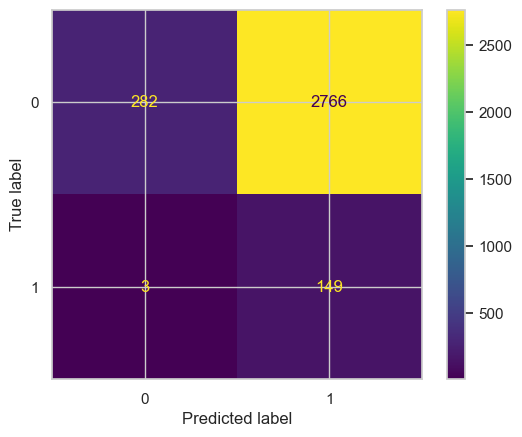

In [61]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_LGBM, display_labels=lgbm.classes_)
disp.plot()
plt.show()

AUC-PR LGBM: 0.5161577903538865
ROC-AUC LGBM: 0.6816
Matthews Correlation Coefficient (MCC) LGBM: 0.0544


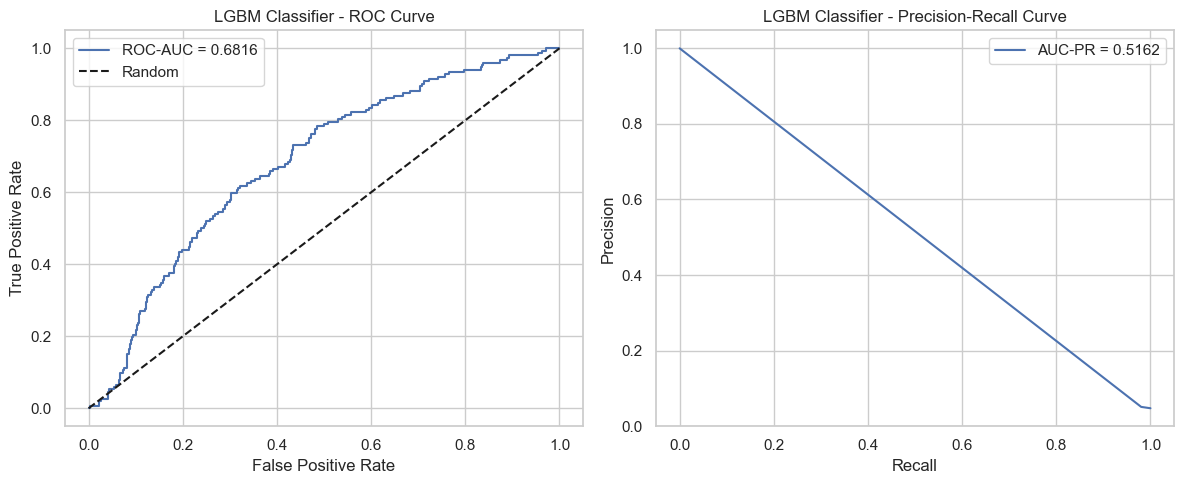

In [62]:
# ROC-AUC, AUC-PR and MCC for LGBM
precision_LGBM, recall_LGBM, _ = precision_recall_curve(y_test_rfe, y_pred_LGBM)
auc_pr_LGBM = auc(recall_LGBM, precision_LGBM)

y_pred_proba_LGBM = lgbm.predict_proba(X_test_rfe)[:, 1]
fpr_roc_LGBM, tpr_roc_LGBM, _ = roc_curve(y_test_rfe, y_pred_proba_LGBM)
roc_auc_LGBM = auc(fpr_roc_LGBM, tpr_roc_LGBM)

mcc_LGBM = matthews_corrcoef(y_test_rfe, y_pred_LGBM)

print("AUC-PR LGBM:", auc_pr_LGBM)
print(f"ROC-AUC LGBM: {roc_auc_LGBM:.4f}")
print(f"Matthews Correlation Coefficient (MCC) LGBM: {mcc_LGBM:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_LGBM, tpr_roc_LGBM, label=f'ROC-AUC = {roc_auc_LGBM:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('LGBM Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_LGBM, precision_LGBM, label=f'AUC-PR = {auc_pr_LGBM:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('LGBM Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 8. BernoulliNB Classifier

In [63]:
# Initialize and train Model
bnb = BernoulliNB()
bnb.fit(X_train_rfe_smote, y_train_rfe_smote)

BernoulliNB()

In [64]:
# Make predictions
y_pred_BNB = bnb.predict(X_test_rfe)

In [65]:
# Evaluating the BNB model
accuracy_BNB = accuracy_score(y_test_rfe, y_pred_BNB)
conf_matrix_BNB = confusion_matrix(y_test_rfe, y_pred_BNB)
class_report_BNB = classification_report(y_test_rfe, y_pred_BNB)

TP_BNB = conf_matrix_BNB[1, 1]
FN_BNB = conf_matrix_BNB[1, 0]
FP_BNB = conf_matrix_BNB[0, 1]
TN_BNB = conf_matrix_BNB[0, 0]

TPR_BNB = TP_BNB / (TP_BNB + FN_BNB) if (TP_BNB + FN_BNB) > 0 else 0
FPR_BNB = FP_BNB / (FP_BNB + TN_BNB) if (FP_BNB + TN_BNB) > 0 else 0
balanced_accuracy_BNB = (TPR_BNB + (TN_BNB / (TN_BNB + FP_BNB))) / 2 if (TN_BNB + FP_BNB) > 0 else 0

print("Evaluation Metrics for BNB:")
print(f'Accuracy: {accuracy_BNB:.4f}')
print(f'True Positive Rate (TPR): {TPR_BNB:.4f}')
print(f'False Positive Rate (FPR): {FPR_BNB:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_BNB:.4f}')
print('\nClassification Report:')
print(class_report_BNB)

Evaluation Metrics for BNB:
Accuracy: 0.7297
True Positive Rate (TPR): 0.6974
False Positive Rate (FPR): 0.2687
Balanced Accuracy: 0.7143

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.73      0.84      3048
           1       0.11      0.70      0.20       152

    accuracy                           0.73      3200
   macro avg       0.55      0.71      0.52      3200
weighted avg       0.94      0.73      0.81      3200



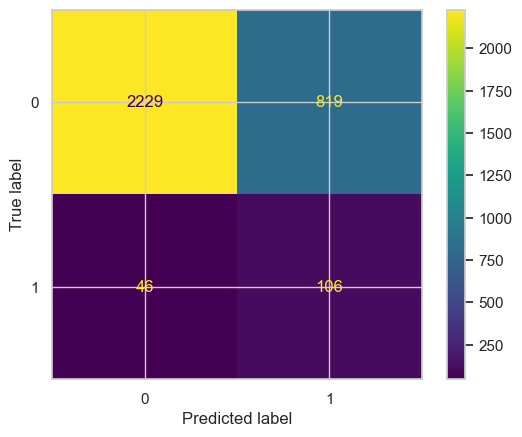

In [66]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_BNB, display_labels=bnb.classes_)
disp.plot()
plt.show()

AUC-PR BNB: 0.41316900782361304
ROC-AUC BNB: 0.7708
Matthews Correlation Coefficient (MCC) BNB: 0.2011


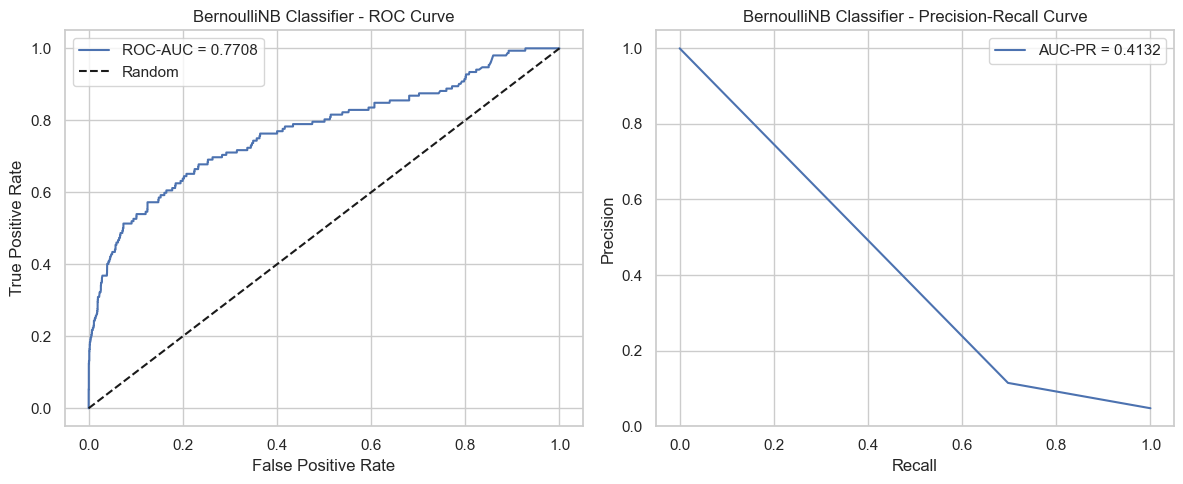

In [67]:
# ROC-AUC, AUC-PR and MCC for BNB
precision_BNB, recall_BNB, _ = precision_recall_curve(y_test_rfe, y_pred_BNB)
auc_pr_BNB = auc(recall_BNB, precision_BNB)

y_pred_proba_BNB = bnb.predict_proba(X_test_rfe)[:, 1]
fpr_roc_BNB, tpr_roc_BNB, _ = roc_curve(y_test_rfe, y_pred_proba_BNB)
roc_auc_BNB = auc(fpr_roc_BNB, tpr_roc_BNB)

mcc_BNB = matthews_corrcoef(y_test_rfe, y_pred_BNB)

print("AUC-PR BNB:", auc_pr_BNB)
print(f"ROC-AUC BNB: {roc_auc_BNB:.4f}")
print(f"Matthews Correlation Coefficient (MCC) BNB: {mcc_BNB:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_BNB, tpr_roc_BNB, label=f'ROC-AUC = {roc_auc_BNB:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('BernoulliNB Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_BNB, precision_BNB, label=f'AUC-PR = {auc_pr_BNB:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('BernoulliNB Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 9. Random Forest Classifier

In [68]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_rfe_smote, y_train_rfe_smote)

RandomForestClassifier(random_state=42)

In [69]:
# Make predictions
y_pred_RF = rf.predict(X_test_rfe)

In [70]:
# Evaluating the RF model
accuracy_RF = accuracy_score(y_test_rfe, y_pred_RF)
conf_matrix_RF = confusion_matrix(y_test_rfe, y_pred_RF)
class_report_RF = classification_report(y_test_rfe, y_pred_RF)

TP_RF = conf_matrix_RF[1, 1]
FN_RF = conf_matrix_RF[1, 0]
FP_RF = conf_matrix_RF[0, 1]
TN_RF = conf_matrix_RF[0, 0]

TPR_RF = TP_RF / (TP_RF + FN_RF) if (TP_RF + FN_RF) > 0 else 0
FPR_RF = FP_RF / (FP_RF + TN_RF) if (FP_RF + TN_RF) > 0 else 0
balanced_accuracy_RF = (TPR_RF + (TN_RF / (TN_RF + FP_RF))) / 2 if (TN_RF + FP_RF) > 0 else 0

print("Evaluation Metrics for RF:")
print(f'Accuracy: {accuracy_RF:.4f}')
print(f'True Positive Rate (TPR): {TPR_RF:.4f}')
print(f'False Positive Rate (FPR): {FPR_RF:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_RF:.4f}')
print('\nClassification Report:')
print(class_report_RF)

Evaluation Metrics for RF:
Accuracy: 0.8838
True Positive Rate (TPR): 0.5855
False Positive Rate (FPR): 0.1014
Balanced Accuracy: 0.7421

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      3048
           1       0.22      0.59      0.32       152

    accuracy                           0.88      3200
   macro avg       0.60      0.74      0.63      3200
weighted avg       0.94      0.88      0.91      3200



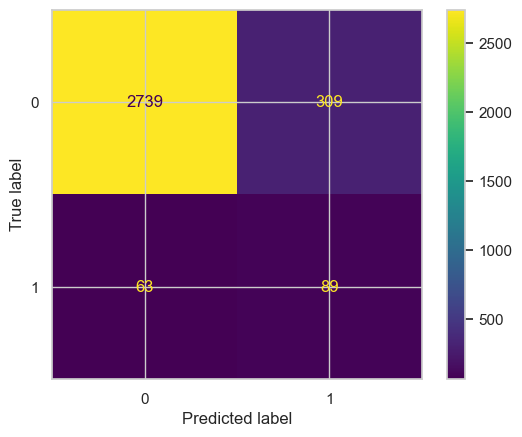

In [71]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_RF, display_labels=rf.classes_)
disp.plot()
plt.show()

AUC-PR RF: 0.41441595312086754
ROC-AUC RF: 0.8188
Matthews Correlation Coefficient (MCC) RF: 0.3121


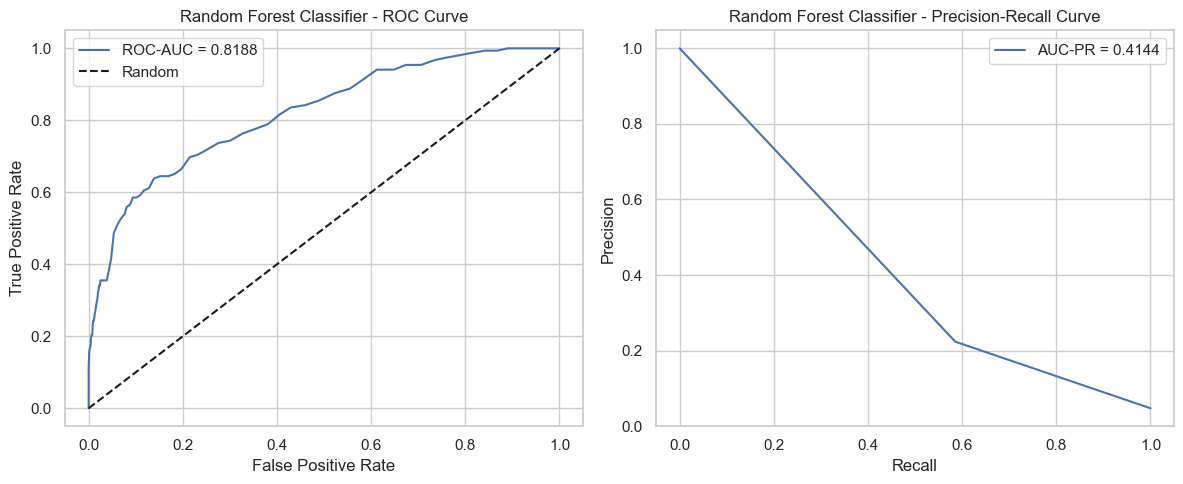

In [72]:
# ROC-AUC, AUC-PR and MCC for RF
precision_RF, recall_RF, _ = precision_recall_curve(y_test_rfe, y_pred_RF)
auc_pr_RF = auc(recall_RF, precision_RF)

y_pred_proba_RF = rf.predict_proba(X_test_rfe)[:, 1]
fpr_roc_RF, tpr_roc_RF, _ = roc_curve(y_test_rfe, y_pred_proba_RF)
roc_auc_RF = auc(fpr_roc_RF, tpr_roc_RF)

mcc_RF = matthews_corrcoef(y_test_rfe, y_pred_RF)

print("AUC-PR RF:", auc_pr_RF)
print(f"ROC-AUC RF: {roc_auc_RF:.4f}")
print(f"Matthews Correlation Coefficient (MCC) RF: {mcc_RF:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_RF, tpr_roc_RF, label=f'ROC-AUC = {roc_auc_RF:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Random Forest Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_RF, precision_RF, label=f'AUC-PR = {auc_pr_RF:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Random Forest Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 10. SGD Classifier

In [73]:
# Initialize and train Model
sgd = SGDClassifier(random_state=42)
sgd.fit(X_train_rfe_smote, y_train_rfe_smote)

SGDClassifier(random_state=42)

In [74]:
# Make predictions
y_pred_SGD = sgd.predict(X_test_rfe)

In [75]:
# Evaluating the SGD model
accuracy_SGD = accuracy_score(y_test_rfe, y_pred_SGD)
conf_matrix_SGD = confusion_matrix(y_test_rfe, y_pred_SGD)
class_report_SGD = classification_report(y_test_rfe, y_pred_SGD)

TP_SGD = conf_matrix_SGD[1, 1]
FN_SGD = conf_matrix_SGD[1, 0]
FP_SGD = conf_matrix_SGD[0, 1]
TN_SGD = conf_matrix_SGD[0, 0]

TPR_SGD = TP_SGD / (TP_SGD + FN_SGD) if (TP_SGD + FN_SGD) > 0 else 0
FPR_SGD = FP_SGD / (FP_SGD + TN_SGD) if (FP_SGD + TN_SGD) > 0 else 0
balanced_accuracy_SGD = (TPR_SGD + (TN_SGD / (TN_SGD + FP_SGD))) / 2 if (TN_SGD + FP_SGD) > 0 else 0

print("Evaluation Metrics for SGD:")
print(f'Accuracy: {accuracy_SGD:.4f}')
print(f'True Positive Rate (TPR): {TPR_SGD:.4f}')
print(f'False Positive Rate (FPR): {FPR_SGD:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_SGD:.4f}')
print('\nClassification Report:')
print(class_report_SGD)

Evaluation Metrics for SGD:
Accuracy: 0.8744
True Positive Rate (TPR): 0.6316
False Positive Rate (FPR): 0.1135
Balanced Accuracy: 0.7590

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      3048
           1       0.22      0.63      0.32       152

    accuracy                           0.87      3200
   macro avg       0.60      0.76      0.63      3200
weighted avg       0.94      0.87      0.90      3200



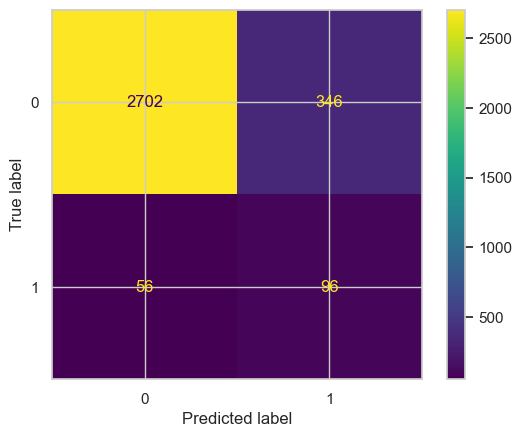

In [76]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_SGD, display_labels=sgd.classes_)
disp.plot()
plt.show()

AUC-PR: 0.4331367587520838
ROC-AUC: 0.8242
Matthews Correlation Coefficient (MCC): 0.3194


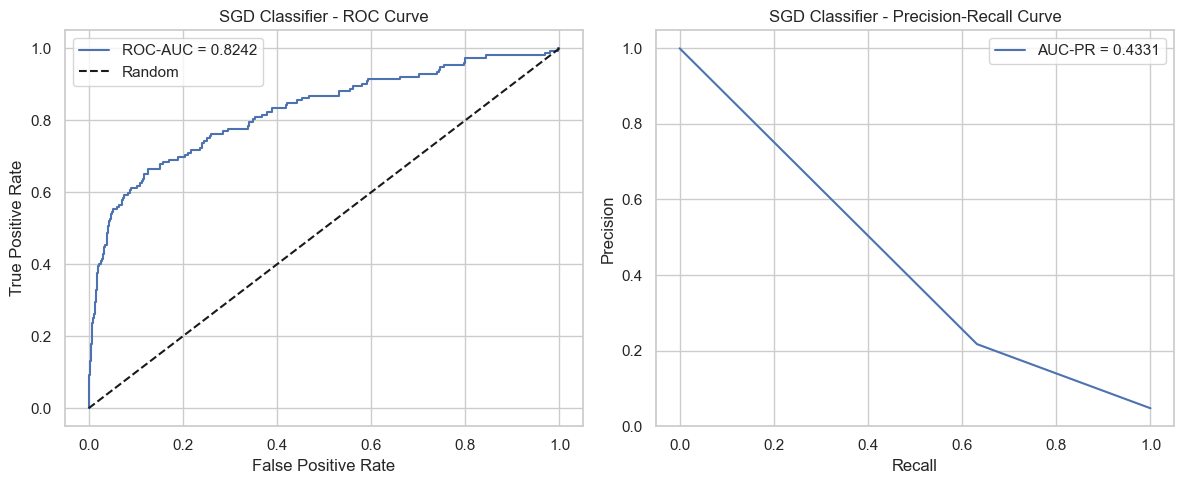

In [77]:
# ROC-AUC, AUC-PR and MCC for SGD
precision_SGD, recall_SGD, _ = precision_recall_curve(y_test_rfe, y_pred_SGD)
auc_pr_SGD = auc(recall_SGD, precision_SGD)
print("AUC-PR:", auc_pr_SGD)

decision_scores_SGD = sgd.decision_function(X_test_rfe)
fpr_roc_SGD, tpr_roc_SGD, _ = roc_curve(y_test_rfe, decision_scores_SGD)
roc_auc_SGD = auc(fpr_roc_SGD, tpr_roc_SGD)
print(f"ROC-AUC: {roc_auc_SGD:.4f}")

mcc_SGD = matthews_corrcoef(y_test_rfe, y_pred_SGD)
print(f"Matthews Correlation Coefficient (MCC): {mcc_SGD:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_SGD, tpr_roc_SGD, label=f'ROC-AUC = {roc_auc_SGD:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('SGD Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_SGD, precision_SGD, label=f'AUC-PR = {auc_pr_SGD:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('SGD Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 11. Extra Tree Classifier

In [78]:
# Initialize and train model
et = ExtraTreeClassifier(random_state=42)
et.fit(X_train_rfe_smote, y_train_rfe_smote)

ExtraTreeClassifier(random_state=42)

In [79]:
# Make prediction
y_pred_ET = et.predict(X_test_rfe)

In [80]:
# Evaluating the ET model
accuracy_ET = accuracy_score(y_test_rfe, y_pred_ET)
conf_matrix_ET = confusion_matrix(y_test_rfe, y_pred_ET)
class_report_ET = classification_report(y_test_rfe, y_pred_ET)

TP_ET = conf_matrix_ET[1, 1]
FN_ET = conf_matrix_ET[1, 0]
FP_ET = conf_matrix_ET[0, 1]
TN_ET = conf_matrix_ET[0, 0]

TPR_ET = TP_ET / (TP_ET + FN_ET) if (TP_ET + FN_ET) > 0 else 0
FPR_ET = FP_ET / (FP_ET + TN_ET) if (FP_ET + TN_ET) > 0 else 0
balanced_accuracy_ET = (TPR_ET + (TN_ET / (TN_ET + FP_ET))) / 2 if (TN_ET + FP_ET) > 0 else 0

print("Evaluation Metrics for ET:")
print(f'Accuracy: {accuracy_ET:.4f}')
print(f'True Positive Rate (TPR): {TPR_ET:.4f}')
print(f'False Positive Rate (FPR): {FPR_ET:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_ET:.4f}')
print('\nClassification Report:')
print(class_report_ET)

Evaluation Metrics for ET:
Accuracy: 0.8106
True Positive Rate (TPR): 0.5921
False Positive Rate (FPR): 0.1785
Balanced Accuracy: 0.7068

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.82      0.89      3048
           1       0.14      0.59      0.23       152

    accuracy                           0.81      3200
   macro avg       0.56      0.71      0.56      3200
weighted avg       0.94      0.81      0.86      3200



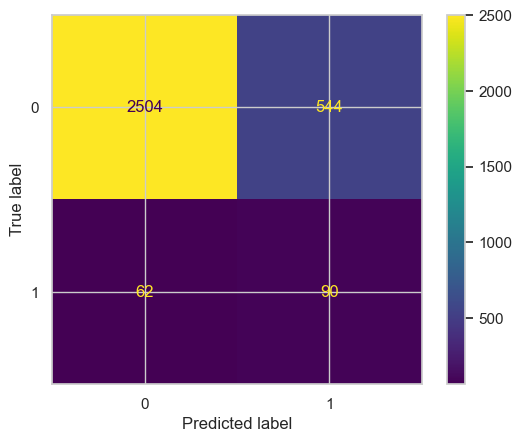

In [81]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_ET, display_labels=et.classes_)
disp.plot()
plt.show()

AUC-PR: 0.37671804956001986
ROC-AUC: 0.8188
Matthews Correlation Coefficient (MCC): 0.2207


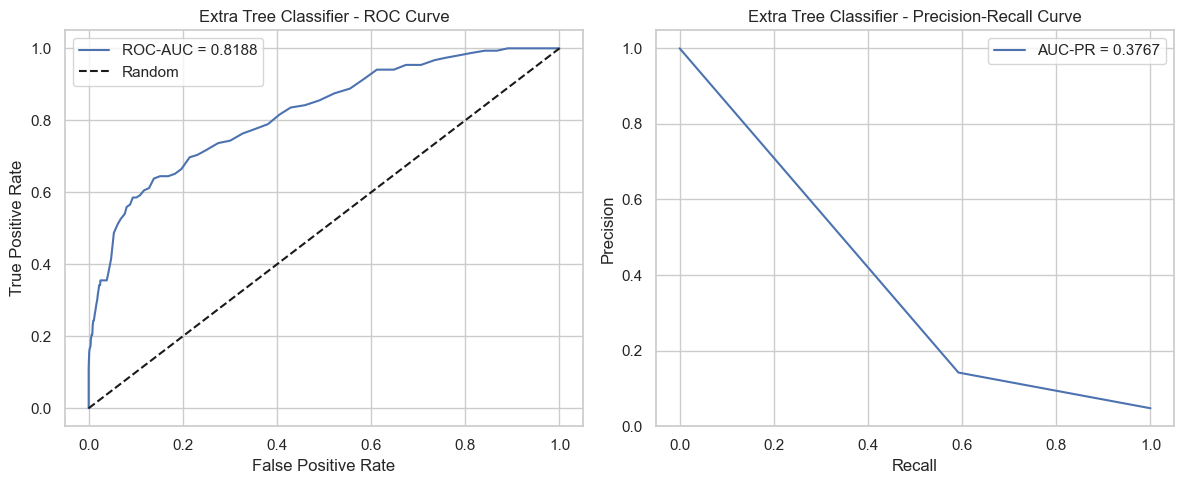

In [82]:
# ROC-AUC, AUC-PR and MCC for ET
precision_ET, recall_ET, _ = precision_recall_curve(y_test_rfe, y_pred_ET)
auc_pr_ET = auc(recall_ET, precision_ET)

y_pred_proba_ET = rf.predict_proba(X_test_rfe)[:, 1]
fpr_roc_ET, tpr_roc_ET, _ = roc_curve(y_test_rfe, y_pred_proba_ET)
roc_auc_ET = auc(fpr_roc_ET, tpr_roc_ET)

mcc_ET = matthews_corrcoef(y_test_rfe, y_pred_ET)

print("AUC-PR:", auc_pr_ET)
print(f"ROC-AUC: {roc_auc_ET:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_ET:.4f}")

# ROC-AUC and AUC-PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_ET, tpr_roc_ET, label=f'ROC-AUC = {roc_auc_ET:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Extra Tree Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_ET, precision_ET, label=f'AUC-PR = {auc_pr_ET:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Extra Tree Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 12. Extra Trees Classifier

In [83]:
# Initialize and train Model
ets = ExtraTreesClassifier(random_state=42)
ets.fit(X_train_rfe_smote, y_train_rfe_smote)

ExtraTreesClassifier(random_state=42)

In [84]:
# Make predictions
y_pred_ETS = ets.predict(X_test_rfe)

In [85]:
# Evaluating the ETS model
accuracy_ETS = accuracy_score(y_test_rfe, y_pred_ETS)
conf_matrix_ETS = confusion_matrix(y_test_rfe, y_pred_ETS)
class_report_ETS = classification_report(y_test_rfe, y_pred_ETS)

TP_ETS = conf_matrix_ETS[1, 1]
FN_ETS = conf_matrix_ETS[1, 0]
FP_ETS = conf_matrix_ETS[0, 1]
TN_ETS = conf_matrix_ETS[0, 0]

TPR_ETS = TP_ETS / (TP_ETS + FN_ETS) if (TP_ETS + FN_ETS) > 0 else 0
FPR_ETS = FP_ETS / (FP_ETS + TN_ETS) if (FP_ETS + TN_ETS) > 0 else 0
balanced_accuracy_ETS = (TPR_ETS + (TN_ETS / (TN_ETS + FP_ETS))) / 2 if (TN_ETS + FP_ETS) > 0 else 0

print("Evaluation Metrics for ETS:")
print(f'Accuracy: {accuracy_ETS:.4f}')
print(f'True Positive Rate (TPR): {TPR_ETS:.4f}')
print(f'False Positive Rate (FPR): {FPR_ETS:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_ETS:.4f}')
print('\nClassification Report:')
print(class_report_ETS)

Evaluation Metrics for ETS:
Accuracy: 0.9494
True Positive Rate (TPR): 0.4934
False Positive Rate (FPR): 0.0279
Balanced Accuracy: 0.7328

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3048
           1       0.47      0.49      0.48       152

    accuracy                           0.95      3200
   macro avg       0.72      0.73      0.73      3200
weighted avg       0.95      0.95      0.95      3200



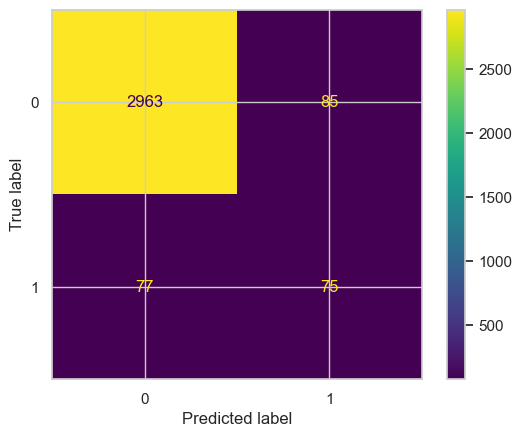

In [86]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_ETS, display_labels=et.classes_)
disp.plot()
plt.show()

AUC-PR: 0.49311677631578943
ROC-AUC: 0.8188
Matthews Correlation Coefficient (MCC): 0.4543


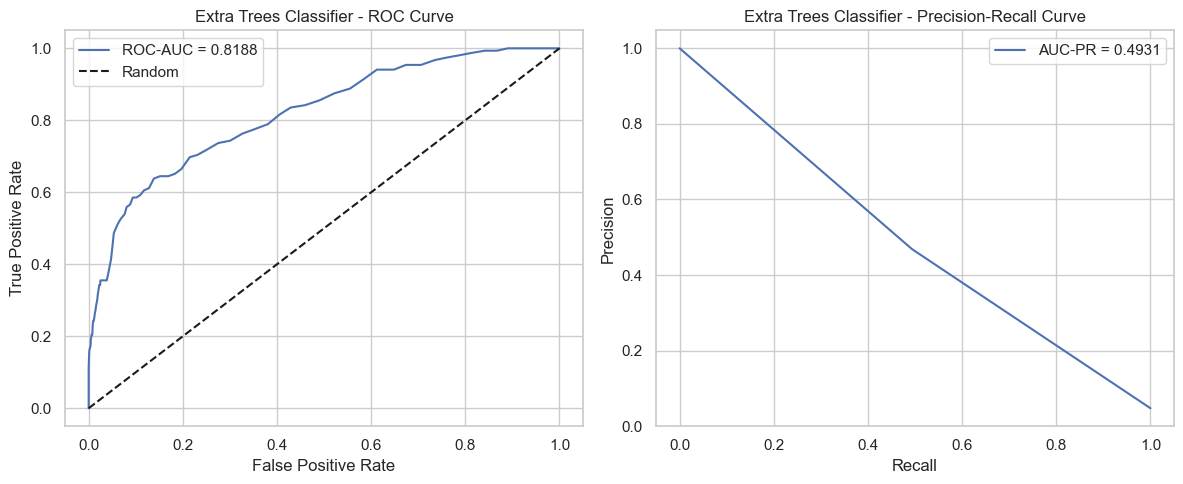

In [87]:
# ROC-AUC, AUC-PR and MCC for ETS
precision_ETS, recall_ETS, _ = precision_recall_curve(y_test_rfe, y_pred_ETS)
auc_pr_ETS = auc(recall_ETS, precision_ETS)

y_pred_proba_ETS = rf.predict_proba(X_test_rfe)[:, 1]
fpr_roc_ETS, tpr_roc_ETS, _ = roc_curve(y_test_rfe, y_pred_proba_ETS)
roc_auc_ETS = auc(fpr_roc_ETS, tpr_roc_ETS)

mcc_ETS = matthews_corrcoef(y_test_rfe, y_pred_ETS)

print("AUC-PR:", auc_pr_ETS)
print(f"ROC-AUC: {roc_auc_ETS:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_ETS:.4f}")

# ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_ETS, tpr_roc_ETS, label=f'ROC-AUC = {roc_auc_ETS:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Extra Trees Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_ETS, precision_ETS, label=f'AUC-PR = {auc_pr_ETS:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Extra Trees Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 13. KNeighbors Classifier

In [88]:
# Initialize and train model
knn = KNeighborsClassifier()
knn.fit(X_train_rfe_smote, y_train_rfe_smote)

KNeighborsClassifier()

In [89]:
# Make predictions
y_pred_KNN = knn.predict(X_test_rfe)

In [90]:
# Evaluating the KNN model
accuracy_KNN = accuracy_score(y_test_rfe, y_pred_KNN)
conf_matrix_KNN = confusion_matrix(y_test_rfe, y_pred_KNN)
class_report_KNN = classification_report(y_test_rfe, y_pred_KNN)

TP_KNN = conf_matrix_KNN[1, 1]
FN_KNN = conf_matrix_KNN[1, 0]
FP_KNN = conf_matrix_KNN[0, 1]
TN_KNN = conf_matrix_KNN[0, 0]

TPR_KNN = TP_KNN / (TP_KNN + FN_KNN) if (TP_KNN + FN_KNN) > 0 else 0
FPR_KNN = FP_KNN / (FP_KNN + TN_KNN) if (FP_KNN + TN_KNN) > 0 else 0
balanced_accuracy_KNN = (TPR_KNN + (TN_KNN / (TN_KNN + FP_KNN))) / 2 if (TN_KNN + FP_KNN) > 0 else 0

print("Evaluation Metrics for KNN:")
print(f'Accuracy: {accuracy_KNN:.4f}')
print(f'True Positive Rate (TPR): {TPR_KNN:.4f}')
print(f'False Positive Rate (FPR): {FPR_KNN:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_KNN:.4f}')
print('\nClassification Report:')
print(class_report_KNN)

Evaluation Metrics for KNN:
Accuracy: 0.8609
True Positive Rate (TPR): 0.6974
False Positive Rate (FPR): 0.1309
Balanced Accuracy: 0.7832

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.87      0.92      3048
           1       0.21      0.70      0.32       152

    accuracy                           0.86      3200
   macro avg       0.60      0.78      0.62      3200
weighted avg       0.95      0.86      0.89      3200



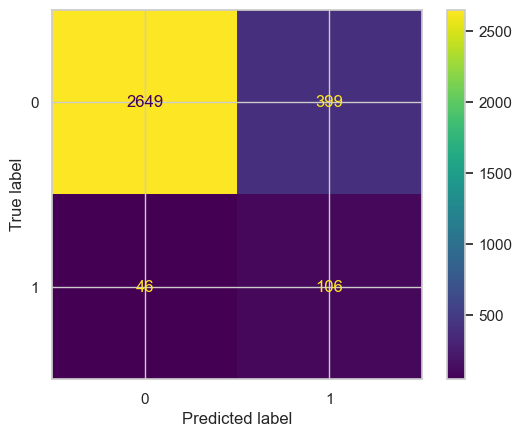

In [91]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_KNN, display_labels=knn.classes_)
disp.plot()
plt.show()

AUC-PR: 0.4608222055758207
ROC-AUC: 0.8188
Matthews Correlation Coefficient (MCC): 0.3305


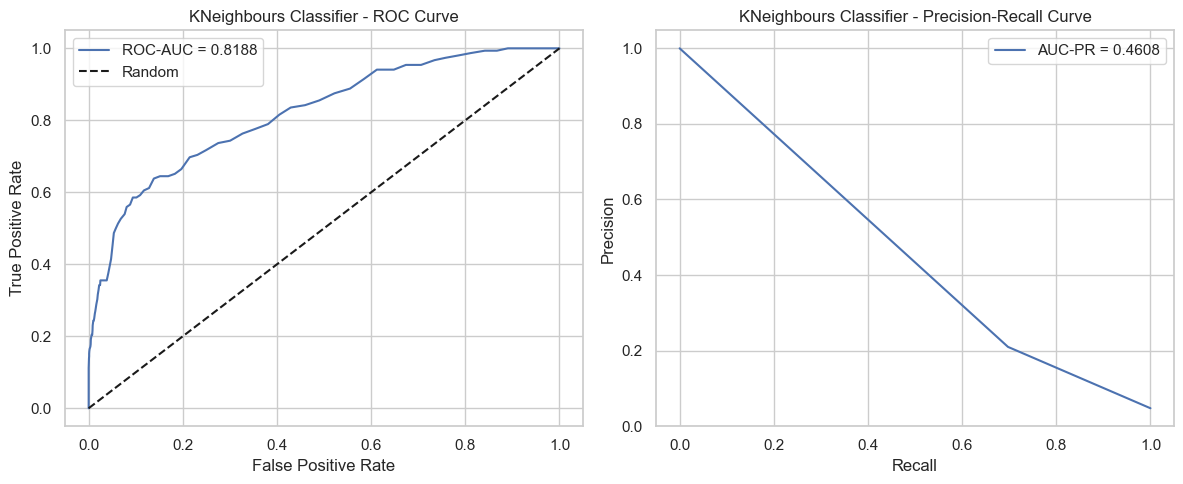

In [92]:
# ROC-AUC, AUC-PR and MCC for KNN
precision_KNN, recall_KNN, _ = precision_recall_curve(y_test_rfe, y_pred_KNN)
auc_pr_KNN = auc(recall_KNN, precision_KNN)

y_pred_proba_KNN = rf.predict_proba(X_test_rfe)[:, 1]
fpr_roc_KNN, tpr_roc_KNN, _ = roc_curve(y_test_rfe, y_pred_proba_KNN)
roc_auc_KNN = auc(fpr_roc_KNN, tpr_roc_KNN)

mcc_KNN = matthews_corrcoef(y_test_rfe, y_pred_KNN)

print("AUC-PR:", auc_pr_KNN)
print(f"ROC-AUC: {roc_auc_KNN:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_KNN:.4f}")

# ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_KNN, tpr_roc_KNN, label=f'ROC-AUC = {roc_auc_KNN:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('KNeighbours Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_KNN, precision_KNN, label=f'AUC-PR = {auc_pr_KNN:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('KNeighbours Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

# SUMMARY COMPARISON

In [93]:
models_data = [
    ("NC",    1, accuracy_NC,    balanced_accuracy_NC, roc_auc_NC, auc_pr_NC, mcc_NC, TPR_NC, FPR_NC),
    ("DT",    1, accuracy_DT,    balanced_accuracy_DT, roc_auc_DT, auc_pr_DT, mcc_DT, TPR_DT, FPR_DT),
    ("LDA",   1, accuracy_LDA,   balanced_accuracy_LDA, roc_auc_LDA, auc_pr_LDA, mcc_LDA, TPR_LDA, FPR_LDA),
    ("BAG",   1, accuracy_BAG,   balanced_accuracy_BAG, roc_auc_BAG, auc_pr_BAG, mcc_BAG, TPR_BAG, FPR_BAG),
    ("PRC",   1, accuracy_PRC,   balanced_accuracy_PRC, roc_auc_PRC, auc_pr_PRC, mcc_PRC, TPR_PRC, FPR_PRC),
    ("XGB",   1, accuracy_XGB,   balanced_accuracy_XGB, roc_auc_XGB, auc_pr_XGB, mcc_XGB, TPR_XGB, FPR_XGB),
    ("LGBM",  1, accuracy_LGBM,  balanced_accuracy_LGBM, roc_auc_LGBM, auc_pr_LGBM, mcc_LGBM, TPR_LGBM, FPR_LGBM),
    ("BNB",   1, accuracy_BNB,   balanced_accuracy_BNB, roc_auc_BNB, auc_pr_BNB, mcc_BNB, TPR_BNB, FPR_BNB),
    ("RF",    1, accuracy_RF,    balanced_accuracy_RF, roc_auc_RF, auc_pr_RF, mcc_RF, TPR_RF, FPR_RF),
    ("SGD",   1, accuracy_SGD,   balanced_accuracy_SGD, roc_auc_SGD, auc_pr_SGD, mcc_SGD, TPR_SGD, FPR_SGD),
    ("ET",    1, accuracy_ET,    balanced_accuracy_ET, roc_auc_ET, auc_pr_ET, mcc_ET, TPR_ET, FPR_ET),
    ("ETS",   1, accuracy_ETS,   balanced_accuracy_ETS, roc_auc_ETS, auc_pr_ETS, mcc_ETS, TPR_ETS, FPR_ETS),
    ("KNN",   1, accuracy_KNN,   balanced_accuracy_KNN, roc_auc_KNN, auc_pr_KNN, mcc_KNN, TPR_KNN, FPR_KNN),
]

In [94]:
# SUMMARY COMPARISON
print("BASE MODEL PERFORMANCE COMPARISON WITH TPR AND FPR\n")

print(f"{'Model':<10} {'N_Models':<10} {'Accuracy':<10} {'Bal_Acc':<10} {'ROC-AUC':<10} {'AUC-PR':<10} {'MCC':<8} {'TPR':<10} {'FPR':<10}")

for model_name, n_models, acc, bal_acc, roc_auc_val, auc_pr_score, mcc_val, tpr_val, fpr_val in models_data:
    print(f"{model_name:<10} {n_models:<10} {acc:<10.4f} {bal_acc:<10.4f} {roc_auc_val:<10.4f} {auc_pr_score:<10.4f} {mcc_val:<8.4f} {tpr_val:<10.4f} {fpr_val:<10.4f}")

# Find best performing model by accuracy
best_accuracy = max(models_data, key=lambda x: x[2])

print("\nBEST PERFORMING BASE MODEL:")
print(f"Best Accuracy:          {best_accuracy[0]} - {best_accuracy[2]:.4f}")
print(f"Balanced Accuracy:      {best_accuracy[3]:.4f}")
print(f"ROC-AUC:                {best_accuracy[4]:.4f}")
print(f"AUC-PR:                 {best_accuracy[5]:.4f}")
print(f"MCC:                    {best_accuracy[6]:.4f}")
print(f"TPR:                    {best_accuracy[7]:.4f}")
print(f"FPR:                    {best_accuracy[8]:.4f}")

BASE MODEL PERFORMANCE COMPARISON WITH TPR AND FPR

Model      N_Models   Accuracy   Bal_Acc    ROC-AUC    AUC-PR     MCC      TPR        FPR       
NC         1          0.8994     0.7378     0.7550     0.4151     0.3282   0.5592     0.0837    
DT         1          0.7063     0.6520     0.6520     0.3522     0.1408   0.5921     0.2881    
LDA        1          0.8731     0.7521     0.8195     0.4246     0.3109   0.6184     0.1142    
BAG        1          0.7438     0.6467     0.7209     0.3300     0.1423   0.5395     0.2461    
PRC        1          0.4978     0.6114     0.7141     0.4080     0.0949   0.7368     0.5141    
XGB        1          0.1478     0.5245     0.6833     0.4968     0.0339   0.9408     0.8917    
LGBM       1          0.1347     0.5364     0.6816     0.5162     0.0544   0.9803     0.9075    
BNB        1          0.7297     0.7143     0.7708     0.4132     0.2011   0.6974     0.2687    
RF         1          0.8838     0.7421     0.8188     0.4144     0.3121   

# Stacking Ensemble Models

In [95]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

In [96]:
# FULL MODEL (for comparison)
base_models = [
    ('nc', NearestCentroid()),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('lda', LinearDiscriminantAnalysis()),
    ('bagging', BaggingClassifier(random_state=42)),
    ('perceptron', Perceptron(random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('bnb', BernoulliNB()),
    ('rf', RandomForestClassifier(random_state=42)),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42)),
    ('etc', ExtraTreeClassifier(random_state=42)),
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('knn', KNeighborsClassifier())
]

In [97]:
# Meta-learner
meta_learner = LogisticRegression()

In [98]:
# Stacking Classifier
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_learner, cv=5)

In [99]:
# Train model
stacking_model.fit(X_train_rfe_smote, y_train_rfe_smote)

[LightGBM] [Info] Number of positive: 12159, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004851 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4926
[LightGBM] [Info] Number of data points in the train set: 24318, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008139 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4918
[LightGBM] [Info] Number of data points in the train set: 19454, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threadin

StackingClassifier(cv=5,
                   estimators=[('nc', NearestCentroid()),
                               ('dt', DecisionTreeClassifier(random_state=42)),
                               ('lda', LinearDiscriminantAnalysis()),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('perceptron', Perceptron(random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsa...
                                              num_parallel_tree=None,
                                              random_state=42, ...)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('bnb', BernoulliNB()),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42)),
                               ('etc', ExtraTreeClassifier(random_state=42)),
                               ('etcs', ExtraTreesClassifier(random_state=42)),
                               ('knn', KNeighborsClassifier())],
                   final_estimator=LogisticRegression())

In [100]:
# Make predictions
y_pred_stack = stacking_model.predict(X_test_rfe)

In [101]:
# Evaluating the model
accuracy_stack = accuracy_score(y_test_rfe, y_pred_stack)
conf_matrix_stack = confusion_matrix(y_test_rfe, y_pred_stack)
class_report_stack = classification_report(y_test_rfe, y_pred_stack)

TP = conf_matrix_stack[1, 1]
FN = conf_matrix_stack[1, 0]
FP = conf_matrix_stack[0, 1]
TN = conf_matrix_stack[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("FULL MODEL - All Models (13 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_stack:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack)

FULL MODEL - All Models (13 models)
Evaluation Metrics:
Accuracy: 0.9237
True Positive Rate (TPR): 0.5855
False Positive Rate (FPR): 0.0594
Balanced Accuracy: 0.7631

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3048
           1       0.33      0.59      0.42       152

    accuracy                           0.92      3200
   macro avg       0.65      0.76      0.69      3200
weighted avg       0.95      0.92      0.93      3200



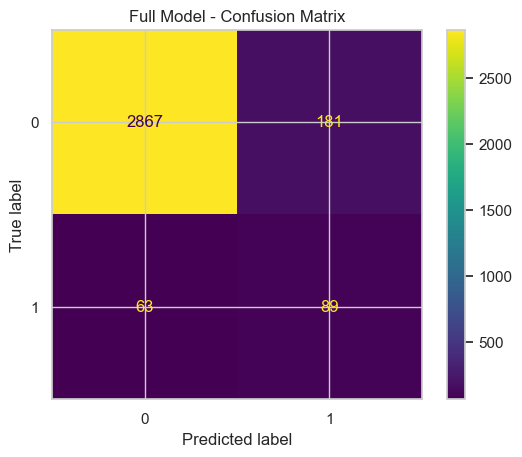

In [102]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack, display_labels=stacking_model.classes_)
disp.plot()
plt.title('Full Model - Confusion Matrix')
plt.show()

ROC-AUC: 0.8616
AUC-PR: 0.4674
Matthews Correlation Coefficient (MCC): 0.4026


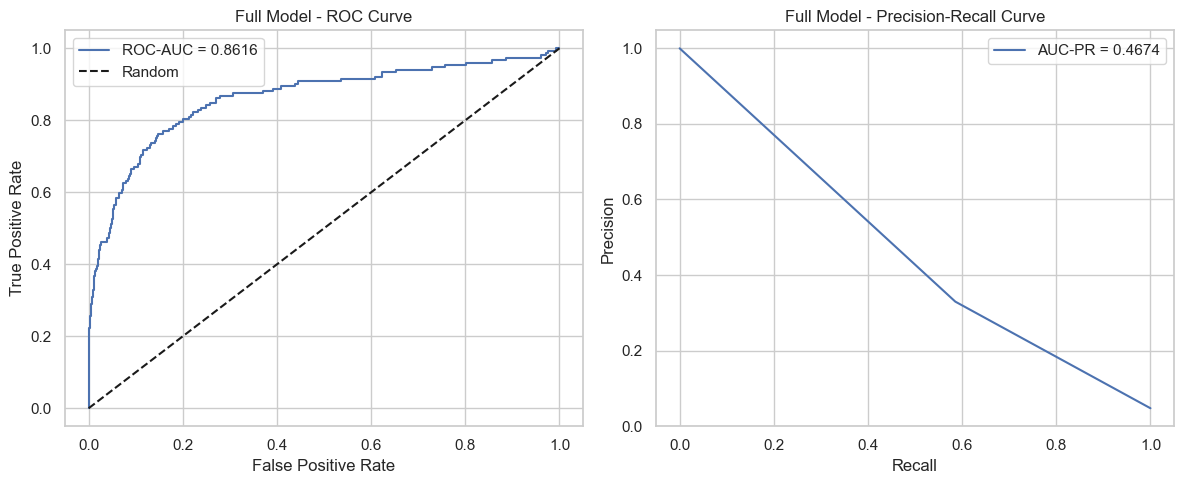

In [103]:
# ROC-AUC, AUC-PR and MCC
y_pred_proba_full = stacking_model.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_full)
roc_auc_full = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack)
auc_pr = auc(recall, precision)

mcc_full = matthews_corrcoef(y_test_rfe, y_pred_stack)

print(f"ROC-AUC: {roc_auc_full:.4f}")
print(f"AUC-PR: {auc_pr:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_full:.4f}")

# ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_full:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Full Model - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Full Model - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# SHAP - Stacking Ensemble

In [104]:
import shap

In [105]:
# Meta-learner
meta_learner = stacking_model.final_estimator_

In [106]:
# Transformed features
X_test_meta = stacking_model.transform(X_test_rfe)

In [107]:
# Feature Names
base_model_names = [name for name, _ in base_models]
feature_names = []

for model_name in base_model_names:
    feature_names.append(f"{model_name}_prediction")

In [108]:
# DataFrame
X_test_meta_df = pd.DataFrame(X_test_meta, columns=feature_names)

In [109]:
# SHAP explainer
explainer = shap.Explainer(meta_learner, X_test_meta_df)
shap_values = explainer(X_test_meta_df)

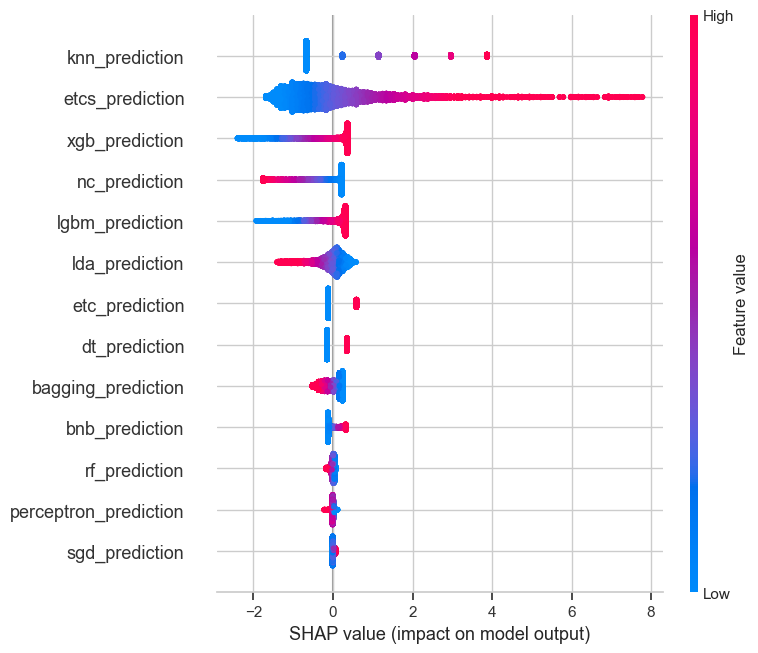

In [110]:
# Subsample
sample_indices = np.random.choice(len(X_test_meta_df), size=16000, replace=True)
shap_values_sampled = shap_values[sample_indices]
X_test_meta_sampled = X_test_meta_df.iloc[sample_indices]

shap.summary_plot(shap_values_sampled, X_test_meta_sampled)

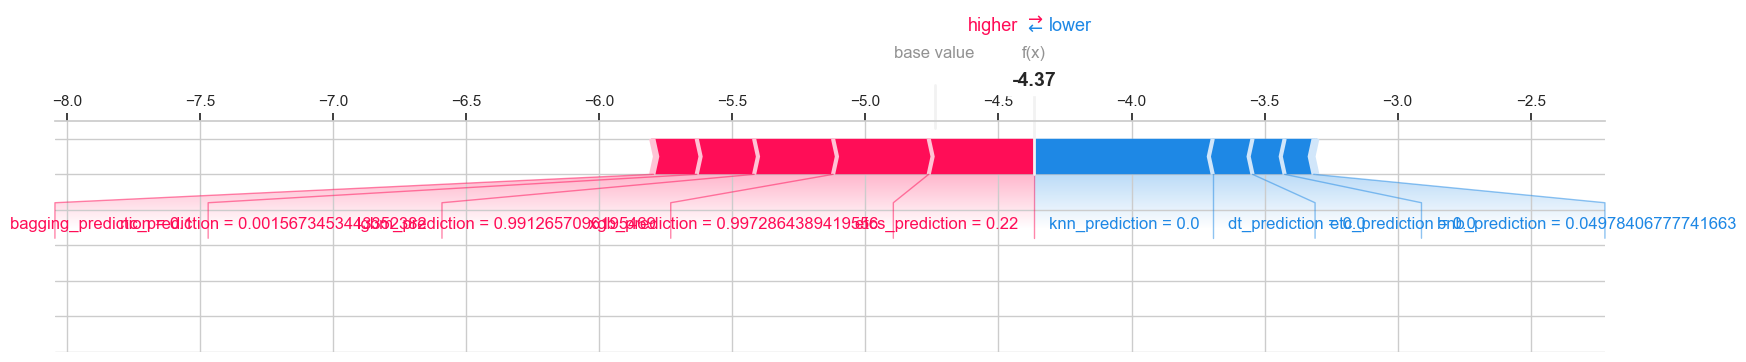

In [111]:
# Force Plot
idx = np.random.randint(len(X_test_meta_sampled))
shap.force_plot(explainer.expected_value, shap_values_sampled[idx].values, X_test_meta_sampled.iloc[idx], matplotlib=True)

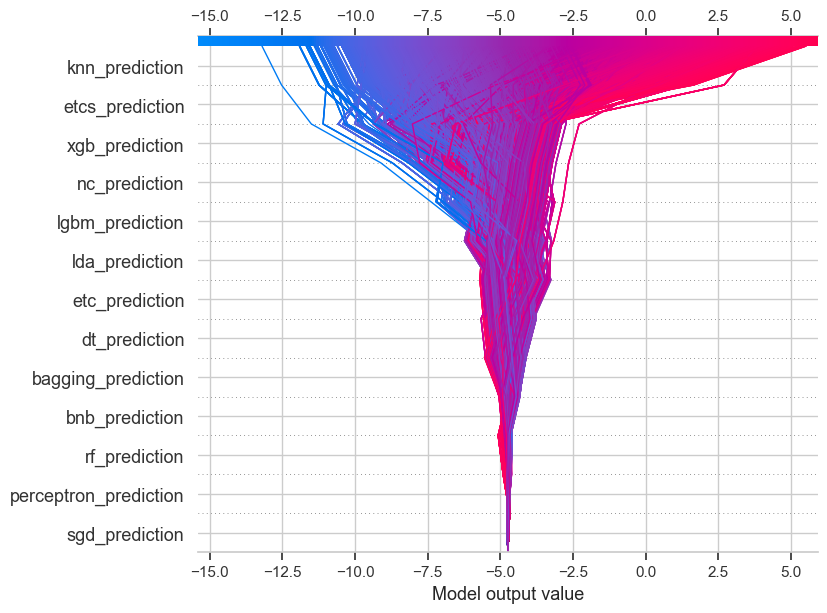

In [112]:
# Decision Plot
shap.decision_plot(explainer.expected_value, shap_values_sampled.values, X_test_meta_sampled, ignore_warnings=True)
plt.show()

# SHAP - Base Models

## Extra Trees Classifier

## Random Forest

## Bagging Classifier

# Reduced Stacking Ensembles

## 1. Reduced 1 - ETCS, RF, BAGGING, LGBM

In [113]:
# REDUCED MODEL 1: Core performers (SHAP > 0.5) - etcs, rf, bagging, lgbm
reduced1_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
]

In [114]:
# Meta-learner
meta_learner = LogisticRegression()

In [115]:
# Stacking Classifier
stacking_model_reduced1 = StackingClassifier(estimators=reduced1_models, final_estimator=meta_learner, cv=5)

In [116]:
# Train model
stacking_model_reduced1.fit(X_train_rfe_smote, y_train_rfe_smote)

[LightGBM] [Info] Number of positive: 12159, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003908 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4926
[LightGBM] [Info] Number of data points in the train set: 24318, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003243 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4918
[LightGBM] [Info] Number of data points in the train set: 19454, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threadin

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [117]:
# Make predictions
y_pred_stack_reduced1 = stacking_model_reduced1.predict(X_test_rfe)

In [118]:
# Evaluating Reduced Model 1
accuracy_reduced1 = accuracy_score(y_test_rfe, y_pred_stack_reduced1)
conf_matrix_reduced1 = confusion_matrix(y_test_rfe, y_pred_stack_reduced1)
class_report_reduced1 = classification_report(y_test_rfe, y_pred_stack_reduced1)

TP = conf_matrix_reduced1[1, 1]
FN = conf_matrix_reduced1[1, 0]
FP = conf_matrix_reduced1[0, 1]
TN = conf_matrix_reduced1[0, 0]

TPR_reduced1 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced1 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced1 = (TPR_reduced1 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 1 - Core Performers (4 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced1:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced1:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced1:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced1:.4f}')
print('\nClassification Report:')
print(class_report_reduced1)

REDUCED MODEL 1 - Core Performers (4 models)
Evaluation Metrics:
Accuracy: 0.9113
True Positive Rate (TPR): 0.6711
False Positive Rate (FPR): 0.0768
Balanced Accuracy: 0.7971

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95      3048
           1       0.30      0.67      0.42       152

    accuracy                           0.91      3200
   macro avg       0.64      0.80      0.68      3200
weighted avg       0.95      0.91      0.93      3200



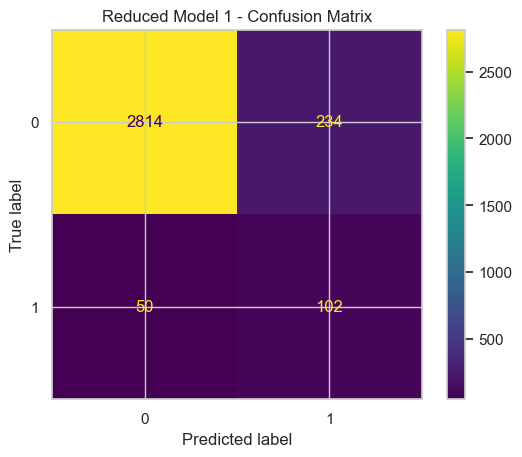

In [119]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced1, display_labels=stacking_model_reduced1.classes_)
disp.plot()
plt.title('Reduced Model 1 - Confusion Matrix')
plt.show()

ROC-AUC: 0.8904
AUC-PR: 0.4951
Matthews Correlation Coefficient (MCC): 0.4123


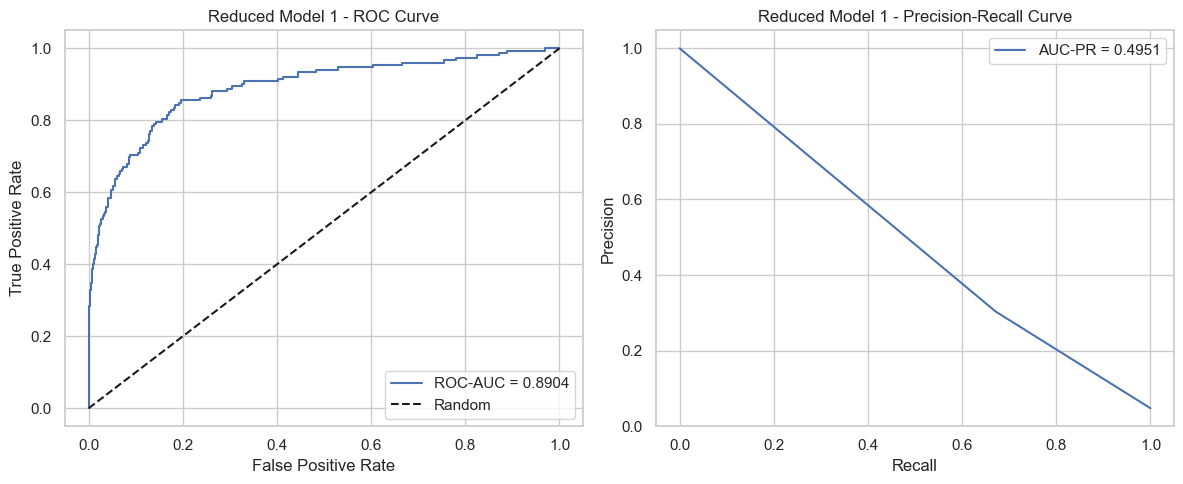

In [120]:
# ROC-AUC and AUC-PR
y_pred_proba_reduced1 = stacking_model_reduced1.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced1)
roc_auc_reduced1 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced1)
auc_pr_reduced1 = auc(recall, precision)

mcc_reduced1 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced1)

print(f"ROC-AUC: {roc_auc_reduced1:.4f}")
print(f"AUC-PR: {auc_pr_reduced1:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced1:.4f}")

# ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced1:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 1 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced1:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 1 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 2. Reduced 2 - 

In [121]:
# REDUCED MODEL 2: Core + next best (nc)
reduced2_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid())
]

In [122]:
# Meta-learner
meta_learner = LogisticRegression()

In [123]:
# Stacking Classifier
stacking_model_reduced2 = StackingClassifier(estimators=reduced2_models, final_estimator=meta_learner, cv=5)

In [124]:
# Train model
stacking_model_reduced2.fit(X_train_rfe_smote, y_train_rfe_smote)

[LightGBM] [Info] Number of positive: 12159, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004530 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4926
[LightGBM] [Info] Number of data points in the train set: 24318, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003754 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4918
[LightGBM] [Info] Number of data points in the train set: 19454, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threadin

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [125]:
# Make predictions
y_pred_stack_reduced2 = stacking_model_reduced2.predict(X_test_rfe)

In [126]:
# Evaluating Reduced Model 2
accuracy_reduced2 = accuracy_score(y_test_rfe, y_pred_stack_reduced2)
conf_matrix_reduced2 = confusion_matrix(y_test_rfe, y_pred_stack_reduced2)
class_report_reduced2 = classification_report(y_test_rfe, y_pred_stack_reduced2)

TP = conf_matrix_reduced2[1, 1]
FN = conf_matrix_reduced2[1, 0]
FP = conf_matrix_reduced2[0, 1]
TN = conf_matrix_reduced2[0, 0]

TPR_reduced2 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced2 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced2 = (TPR_reduced2 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 2 - Core + NC (5 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced2:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced2:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced2:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced2:.4f}')
print('\nClassification Report:')
print(class_report_reduced2)

REDUCED MODEL 2 - Core + NC (5 models)
Evaluation Metrics:
Accuracy: 0.8869
True Positive Rate (TPR): 0.6447
False Positive Rate (FPR): 0.1010
Balanced Accuracy: 0.7718

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      3048
           1       0.24      0.64      0.35       152

    accuracy                           0.89      3200
   macro avg       0.61      0.77      0.64      3200
weighted avg       0.95      0.89      0.91      3200



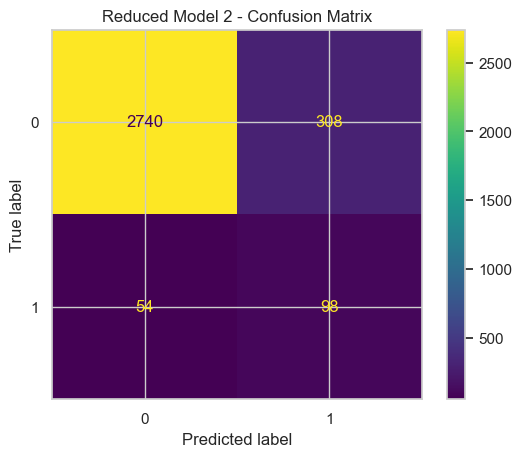

In [127]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced2, display_labels=stacking_model_reduced2.classes_)
disp.plot()
plt.title('Reduced Model 2 - Confusion Matrix')
plt.show()

ROC-AUC: 0.8465
AUC-PR: 0.4515
Matthews Correlation Coefficient (MCC): 0.3475


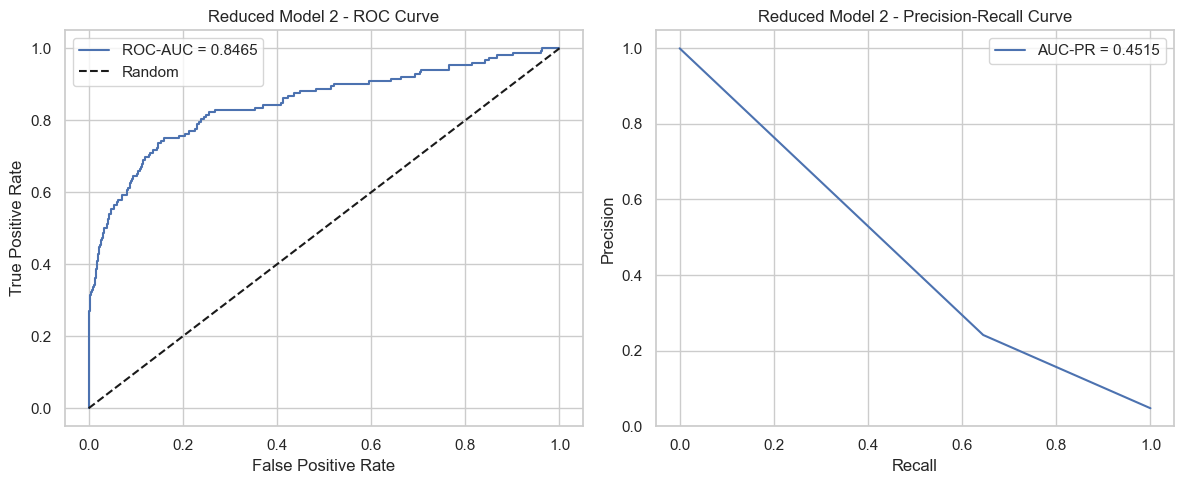

In [128]:
# ROC-AUC, AUC-PR and MCC
y_pred_proba_reduced2 = stacking_model_reduced2.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced2)
roc_auc_reduced2 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced2)
auc_pr_reduced2 = auc(recall, precision)

mcc_reduced2 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced2)

print(f"ROC-AUC: {roc_auc_reduced2:.4f}")
print(f"AUC-PR: {auc_pr_reduced2:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced2:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced2:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 2 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced2:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 2 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 3. Reduced 3

In [129]:
# REDUCED MODEL 3: Core + next 2 best (nc, knn)
reduced3_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid()),
    ('knn', KNeighborsClassifier())
]

In [130]:
# Meta-learner
meta_learner = LogisticRegression()

In [131]:
# Stacking Classifier
stacking_model_reduced3 = StackingClassifier(estimators=reduced3_models, final_estimator=meta_learner, cv=5)

In [132]:
# Train model
stacking_model_reduced3.fit(X_train_rfe_smote, y_train_rfe_smote)

[LightGBM] [Info] Number of positive: 12159, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003984 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4926
[LightGBM] [Info] Number of data points in the train set: 24318, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001545 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4918
[LightGBM] [Info] Number of data points in the train set: 19454, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threadin

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid()),
                               ('knn', KNeighborsClassifier())],
                   final_estimator=LogisticRegression())

In [133]:
# Make predictions
y_pred_stack_reduced3 = stacking_model_reduced3.predict(X_test_rfe)

In [134]:
# Evaluating the model
accuracy_stack_reduced3 = accuracy_score(y_test_rfe, y_pred_stack_reduced3)
conf_matrix_stack_reduced3 = confusion_matrix(y_test_rfe, y_pred_stack_reduced3)
class_report_stack_reduced3 = classification_report(y_test_rfe, y_pred_stack_reduced3)

TP = conf_matrix_stack_reduced3[1, 1]
FN = conf_matrix_stack_reduced3[1, 0]
FP = conf_matrix_stack_reduced3[0, 1]
TN = conf_matrix_stack_reduced3[0, 0]

TPR_reduced3 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced3 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced3 = (TPR_reduced3 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 3 - Core + NC + KNN (6 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_stack_reduced3:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced3:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced3:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced3:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced3)

REDUCED MODEL 3 - Core + NC + KNN (6 models)
Evaluation Metrics:
Accuracy: 0.9206
True Positive Rate (TPR): 0.5855
False Positive Rate (FPR): 0.0627
Balanced Accuracy: 0.7614

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3048
           1       0.32      0.59      0.41       152

    accuracy                           0.92      3200
   macro avg       0.65      0.76      0.68      3200
weighted avg       0.95      0.92      0.93      3200



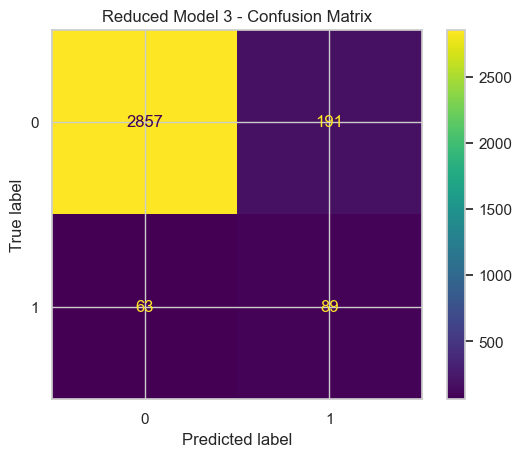

In [135]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced3, display_labels=stacking_model_reduced3.classes_)
disp.plot()
plt.title('Reduced Model 3 - Confusion Matrix')
plt.show()

ROC-AUC: 0.8661
AUC-PR: 0.4615
Matthews Correlation Coefficient (MCC): 0.3936


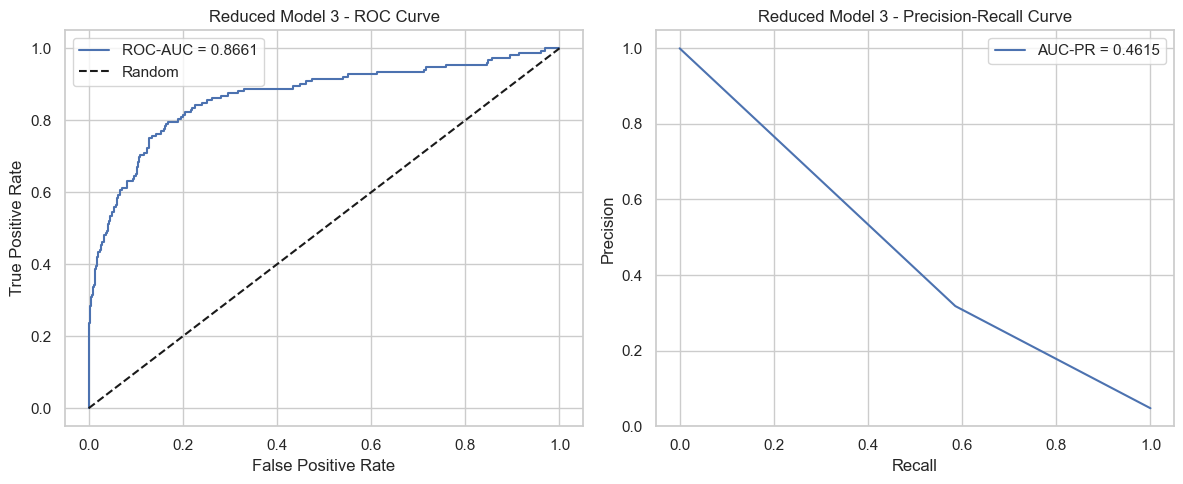

In [136]:
# ROC-AUC, AUC-PR and MCC
y_pred_proba_reduced3 = stacking_model_reduced3.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced3)
roc_auc_reduced3 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced3)
auc_pr_reduced3 = auc(recall, precision)

mcc_reduced3 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced3)

print(f"ROC-AUC: {roc_auc_reduced3:.4f}")
print(f"AUC-PR: {auc_pr_reduced3:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced3:.4f}")

# ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced3:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 3 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced3:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 3 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 4. Reduced 4

In [137]:
# REDUCED MODEL 4: Core + next 3 best (nc, knn, sgd)
reduced4_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid()),
    ('knn', KNeighborsClassifier()),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42))
]

In [138]:
# Meta-learner
meta_learner = LogisticRegression()

In [139]:
# Stacking Classifier
stacking_model_reduced4 = StackingClassifier(estimators=reduced4_models, final_estimator=meta_learner, cv=5)

In [140]:
# Train model
stacking_model_reduced4.fit(X_train_rfe_smote, y_train_rfe_smote)

[LightGBM] [Info] Number of positive: 12159, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001976 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4926
[LightGBM] [Info] Number of data points in the train set: 24318, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001985 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4918
[LightGBM] [Info] Number of data points in the train set: 19454, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threadin

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid()),
                               ('knn', KNeighborsClassifier()),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42))],
                   final_estimator=LogisticRegression())

In [141]:
# Make predictions
y_pred_stack_reduced4 = stacking_model_reduced4.predict(X_test_rfe)

In [142]:
# Evaluating Reduced Model 4
accuracy_reduced4 = accuracy_score(y_test_rfe, y_pred_stack_reduced4)
conf_matrix_reduced4 = confusion_matrix(y_test_rfe, y_pred_stack_reduced4)
class_report_reduced4 = classification_report(y_test_rfe, y_pred_stack_reduced4)

TP = conf_matrix_reduced4[1, 1]
FN = conf_matrix_reduced4[1, 0]
FP = conf_matrix_reduced4[0, 1]
TN = conf_matrix_reduced4[0, 0]

TPR_reduced4 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced4 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced4 = (TPR_reduced4 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 4 - Core + NC + KNN + SGD (7 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced4:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced4:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced4:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced4:.4f}')
print('\nClassification Report:')
print(class_report_reduced4)

REDUCED MODEL 4 - Core + NC + KNN + SGD (7 models)
Evaluation Metrics:
Accuracy: 0.9250
True Positive Rate (TPR): 0.5724
False Positive Rate (FPR): 0.0574
Balanced Accuracy: 0.7575

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3048
           1       0.33      0.57      0.42       152

    accuracy                           0.93      3200
   macro avg       0.65      0.76      0.69      3200
weighted avg       0.95      0.93      0.93      3200



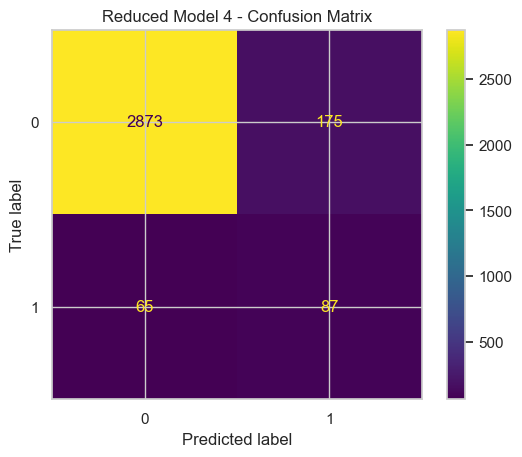

In [143]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced4, display_labels=stacking_model_reduced4.classes_)
disp.plot()
plt.title('Reduced Model 4 - Confusion Matrix')
plt.show()

In [144]:
# ROC-AUC and AUC-PR
y_pred_proba_reduced4 = stacking_model_reduced4.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced4)
roc_auc_reduced4 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced4)
auc_pr_reduced4 = auc(recall, precision)

ROC-AUC: 0.8634
AUC-PR: 0.4624
Matthews Correlation Coefficient (MCC): 0.3995


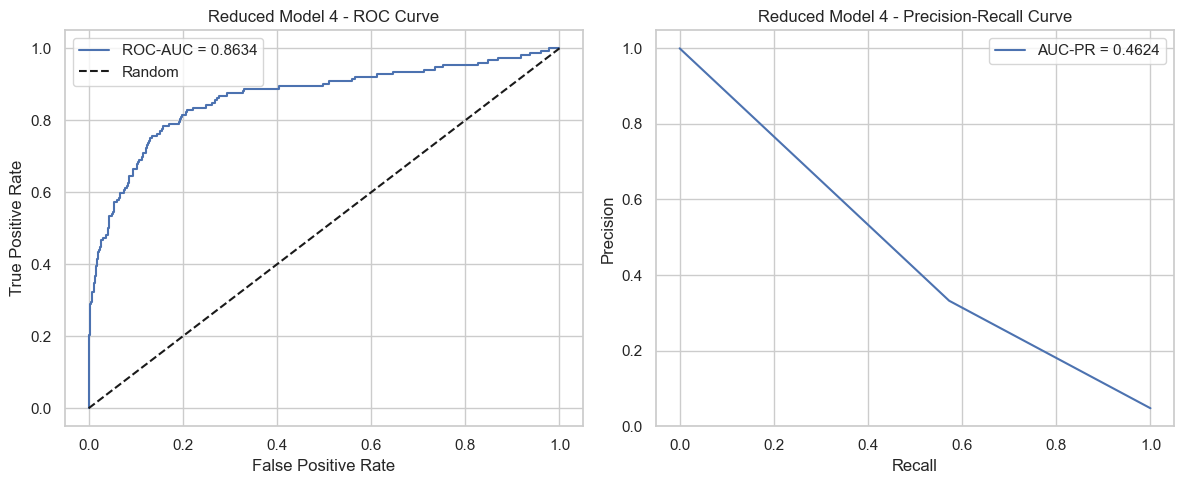

In [145]:
# ROC-AUC and AUC-PR and MCC
y_pred_proba_reduced4 = stacking_model_reduced4.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced4)
roc_auc_reduced4 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced4)
auc_pr_reduced4 = auc(recall, precision)

mcc_reduced4 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced4)

print(f"ROC-AUC: {roc_auc_reduced4:.4f}")
print(f"AUC-PR: {auc_pr_reduced4:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced4:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced4:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 4 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced4:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 4 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Reduced 5

In [146]:
# REDUCED MODEL 5: Core + next 4 best (nc, knn, sgd, etc)
reduced5_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid()),
    ('knn', KNeighborsClassifier()),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42)),
    ('etc', ExtraTreeClassifier(random_state=42))
]

In [147]:
# Meta-learner
meta_learner = LogisticRegression()

In [148]:
# Stacking Classifier
stacking_model_reduced5 = StackingClassifier(estimators=reduced5_models, final_estimator=meta_learner, cv=5)

In [149]:
# Train model
stacking_model_reduced5.fit(X_train_rfe_smote, y_train_rfe_smote)

[LightGBM] [Info] Number of positive: 12159, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002511 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4926
[LightGBM] [Info] Number of data points in the train set: 24318, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001594 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4918
[LightGBM] [Info] Number of data points in the train set: 19454, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threadin

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid()),
                               ('knn', KNeighborsClassifier()),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42)),
                               ('etc', ExtraTreeClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [150]:
# Make predictions
y_pred_stack_reduced5 = stacking_model_reduced5.predict(X_test_rfe)

In [151]:
# Evaluating Reduced Model 5
accuracy_reduced5 = accuracy_score(y_test_rfe, y_pred_stack_reduced5)
conf_matrix_reduced5 = confusion_matrix(y_test_rfe, y_pred_stack_reduced5)
class_report_reduced5 = classification_report(y_test_rfe, y_pred_stack_reduced5)

TP = conf_matrix_reduced5[1, 1]
FN = conf_matrix_reduced5[1, 0]
FP = conf_matrix_reduced5[0, 1]
TN = conf_matrix_reduced5[0, 0]

TPR_reduced5 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced5 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced5 = (TPR_reduced5 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 5 - Core + NC + KNN + SGD + ETC (8 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced5:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced5:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced5:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced5:.4f}')
print('\nClassification Report:')
print(class_report_reduced5)

REDUCED MODEL 5 - Core + NC + KNN + SGD + ETC (8 models)
Evaluation Metrics:
Accuracy: 0.9263
True Positive Rate (TPR): 0.5658
False Positive Rate (FPR): 0.0558
Balanced Accuracy: 0.7550

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3048
           1       0.34      0.57      0.42       152

    accuracy                           0.93      3200
   macro avg       0.66      0.76      0.69      3200
weighted avg       0.95      0.93      0.94      3200



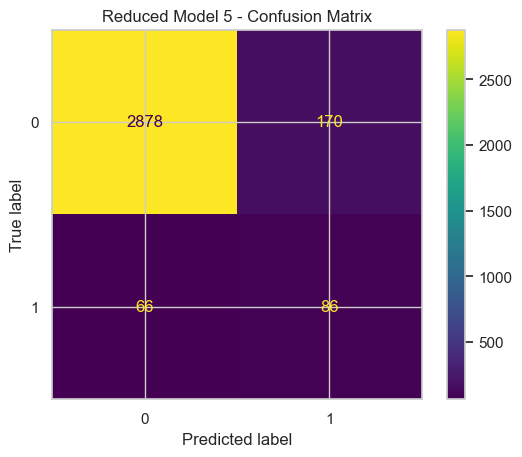

In [153]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced5, display_labels=stacking_model_reduced5.classes_)
disp.plot()
plt.title('Reduced Model 5 - Confusion Matrix')
plt.show()

ROC-AUC: 0.8619
AUC-PR: 0.4612
Matthews Correlation Coefficient (MCC): 0.3999


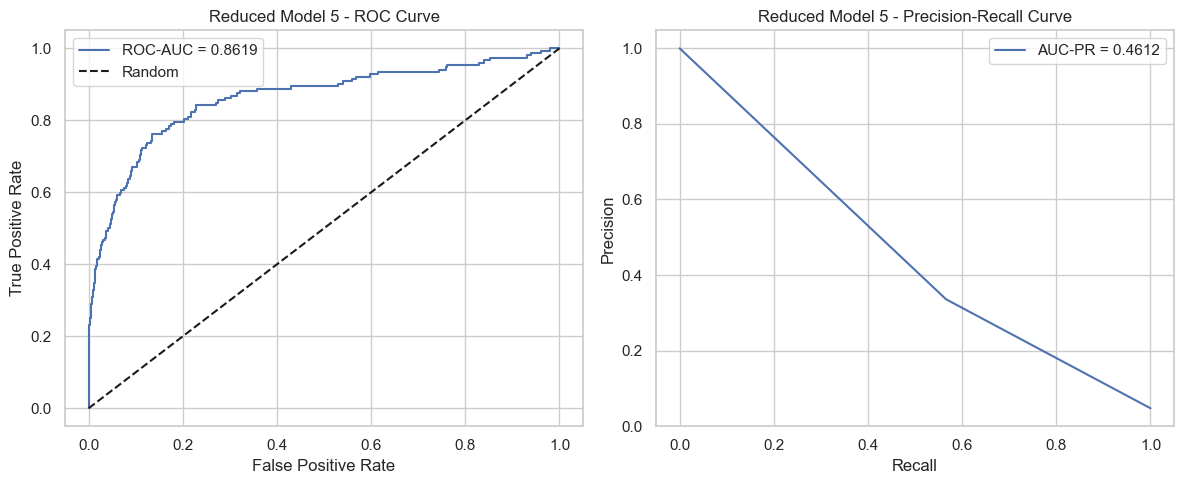

In [154]:
# ROC-AUC and AUC-PR
y_pred_proba_reduced5 = stacking_model_reduced5.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced5)
roc_auc_reduced5 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced5)
auc_pr_reduced5 = auc(recall, precision)

mcc_reduced5 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced5)

print(f"ROC-AUC: {roc_auc_reduced5:.4f}")
print(f"AUC-PR: {auc_pr_reduced5:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced5:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced5:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 5 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced5:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 5 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Reduced 6

In [155]:
# REDUCED MODEL 6: Core + next 5 best (nc, knn, sgd, etc, lda)
reduced6_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid()),
    ('knn', KNeighborsClassifier()),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42)),
    ('etc', ExtraTreeClassifier(random_state=42)),
    ('lda', LinearDiscriminantAnalysis())
]

In [156]:
# Meta-learner
meta_learner = LogisticRegression()

In [157]:
# Stacking Classifier
stacking_model_reduced6 = StackingClassifier(estimators=reduced6_models, final_estimator=meta_learner, cv=5)

In [158]:
# Train model
stacking_model_reduced6.fit(X_train_rfe_smote, y_train_rfe_smote)

[LightGBM] [Info] Number of positive: 12159, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007464 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4926
[LightGBM] [Info] Number of data points in the train set: 24318, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024848 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4918
[LightGBM] [Info] Number of data points in the train set: 19454, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negati

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid()),
                               ('knn', KNeighborsClassifier()),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42)),
                               ('etc', ExtraTreeClassifier(random_state=42)),
                               ('lda', LinearDiscriminantAnalysis())],
                   final_estimator=LogisticRegression())

In [159]:
# Make predictions
y_pred_stack_reduced6 = stacking_model_reduced6.predict(X_test_rfe)

In [160]:
# Evaluating Reduced Model 6
accuracy_reduced6 = accuracy_score(y_test_rfe, y_pred_stack_reduced6)
conf_matrix_reduced6 = confusion_matrix(y_test_rfe, y_pred_stack_reduced6)
class_report_reduced6 = classification_report(y_test_rfe, y_pred_stack_reduced6)

TP = conf_matrix_reduced6[1, 1]
FN = conf_matrix_reduced6[1, 0]
FP = conf_matrix_reduced6[0, 1]
TN = conf_matrix_reduced6[0, 0]

TPR_reduced6 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced6 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced6 = (TPR_reduced6 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 6 - Core + NC + KNN + SGD + ETC + LDA (9 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced6:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced6:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced6:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced6:.4f}')
print('\nClassification Report:')
print(class_report_reduced6)

REDUCED MODEL 6 - Core + NC + KNN + SGD + ETC + LDA (9 models)
Evaluation Metrics:
Accuracy: 0.9247
True Positive Rate (TPR): 0.5724
False Positive Rate (FPR): 0.0577
Balanced Accuracy: 0.7573

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3048
           1       0.33      0.57      0.42       152

    accuracy                           0.92      3200
   macro avg       0.65      0.76      0.69      3200
weighted avg       0.95      0.92      0.93      3200



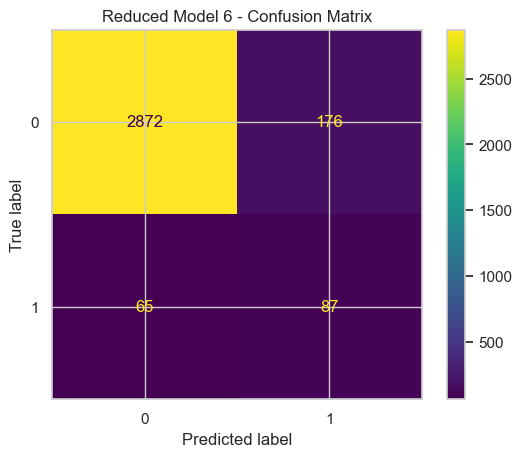

In [161]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced6, display_labels=stacking_model_reduced6.classes_)
disp.plot()
plt.title('Reduced Model 6 - Confusion Matrix')
plt.show()

ROC-AUC: 0.8598
AUC-PR: 0.4617
Matthews Correlation Coefficient (MCC): 0.3986


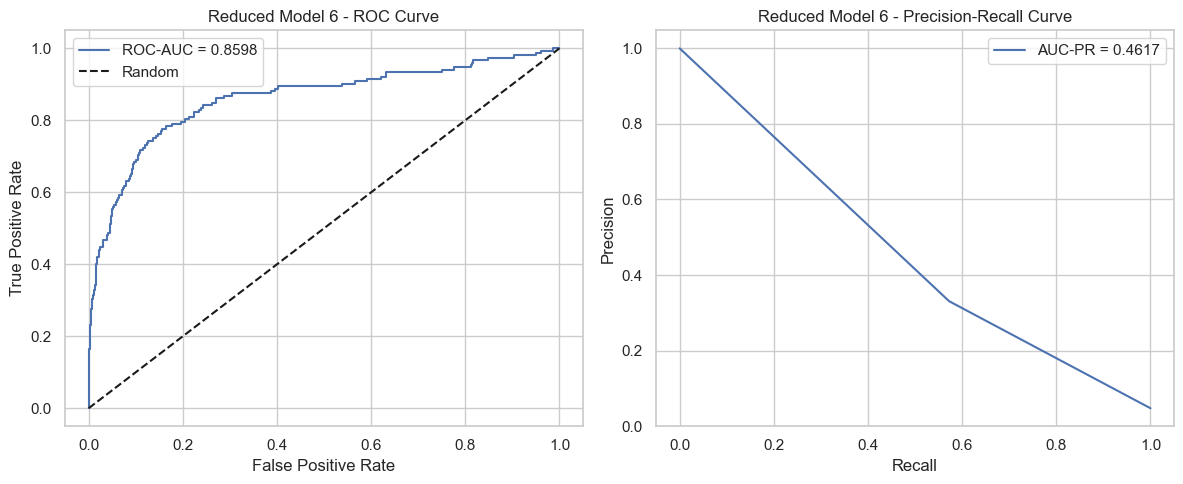

In [162]:
# ROC-AUC and AUC-PR and MMC
y_pred_proba_reduced6 = stacking_model_reduced6.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced6)
roc_auc_reduced6 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced6)
auc_pr_reduced6 = auc(recall, precision)
mcc_reduced6 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced6)

print(f"ROC-AUC: {roc_auc_reduced6:.4f}")
print(f"AUC-PR: {auc_pr_reduced6:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced6:.4f}")

# ROC and Precision Recall Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced6:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 6 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced6:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 6 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 7. Reduced 7

In [163]:
# REDUCED MODEL 7: Core + next 6 best (nc, knn, sgd, etc, lda, xgb)
reduced7_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid()),
    ('knn', KNeighborsClassifier()),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42)),
    ('etc', ExtraTreeClassifier(random_state=42)),
    ('lda', LinearDiscriminantAnalysis()),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
]

In [164]:
# Meta-learner
meta_learner = LogisticRegression()

In [165]:
# Stacking Classifier
stacking_model_reduced7 = StackingClassifier(estimators=reduced7_models, final_estimator=meta_learner, cv=5)

In [166]:
# Train model
stacking_model_reduced7.fit(X_train_rfe_smote, y_train_rfe_smote)

[LightGBM] [Info] Number of positive: 12159, number of negative: 12159
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.065703 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4926
[LightGBM] [Info] Number of data points in the train set: 24318, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029581 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4918
[LightGBM] [Info] Number of data points in the train set: 19454, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid()),
                               ('knn', KNeighborsClassifier()),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42)),
                               ('etc', ExtraTreeClass...
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...))],
                   final_estimator=LogisticRegression())

In [167]:
# Make predictions
y_pred_stack_reduced7 = stacking_model_reduced7.predict(X_test_rfe)

In [168]:
# Evaluating Reduced Model 7
accuracy_reduced7 = accuracy_score(y_test_rfe, y_pred_stack_reduced7)
conf_matrix_reduced7 = confusion_matrix(y_test_rfe, y_pred_stack_reduced7)
class_report_reduced7 = classification_report(y_test_rfe, y_pred_stack_reduced7)

TP = conf_matrix_reduced7[1, 1]
FN = conf_matrix_reduced7[1, 0]
FP = conf_matrix_reduced7[0, 1]
TN = conf_matrix_reduced7[0, 0]

TPR_reduced7 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced7 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced7 = (TPR_reduced7 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 7 - Core + NC + KNN + SGD + ETC + LDA + XGB (10 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced7:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced7:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced7:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced7:.4f}')
print('\nClassification Report:')
print(class_report_reduced7)

REDUCED MODEL 7 - Core + NC + KNN + SGD + ETC + LDA + XGB (10 models)
Evaluation Metrics:
Accuracy: 0.9219
True Positive Rate (TPR): 0.5789
False Positive Rate (FPR): 0.0610
Balanced Accuracy: 0.7590

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3048
           1       0.32      0.58      0.41       152

    accuracy                           0.92      3200
   macro avg       0.65      0.76      0.69      3200
weighted avg       0.95      0.92      0.93      3200



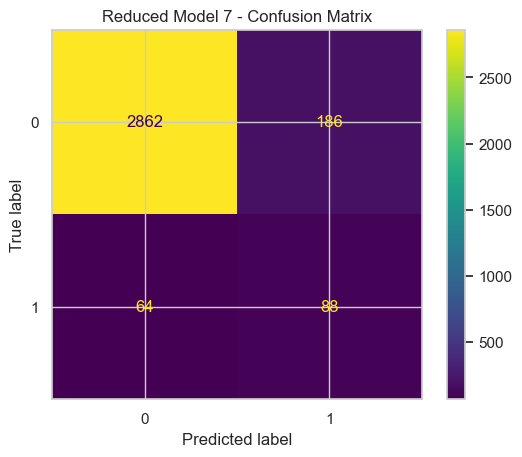

In [169]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced7, display_labels=stacking_model_reduced7.classes_)
disp.plot()
plt.title('Reduced Model 7 - Confusion Matrix')
plt.show()

ROC-AUC: 0.8587
AUC-PR: 0.4601
Matthews Correlation Coefficient (MCC): 0.3937


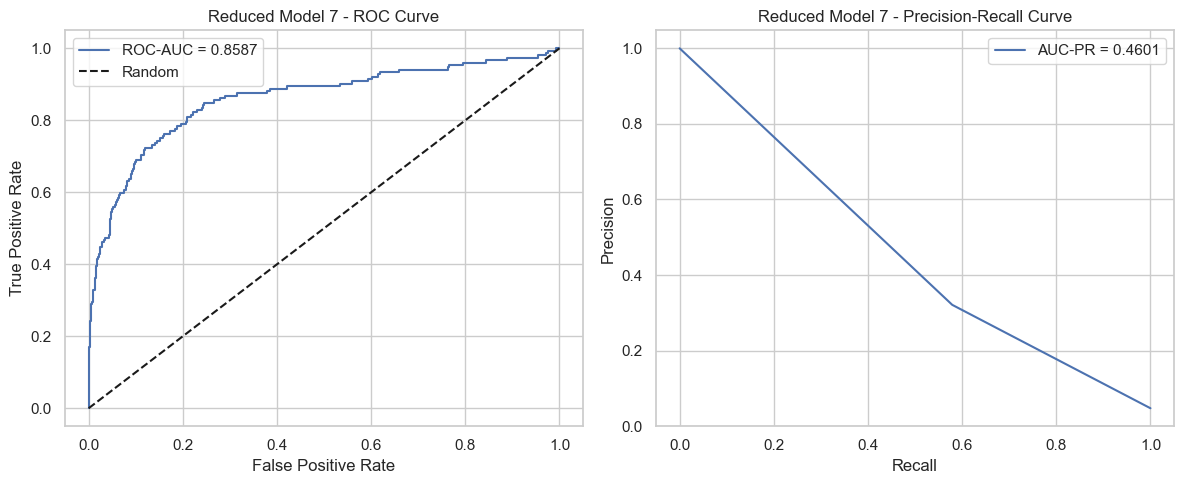

In [170]:
# ROC-AUC and AUC-PR
y_pred_proba_reduced7 = stacking_model_reduced7.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced7)
roc_auc_reduced7 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced7)
auc_pr_reduced7 = auc(recall, precision)

mcc_reduced7 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced7)

print(f"ROC-AUC: {roc_auc_reduced7:.4f}")
print(f"AUC-PR: {auc_pr_reduced7:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced7:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced7:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 7 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced7:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 7 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 8.Reduced 8

In [171]:
# REDUCED MODEL 8: Core + next 7 best (nc, knn, sgd, etc, lda, xgb, bnb)
reduced8_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid()),
    ('knn', KNeighborsClassifier()),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42)),
    ('etc', ExtraTreeClassifier(random_state=42)),
    ('lda', LinearDiscriminantAnalysis()),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('bnb', BernoulliNB())
]

In [172]:
# Meta-learner
meta_learner = LogisticRegression()

In [173]:
# Stacking Classifier
stacking_model_reduced8 = StackingClassifier(estimators=reduced8_models, final_estimator=meta_learner, cv=5)

In [174]:
# Train model
stacking_model_reduced8.fit(X_train_rfe_smote, y_train_rfe_smote)

[LightGBM] [Info] Number of positive: 12159, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031589 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4926
[LightGBM] [Info] Number of data points in the train set: 24318, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038081 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4918
[LightGBM] [Info] Number of data points in the train set: 19454, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negati

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid()),
                               ('knn', KNeighborsClassifier()),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42)),
                               ('etc', ExtraTreeClass...
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...)),
                               ('bnb', BernoulliNB())],
                   final_estimator=LogisticRegression())

In [175]:
# Make predictions
y_pred_stack_reduced8 = stacking_model_reduced8.predict(X_test_rfe)

In [176]:
# Evaluating Reduced Model 8
accuracy_reduced8 = accuracy_score(y_test_rfe, y_pred_stack_reduced8)
conf_matrix_reduced8 = confusion_matrix(y_test_rfe, y_pred_stack_reduced8)
class_report_reduced8 = classification_report(y_test_rfe, y_pred_stack_reduced8)

TP = conf_matrix_reduced8[1, 1]
FN = conf_matrix_reduced8[1, 0]
FP = conf_matrix_reduced8[0, 1]
TN = conf_matrix_reduced8[0, 0]

TPR_reduced8 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced8 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced8 = (TPR_reduced8 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 8 - Core + NC + KNN + SGD + ETC + LDA + XGB + BNB (11 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced8:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced8:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced8:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced8:.4f}')
print('\nClassification Report:')
print(class_report_reduced8)

REDUCED MODEL 8 - Core + NC + KNN + SGD + ETC + LDA + XGB + BNB (11 models)
Evaluation Metrics:
Accuracy: 0.9222
True Positive Rate (TPR): 0.5921
False Positive Rate (FPR): 0.0614
Balanced Accuracy: 0.7654

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3048
           1       0.32      0.59      0.42       152

    accuracy                           0.92      3200
   macro avg       0.65      0.77      0.69      3200
weighted avg       0.95      0.92      0.93      3200



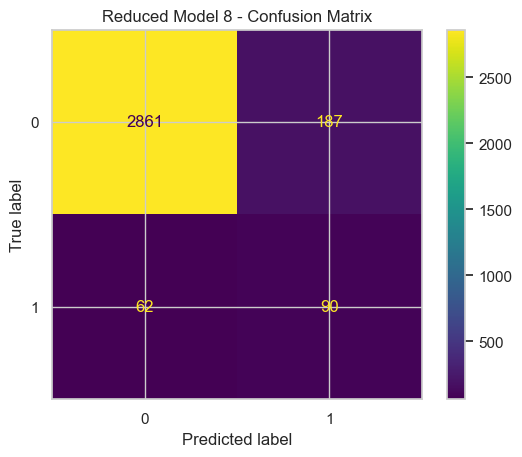

In [177]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced8, display_labels=stacking_model_reduced8.classes_)
disp.plot()
plt.title('Reduced Model 8 - Confusion Matrix')
plt.show()

ROC-AUC: 0.8596
AUC-PR: 0.4682
Matthews Correlation Coefficient (MCC): 0.4015


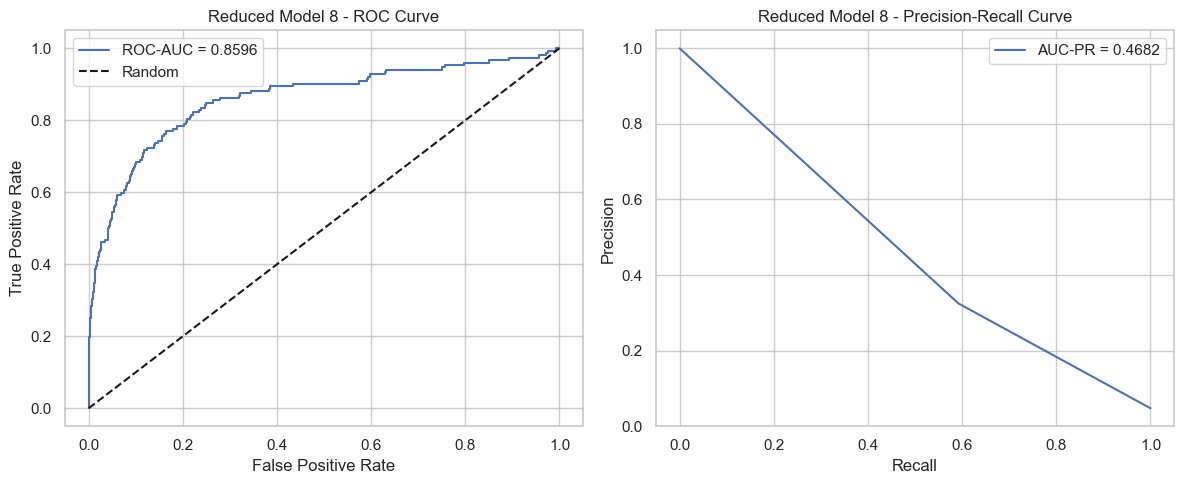

In [178]:
# ROC-AUC and AUC-PR
y_pred_proba_reduced8 = stacking_model_reduced8.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced8)
roc_auc_reduced8 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced8)
auc_pr_reduced8 = auc(recall, precision)

mcc_reduced8 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced8)

print(f"ROC-AUC: {roc_auc_reduced8:.4f}")
print(f"AUC-PR: {auc_pr_reduced8:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced8:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced8:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 8 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced8:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 8 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 9. Reduced 9

In [179]:
# REDUCED MODEL 9: Core + next 8 best (nc, knn, sgd, etc, lda, xgb, bnb, dt)
reduced9_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid()),
    ('knn', KNeighborsClassifier()),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42)),
    ('etc', ExtraTreeClassifier(random_state=42)),
    ('lda', LinearDiscriminantAnalysis()),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('bnb', BernoulliNB()),
    ('dt', DecisionTreeClassifier(random_state=42))
]

In [180]:
# Meta-learner
meta_learner = LogisticRegression()

In [181]:
# Stacking Classifier
stacking_model_reduced9 = StackingClassifier(estimators=reduced9_models, final_estimator=meta_learner, cv=5)

In [182]:
# Train model
stacking_model_reduced9.fit(X_train_rfe_smote, y_train_rfe_smote)

[LightGBM] [Info] Number of positive: 12159, number of negative: 12159
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045722 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4926
[LightGBM] [Info] Number of data points in the train set: 24318, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029930 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4918
[LightGBM] [Info] Number of data points in the train set: 19454, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 9727, number of negati

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid()),
                               ('knn', KNeighborsClassifier()),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42)),
                               ('etc', ExtraTreeClass...
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...)),
                               ('bnb', BernoulliNB()),
                               ('dt', DecisionTreeClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [183]:
# Make predictions
y_pred_stack_reduced9 = stacking_model_reduced9.predict(X_test_rfe)

In [184]:
# Evaluating Reduced Model 9
accuracy_reduced9 = accuracy_score(y_test_rfe, y_pred_stack_reduced9)
conf_matrix_reduced9 = confusion_matrix(y_test_rfe, y_pred_stack_reduced9)
class_report_reduced9 = classification_report(y_test_rfe, y_pred_stack_reduced9)

TP = conf_matrix_reduced9[1, 1]
FN = conf_matrix_reduced9[1, 0]
FP = conf_matrix_reduced9[0, 1]
TN = conf_matrix_reduced9[0, 0]

TPR_reduced9 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced9 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced9 = (TPR_reduced9 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 9 - Core + NC + KNN + SGD + ETC + LDA + XGB + BNB + DT (12 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced9:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced9:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced9:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced9:.4f}')
print('\nClassification Report:')
print(class_report_reduced9)

REDUCED MODEL 9 - Core + NC + KNN + SGD + ETC + LDA + XGB + BNB + DT (12 models)
Evaluation Metrics:
Accuracy: 0.9225
True Positive Rate (TPR): 0.5855
False Positive Rate (FPR): 0.0607
Balanced Accuracy: 0.7624

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      3048
           1       0.32      0.59      0.42       152

    accuracy                           0.92      3200
   macro avg       0.65      0.76      0.69      3200
weighted avg       0.95      0.92      0.93      3200



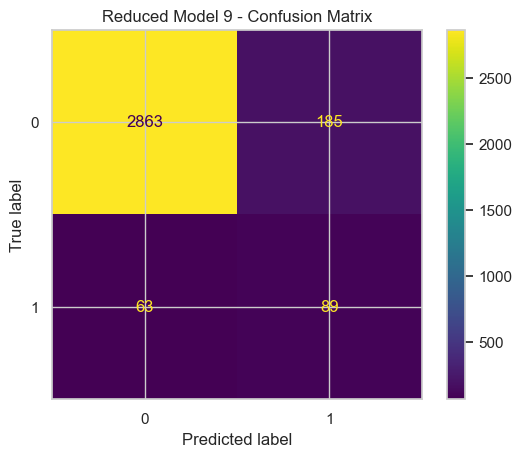

In [185]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced9, display_labels=stacking_model_reduced9.classes_)
disp.plot()
plt.title('Reduced Model 9 - Confusion Matrix')
plt.show()

ROC-AUC: 0.8596
AUC-PR: 0.4650
Matthews Correlation Coefficient (MCC): 0.3990


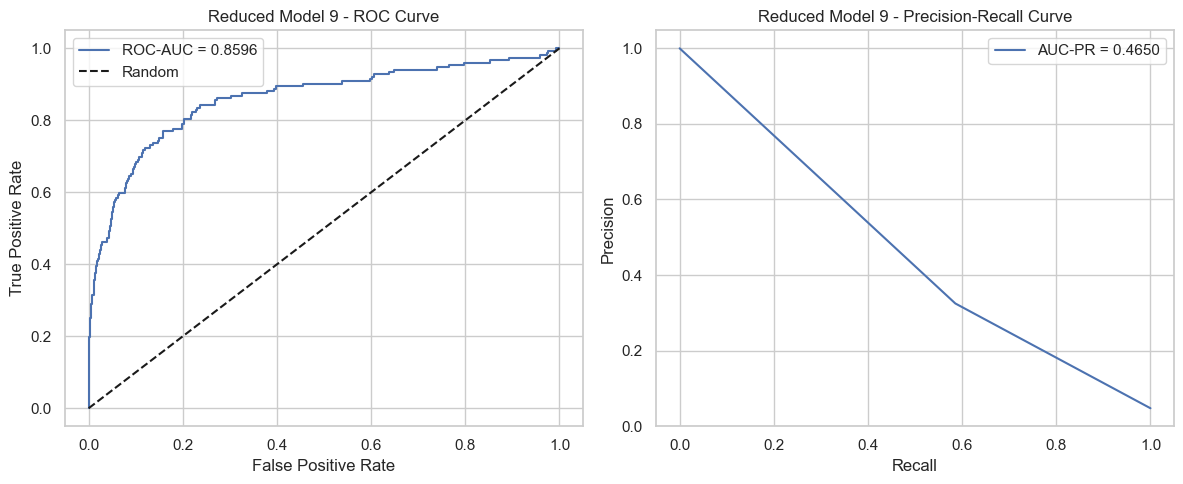

In [186]:
# ROC-AUC and AUC-PR
y_pred_proba_reduced9 = stacking_model_reduced9.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced9)
roc_auc_reduced9 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced9)
auc_pr_reduced9 = auc(recall, precision)

mcc_reduced9 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced9)

print(f"ROC-AUC: {roc_auc_reduced9:.4f}")
print(f"AUC-PR: {auc_pr_reduced9:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced9:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced9:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 9 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced9:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 9 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# SUMMARY COMPARISON

In [188]:
models_data = [
    ("Reduced 1 (Core)", 4, accuracy_reduced1, balanced_accuracy_reduced1, roc_auc_reduced1, auc_pr_reduced1, mcc_reduced1, TPR_reduced1, FPR_reduced1),
    ("Reduced 2 (Core+NC)", 5, accuracy_reduced2, balanced_accuracy_reduced2, roc_auc_reduced2, auc_pr_reduced2, mcc_reduced2, TPR_reduced2, FPR_reduced2),
    ("Reduced 3 (Core+NC+KNN)", 6, accuracy_stack_reduced3, balanced_accuracy_reduced3, roc_auc_reduced3, auc_pr_reduced3, mcc_reduced3, TPR_reduced3, FPR_reduced3),
    ("Reduced 4 (+SGD)", 7, accuracy_reduced4, balanced_accuracy_reduced4, roc_auc_reduced4, auc_pr_reduced4, mcc_reduced4, TPR_reduced4, FPR_reduced4),
    ("Reduced 5 (+ETC)", 8, accuracy_reduced5, balanced_accuracy_reduced5, roc_auc_reduced5, auc_pr_reduced5, mcc_reduced5, TPR_reduced5, FPR_reduced5),
    ("Reduced 6 (+LDA)", 9, accuracy_reduced6, balanced_accuracy_reduced6, roc_auc_reduced6, auc_pr_reduced6, mcc_reduced6, TPR_reduced6, FPR_reduced6),
    ("Reduced 7 (+XGB)", 10, accuracy_reduced7, balanced_accuracy_reduced7, roc_auc_reduced7, auc_pr_reduced7, mcc_reduced7, TPR_reduced7, FPR_reduced7),
    ("Reduced 8 (+BNB)", 11, accuracy_reduced8, balanced_accuracy_reduced8, roc_auc_reduced8, auc_pr_reduced8, mcc_reduced8, TPR_reduced8, FPR_reduced8),
    ("Reduced 9 (+DT)", 12, accuracy_reduced9, balanced_accuracy_reduced9, roc_auc_reduced9, auc_pr_reduced9, mcc_reduced9, TPR_reduced9, FPR_reduced9),
    ("Full Model", 13, accuracy_stack, balanced_accuracy, roc_auc_full, auc_pr, mcc_full, TPR, FPR)
]

In [189]:
# SUMMARY COMPARISON
print("SYSTEMATIC REDUCED STACKING ENSEMBLE - SUMMARY COMPARISON")
print("Threshold-based approach: Core performers (SHAP > 0.5) + incremental additions")

print(f"{'Model':<25} {'N_Models':<10} {'Accuracy':<10} {'Bal_Acc':<10} {'ROC-AUC':<10} {'AUC-PR':<10} {'MCC':<8} {'TPR':<8} {'FPR':<8}")

for model_name, n_models, acc, bal_acc, roc_auc, auc_pr_score, mcc, tpr, fpr in models_data:
    print(f"{model_name:<25} {n_models:<10} {acc:<10.4f} {bal_acc:<10.4f} {roc_auc:<10.4f} {auc_pr_score:<10.4f} {mcc:<8.4f} {tpr:<8.4f} {fpr:<8.4f}")

# Find best performing models
best_accuracy = max(models_data, key=lambda x: x[2])
best_balanced = max(models_data, key=lambda x: x[3])
best_roc_auc = max(models_data, key=lambda x: x[4])
best_auc_pr = max(models_data, key=lambda x: x[5])
best_mcc = max(models_data, key=lambda x: x[6])
best_tpr = max(models_data, key=lambda x: x[7])
best_fpr = min(models_data, key=lambda x: x[8])

print("\nBEST PERFORMING MODELS:")
print(f"Best Accuracy: {best_accuracy[0]} - {best_accuracy[2]:.4f}")
print(f"Best Balanced Accuracy: {best_balanced[0]} - {best_balanced[3]:.4f}")
print(f"Best ROC-AUC: {best_roc_auc[0]} - {best_roc_auc[4]:.4f}")
print(f"Best AUC-PR: {best_auc_pr[0]} - {best_auc_pr[5]:.4f}")
print(f"Best MCC: {best_mcc[0]} - {best_mcc[6]:.4f}")
print(f"Best True Positive Rate (TPR): {best_tpr[0]} - {best_tpr[7]:.4f}")
print(f"Lowest False Positive Rate (FPR): {best_fpr[0]} - {best_fpr[8]:.4f}")

SYSTEMATIC REDUCED STACKING ENSEMBLE - SUMMARY COMPARISON
Threshold-based approach: Core performers (SHAP > 0.5) + incremental additions
Model                     N_Models   Accuracy   Bal_Acc    ROC-AUC    AUC-PR     MCC      TPR      FPR     
Reduced 1 (Core)          4          0.9113     0.7971     0.8904     0.4951     0.4123   0.6711   0.0768  
Reduced 2 (Core+NC)       5          0.8869     0.7718     0.8465     0.4515     0.3475   0.6447   0.1010  
Reduced 3 (Core+NC+KNN)   6          0.9206     0.7614     0.8661     0.4615     0.3936   0.5855   0.0627  
Reduced 4 (+SGD)          7          0.9250     0.7575     0.8634     0.4624     0.3995   0.5724   0.0574  
Reduced 5 (+ETC)          8          0.9263     0.7550     0.8619     0.4612     0.3999   0.5658   0.0558  
Reduced 6 (+LDA)          9          0.9247     0.7573     0.8598     0.4617     0.3986   0.5724   0.0577  
Reduced 7 (+XGB)          10         0.9219     0.7590     0.8587     0.4601     0.3937   0.5789   0.0610  

# Precision-Recall Curves for All Models

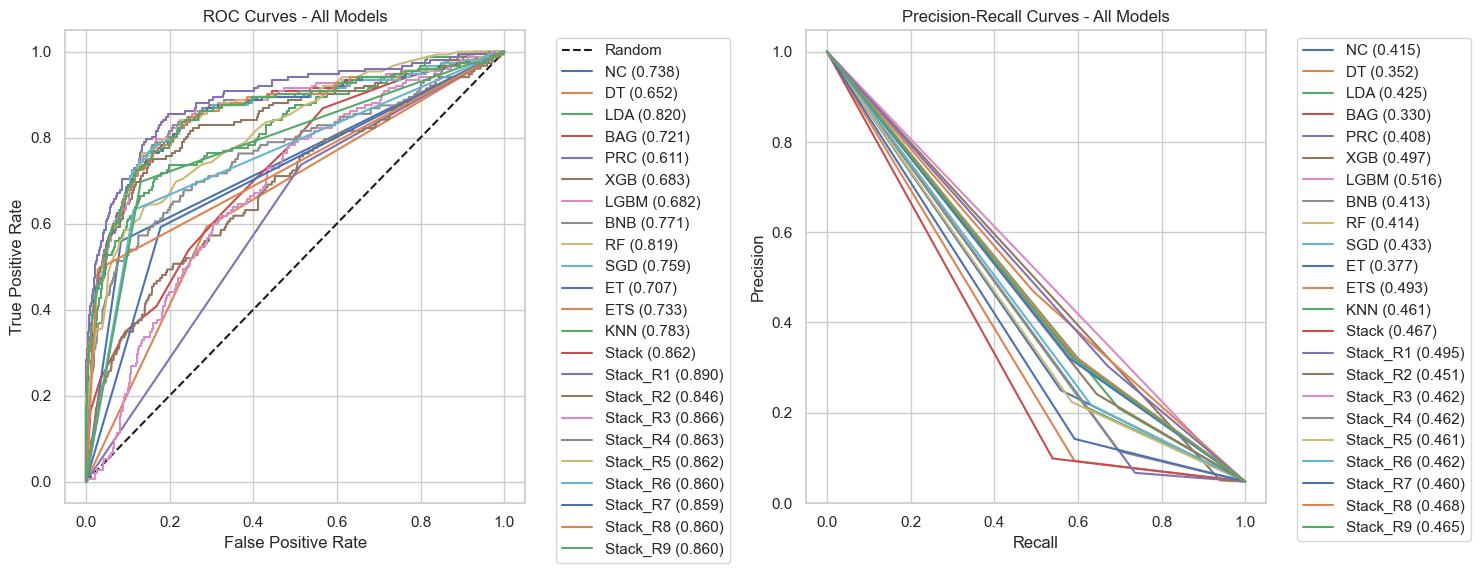

In [197]:
# Models
models = {
    'NC': y_pred_NC, 'DT': y_pred_DT, 'LDA': y_pred_LDA, 'BAG': y_pred_BAG,
    'PRC': y_pred_PRC, 'XGB': y_pred_XGB, 'LGBM': y_pred_LGBM, 'BNB': y_pred_BNB,
    'RF': y_pred_RF, 'SGD': y_pred_SGD, 'ET': y_pred_ET, 'ETS': y_pred_ETS, 'KNN': y_pred_KNN,
    'Stack': y_pred_stack, 'Stack_R1': y_pred_stack_reduced1, 'Stack_R2': y_pred_stack_reduced2,
    'Stack_R3': y_pred_stack_reduced3, 'Stack_R4': y_pred_stack_reduced4, 'Stack_R5': y_pred_stack_reduced5,
    'Stack_R6': y_pred_stack_reduced6, 'Stack_R7': y_pred_stack_reduced7, 'Stack_R8': y_pred_stack_reduced8,
    'Stack_R9': y_pred_stack_reduced9
}

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot([0, 1], [0, 1], 'k--', label='Random')
for name, y_pred in models.items():
    if name == 'DT':
        y_scores = y_pred_proba_DT
    elif name == 'LDA':
        y_scores = y_pred_proba_LDA
    elif name == 'BAG':
        y_scores = y_pred_proba_BAG
    elif name == 'XGB':
        y_scores = y_pred_proba_XGB
    elif name == 'LGBM':
        y_scores = y_pred_proba_LGBM
    elif name == 'BNB':
        y_scores = y_pred_proba_BNB
    elif name == 'RF':
        y_scores = y_pred_proba_RF
    elif name == 'Stack':
        y_scores = y_pred_proba_full
    elif name == 'Stack_R1':
        y_scores = y_pred_proba_reduced1
    elif name == 'Stack_R2':
        y_scores = y_pred_proba_reduced2
    elif name == 'Stack_R3':
        y_scores = y_pred_proba_reduced3
    elif name == 'Stack_R4':
        y_scores = y_pred_proba_reduced4
    elif name == 'Stack_R5':
        y_scores = y_pred_proba_reduced5
    elif name == 'Stack_R6':
        y_scores = y_pred_proba_reduced6
    elif name == 'Stack_R7':
        y_scores = y_pred_proba_reduced7
    elif name == 'Stack_R8':
        y_scores = y_pred_proba_reduced8
    elif name == 'Stack_R9':
        y_scores = y_pred_proba_reduced9
    else:
        y_scores = y_pred
    
    fpr, tpr, _ = roc_curve(y_test_rfe, y_scores)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{name} ({roc_auc:.3f})')

ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves - All Models')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True)

for name, y_pred in models.items():
    precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred)
    auc_pr = auc(recall, precision)
    ax2.plot(recall, precision, label=f'{name} ({auc_pr:.3f})')

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves - All Models')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True)

plt.tight_layout()
plt.show()